# EDA da base de datos

In [2]:
#pip install prince

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import dateparser
import seaborn as sns
import scipy.stats as stats
import prince
from sklearn.covariance import MinCovDet
from datetime import datetime
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.dates as mdates


# matplotlib inline

## Lectura de datos

In [2]:
datos = pd.read_csv('TFM Diego_cluster_Tabla-2.csv', sep = ',', decimal='.')
datos.head(10)

,id_trucksters,contract,lane_zipcode,client_name_complete,client_price,empty_km,loaded_km,po_price_empty,po_price_loaded,direction,origin_country,destination_country,origin_zipcode,destination_zipcode,route_start_date
0,R20200914-DYK,fix,CECOTEC: ES46 - ES28,CECOTEC INNOVACIONES S.L.,380.0,0,0,0.0,370.0,cabotaje nacional,ES,ES,ES46,ES28,"15 sept 2020, 12:00:00"
1,R20200929-TRP,fix,CECOTEC: ES46 - ES28,CECOTEC INNOVACIONES S.L.,380.0,0,0,0.0,370.0,cabotaje nacional,ES,ES,ES46,ES28,"29 sept 2020, 9:00:00"
2,R20200930-VAB,fix,SEUR: ES08 - ES08,SEUR GEOPOST SLU,0.0,0,0,0.0,100.0,cabotaje nacional,ES,ES,ES08,ES08,"23 sept 2020, 12:00:00"
3,R20200930-WBO,fix,SEUR: ES08 - ES08,SEUR GEOPOST SLU,0.0,0,0,0.0,150.0,cabotaje nacional,ES,ES,ES08,ES08,"30 sept 2020, 11:00:00"
4,R20200930-QTW,fix,SEUR: ES08 - ES08,SEUR GEOPOST SLU,0.0,0,0,0.0,350.0,cabotaje nacional,ES,ES,ES08,ES08,"29 sept 2020, 13:00:00"
5,R20200930-VLB,fix,SEUR: ES08 - ES08,SEUR GEOPOST SLU,0.0,0,0,0.0,150.0,cabotaje nacional,ES,ES,ES08,ES08,"24 sept 2020, 12:00:00"
6,R20200930-TRP,fix,SEUR: ES08 - ES08,SEUR GEOPOST SLU,0.0,0,0,0.0,350.0,cabotaje nacional,ES,ES,ES08,ES08,"26 sept 2020, 11:00:00"
7,R20201006-IRQ,fix,VILLART: ES08 - BE35,"VILLART LOGISTIC, S.L.U",1204.0,0,1340,0.0,1273.0,export,ES,BE,ES08,BE35,"30 sept 2020, 7:00:00"
8,R20201013-DMM,fix,CECOTEC: ES46 - ES28,CECOTEC INNOVACIONES S.L.,380.0,0,0,0.0,370.0,cabotaje nacional,ES,ES,ES46,ES28,"14 oct 2020, 10:30:00"
9,R20201014-VDF,fix,CECOTEC: ES46 - ES28,CECOTEC INNOVACIONES S.L.,380.0,0,0,0.0,370.0,cabotaje nacional,ES,ES,ES46,ES28,"15 oct 2020, 16:00:00"


In [3]:
datos.shape

(21271, 15)

Temos 21271 observacións.

In [4]:
datos.dtypes

id_trucksters            object
contract                 object
lane_zipcode             object
client_name_complete     object
client_price            float64
empty_km                  int64
loaded_km                 int64
po_price_empty          float64
po_price_loaded         float64
direction                object
origin_country           object
destination_country      object
origin_zipcode           object
destination_zipcode      object
route_start_date         object
dtype: object

In [5]:
datos.describe()

,client_price,empty_km,loaded_km,po_price_empty,po_price_loaded
count,21271.000000,21271.000000,21271.000000,21271.000000,21271.000000
mean,1888.917056,142.712002,1440.348409,132.849875,1606.291264
std,695.823998,213.411459,536.661514,198.711291,606.330214
min,-1950.000000,0.000000,0.000000,0.000000,-1770.000000
25%,1550.000000,0.000000,1257.000000,0.000000,1400.000000
50%,1888.980000,71.000000,1445.000000,61.560000,1641.000000
75%,2240.000000,202.000000,1717.000000,194.085000,1901.640000
max,19530.140000,2784.000000,4941.000000,2526.280000,5517.850000


## Análise Descriptivo

Comezamos creando as novas variables necesarias para o estudo: precio do km para o cliente e o proveedor.
Para iso debemos crear unha variable que recolla os km totais do envío. Posteriormente, para evitar problemas no noso estudo, debemos filtrar os datos, eliminando aquelas observacións con km totais = 0, e con prezos do proveedor e do cliente < 0.  Estos envíos non nos serán de utilidade para os nosos modelos posto que se tratan de envíos 'artificais' anotados pola empresa que representan penalizacións ao proveedor por erros no reparto, ou ben compensacións ao cliente. Cómpre tamén sinalar que teremos unha serie de envíos onde, na súa maioría, loaded_km = 0, que representan compensacións que nos aporta un cliente co que se tiña firmado un acordo debido a grandes fluctuacións no prezo dos combustibles. 

In [6]:
datos['total_km'] = datos['loaded_km'] + datos['empty_km']
datos['pro_price'] = datos['po_price_empty'] + datos['po_price_loaded']
datos = datos[(datos['loaded_km'] > 0) & (datos['client_price'] > 0) 
              & (datos['po_price_loaded'] > 0)]


In [7]:
datos['cl_price_km'] = datos['client_price']/datos['total_km']
datos['pro_price_km'] = datos['pro_price']/datos['total_km']


Agora ben, por coñecemento da empresa sabemos que envíos con precio por km para o cliente ou o proveedor superiores a 3€ son erros na medida dos datos, co cal debemos eliminar ditas observacións.

In [8]:
datos = datos[(datos['cl_price_km'] < 3) & (datos['pro_price_km'] < 3)]

In [9]:
datos.shape

(20609, 19)

Tras este primeiro filtrado dos datos, quedamos con 20609 que seguen a ser unha gran canttidade de observacións.

In [10]:
datos.describe()

,client_price,empty_km,loaded_km,po_price_empty,po_price_loaded,total_km,pro_price,cl_price_km,pro_price_km
count,20609.000000,20609.000000,20609.000000,20609.000000,20609.000000,20609.000000,20609.000000,20609.000000,20609.000000
mean,1920.116028,146.348586,1483.156437,136.227983,1650.940592,1629.505022,1787.168575,1.200523,1.099543
std,641.927221,213.566351,483.078541,198.841708,553.695341,559.337243,613.998878,0.246404,0.144410
min,110.000000,0.000000,9.000000,0.000000,0.010000,51.000000,0.010000,0.190011,0.000005
25%,1560.000000,0.000000,1278.000000,0.000000,1423.540000,1360.000000,1500.000000,1.068966,1.037342
50%,1900.030000,76.000000,1452.000000,65.570000,1656.470000,1597.000000,1775.000000,1.185345,1.084977
75%,2240.000000,205.000000,1724.000000,197.750000,1910.770000,1910.000000,2078.900000,1.300488,1.135446
max,4693.000000,2784.000000,4941.000000,2526.280000,5517.850000,5428.000000,5785.500000,2.769379,2.877851


Agora as variables tipo obxecto transformámolas en tipo 'category' o cal nos permitirá obter máis información da base de datos así como ter maior utilidade á hora de implementar os nosos modelos. 

Por outra banda, a variable 'route_start_date' transformarémola a unha variable tipo data e, como nos interesará ver a evolución de distintas variables ao longo do tempo, podemos agrupar as nosas observacións semanal e mensualmente, polo cal crearemos dúas novas variables que representarán, respectivamente, a semana e o mes ao que se corresponde o envío.

In [11]:
col_factores = ['contract', 'lane_zipcode', 'direction', 'destination_country', 
                'origin_country', 'origin_zipcode', 'client_name_complete',
                'destination_zipcode']
for j in col_factores:
    datos[j] = datos[j].astype('category')


datos.dtypes

id_trucksters             object
contract                category
lane_zipcode            category
client_name_complete    category
client_price             float64
empty_km                   int64
loaded_km                  int64
po_price_empty           float64
po_price_loaded          float64
direction               category
origin_country          category
destination_country     category
origin_zipcode          category
destination_zipcode     category
route_start_date          object
total_km                   int64
pro_price                float64
cl_price_km              float64
pro_price_km             float64
dtype: object

Á hora de transformar a variable a tipo data, sáltanos un Warning xa que é posible que algunha data non esté ben rexistrada co formato %Y%M%D%h, co cal imos ver que observacións nos dan problemas e intentar atacalas.

In [12]:

# Verifica si alguna fecha NO contiene un año de 4 dígitos
sin_año = datos[~datos['route_start_date'].str.contains(r'\b\d{4}\b', na=False)]

# Mostrar las filas que no tienen año
print(sin_año[['route_start_date']])


Empty DataFrame
Columns: [route_start_date]
Index: []


In [13]:
datos['route_start_date'] = datos['route_start_date'].apply(lambda x: dateparser.parse(x))

/var/folders/72/92sdss296tdg9zgnwr3xcg180000gn/T/ipykernel_7234/4109703333.py:1: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  datos['route_start_date'] = datos['route_start_date'].apply(lambda x: dateparser.parse(x))


In [14]:
fechas_invalidas = datos[datos['route_start_date'].isnull()]
print(fechas_invalidas[['route_start_date']])

Empty DataFrame
Columns: [route_start_date]
Index: []


Parece daquela que, a pesar do Warning, non temos problema coa data de ningún pedido.

In [15]:
fecha_inicio = pd.to_datetime('2022-01-01')
datos[datos['route_start_date'].dt.normalize() < fecha_inicio].shape[0]

679

In [16]:
datos[datos['route_start_date'].dt.normalize() < fecha_inicio].shape[0]/datos.shape[0]

0.032946770828278904

Agora ben, dos 20609 datos dispoñibles, tan só 679 son anteriores ao ano 2022, co cal poderiamos pensar que se tiña pouca información previa ao ano 2022 ou ben que esta diferenza tamén se debe ao crecemento da empresa, a cal empezou a traballar con máis clientes nos últimos tres anos. Polo tanto, podemos pensar en non traballar con esta información posto que non vai ter unha influenza positiva nos nosos modelos de predición.

In [17]:
#fecha_fin = pd.to_datetime('2025-10-01')
fecha_fin = pd.to_datetime('2025-09-29') # A última semana de setembro inclúe 5 días de outubro
datos[datos['route_start_date'].dt.normalize() >= fecha_fin].shape[0]

61

**Nota**: co fin de non perder información na última semana de setembro, incluímos os primeiros días de outubro (imos facer o estudo semanalmente).

Por outra banda, como os datos foron extraídos na primeira semana de outubro do 2025, tan só se teñen 16 observacións de dito mes, co cal podemos pensar que é información incompleta e debemos prescindir dela á hora de traballar.

In [18]:
datos = datos[(datos['route_start_date'].dt.normalize() >= fecha_inicio) & (datos['route_start_date'].dt.normalize() < fecha_fin)]
datos.shape

(19869, 19)

Agora ben, unha vez filtrada a base de datos, quedamos con 19914 observacións. Neste intre, imos facer un análise exploratorio dos nosos datos. Como o noso obxectivo reside en construír modelos de predición co fin de predecir o volume de pedidos nunha data dada para un cliente en concreto, interesaranos entón ver a evolución temporal do volume de pedidos. Polo tanto, podemos agrupar os nosos datos semanal e mensualmente.

Por outra banda, tamén nos resultarán de interese outras variables que posiblemente garden relación coa nosa variable de interese, como poden ser o prezo do km tanto do cliente coma do proveedor, ou ben a relación entre o prezo do km coa cantidade de km que o camión vai con carga.

Comezamos creando dúas novas variables 'semana' e 'mes', que nos axudarán a ver a evolución temporal dos nosos datos. Ademáis, sabemos que, tanto festivos como datas especiais (black friday) teñen un impacto no número de envíos. Así, engadiremos unha variable binaria que nos indicará se un pedido se enviou en día festivo (1) ou non (0)

In [19]:
# Creamos unha lista cos festivos e marcando tamén o black friday:
festivos = [
    '2022-01-01', '2022-04-14', '2022-04-15', '2022-04-18',
    '2022-05-01', '2022-05-02', '2022-05-08', '2022-05-09',
    '2022-05-26', '2022-08-15', '2022-10-31', '2022-11-01',
    '2022-11-02', '2022-12-06', '2022-12-08', '2022-12-25',
    '2023-01-01', '2023-04-06', '2023-04-07', '2023-04-10',
    '2023-05-01', '2023-05-02', '2023-05-08', '2023-05-09',
    '2023-05-18', '2023-08-15', '2023-10-31', '2023-11-01',
    '2023-11-02', '2023-12-06', '2023-12-08', '2023-12-25',
    '2024-01-01', '2024-03-28', '2024-03-29', '2024-04-01',
    '2024-05-01', '2024-05-02', '2024-05-07', '2024-05-08',
    '2024-05-09', '2024-05-20', '2024-08-15', '2024-10-31',
    '2024-11-01', '2024-11-02', '2024-12-06', '2024-12-09',
    '2024-12-25', '2025-01-01', '2025-04-17', '2025-04-18',
    '2025-04-21', '2025-05-01', '2025-05-02', '2025-05-07', 
    '2025-05-08', '2025-05-09', '2025-05-29', '2025-08-15', 
    '2025-10-31', '2025-11-01', '2025-11-02', '2025-12-06', 
    '2025-12-08', '2025-12-25', '2022-11-25', '2023-11-24',
    '2024-11-29', '2025-11-28', '2022-05-07'
]

# Convertir a lista a tipo datetime
festivos = pd.to_datetime(festivos)

datos['festivo'] = datos['route_start_date'].dt.normalize().isin(festivos).astype(int)

datos['dia'] = datos['route_start_date'].dt.date

datos['semana'] = datos['route_start_date'].dt.to_period('W').apply(lambda r: r.start_time)

datos['mes'] = datos['route_start_date'].dt.to_period('M').dt.to_timestamp()

### Prezo do km 

Comezamos vendo como se distribúe a variable do prezo do km tanto para clientes como para proveedores mediante visualizacións gráficas.

Para os clientes:

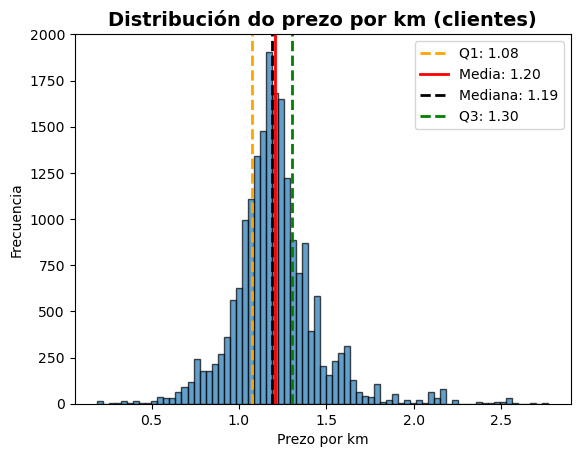

In [20]:
# Calcular los valores de referencia
q25 = np.quantile(datos['cl_price_km'], 0.25)
q75 = np.quantile(datos['cl_price_km'], 0.75)
mean = np.mean(datos['cl_price_km'])
median = np.median(datos['cl_price_km'])
# Regra de Freedman-Diaconis para o número de caixas
h = 2*(q75-q25)/datos.shape[0]**(1/3)
bins = int(np.ceil((datos['cl_price_km'].max() - datos['cl_price_km'].min()) / h))

# Crear el histograma
plt.hist(datos['cl_price_km'], bins=75, edgecolor='black', alpha=0.7)
plt.title("Distribución do prezo por km (clientes)", fontdict={'fontsize': 14, 'fontweight': 'bold'})
plt.xlabel("Prezo por km")
plt.ylabel("Frecuencia")

# Añadir líneas verticales
plt.axvline(q25, color='orange', linestyle='--', linewidth=2, label=f'Q1: {q25:.2f}')
plt.axvline(mean, color='red', linestyle='-', linewidth=2, label=f'Media: {mean:.2f}')
plt.axvline(median, color='black', linestyle='--', linewidth=2, label=f'Mediana: {median:.2f}')
plt.axvline(q75, color='green', linestyle='--', linewidth=2, label=f'Q3: {q75:.2f}')

# Añadir leyenda
plt.legend()
plt.show()


Notemos como se trata dunha distribución bastante simétrica.

Podemos facer tamén un Boxplot.

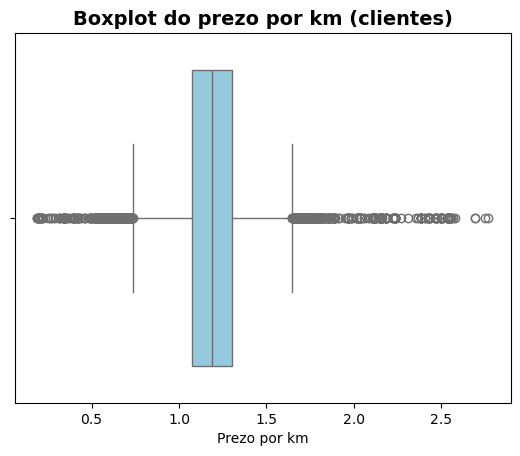

In [21]:
sns.boxplot(x=datos['cl_price_km'], color="skyblue")

plt.title("Boxplot do prezo por km (clientes)", fontdict={'fontsize': 14, 'fontweight': 'bold'})
plt.xlabel("Prezo por km")
plt.show()


Vemos unha gran cantidade de datos que se poderían considerar como outliers (caen fora dos "bigotes" do boxplot (1.5*IQR)).

Agora para os proveedores:

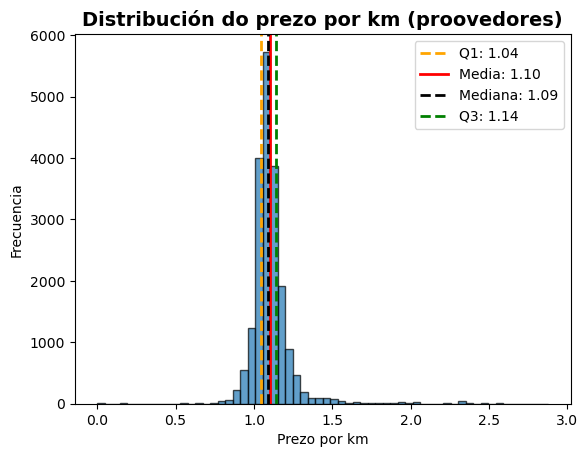

In [22]:
# Calcular los valores de referencia
q25 = np.quantile(datos['pro_price_km'], 0.25)
q75 = np.quantile(datos['pro_price_km'], 0.75)
mean = np.mean(datos['pro_price_km'])
median = np.median(datos['pro_price_km'])
# Regra de Freedman-Diaconis para o número de caixas
h = 2*(q75-q25)/datos.shape[0]**(1/3)
bins = int(np.ceil((datos['pro_price_km'].max() - datos['pro_price_km'].min()) / h))

# Crear el histograma
plt.hist(datos['pro_price_km'], bins=60, edgecolor='black', alpha=0.7)
plt.title("Distribución do prezo por km (proovedores)", fontdict={'fontsize': 14, 'fontweight': 'bold'})
plt.xlabel("Prezo por km")
plt.ylabel("Frecuencia")

plt.axvline(q25, color='orange', linestyle='--', linewidth=2, label=f'Q1: {q25:.2f}')
plt.axvline(mean, color='red', linestyle='-', linewidth=2, label=f'Media: {mean:.2f}')
plt.axvline(median, color='black', linestyle='--', linewidth=2, label=f'Mediana: {median:.2f}')
plt.axvline(q75, color='green', linestyle='--', linewidth=2, label=f'Q3: {q75:.2f}')

# Añadir leyenda
plt.legend()
plt.show()

De novo trátase dunha variable bastante simétrica. Nesta variable vemos como o 50% dos datos (entre Q1 e Q3) atópanse moi concentrados sobre 1.10€, é dicir, ten pouca dispersión. Podemos ver, novamente un boxplot da devandita variable:

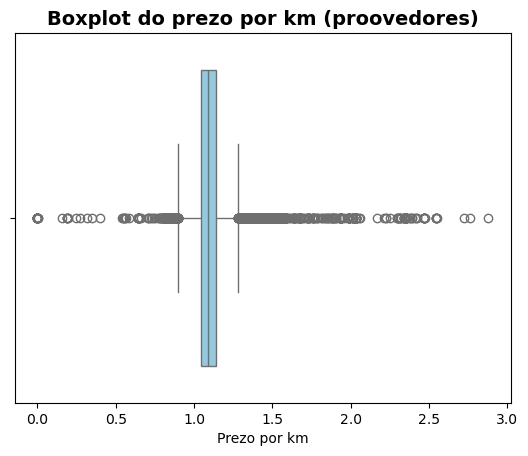

In [23]:
sns.boxplot(x=datos['pro_price_km'], color="skyblue")

plt.title("Boxplot do prezo por km (proovedores)", fontdict={'fontsize': 14, 'fontweight': 'bold'})
plt.xlabel("Prezo por km")
plt.show()


### Loaded_km

Imos ver como é a distribución da variable **loaded_km**, que recordemos que son os km que o camión vai con carga. É natural pensar que esta variable vai ter certa importancia para os nosos modelos.

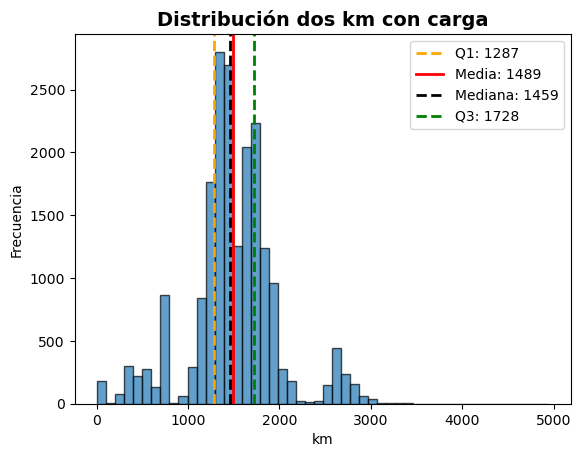

In [24]:
# Calcular los valores de referencia
q25 = np.quantile(datos['loaded_km'], 0.25)
q75 = np.quantile(datos['loaded_km'], 0.75)
mean = np.mean(datos['loaded_km'])
median = np.median(datos['loaded_km'])
# Regra de Freedman-Diaconis para o número de caixas
h = 2*(q75-q25)/datos.shape[0]**(1/3)
bins = int(np.ceil((datos['loaded_km'].max() - datos['loaded_km'].min()) / h))

# Crear el histograma
plt.hist(datos['loaded_km'], bins=50, edgecolor='black', alpha=0.7)
plt.title("Distribución dos km con carga", fontdict={'fontsize': 14, 'fontweight': 'bold'})
plt.xlabel("km")
plt.ylabel("Frecuencia")

# Añadir líneas verticales
plt.axvline(q25, color='orange', linestyle='--', linewidth=2, label=f'Q1: {q25:.0f}')
plt.axvline(mean, color='red', linestyle='-', linewidth=2, label=f'Media: {mean:.0f}')
plt.axvline(median, color='black', linestyle='--', linewidth=2, label=f'Mediana: {median:.0f}')
plt.axvline(q75, color='green', linestyle='--', linewidth=2, label=f'Q3: {q75:.0f}')

# Añadir leyenda
plt.legend()
plt.show()

Neste caso a distribución non é nada simétrica.

Vemos o correspondente Boxplot.

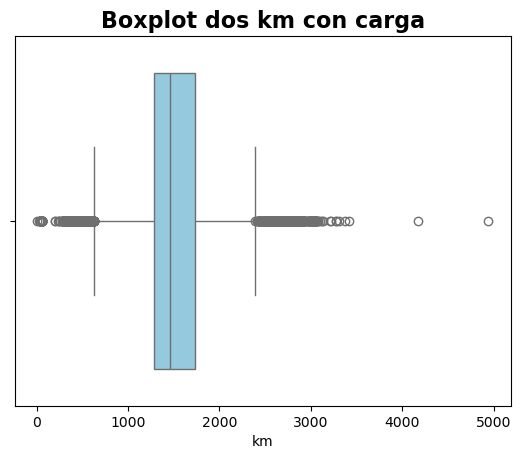

In [25]:
sns.boxplot(x=datos['loaded_km'], color="skyblue")

plt.title("Boxplot dos km con carga", fontdict={'fontsize': 16, 'fontweight': 'bold'})
plt.xlabel("km")
plt.show()

Vemos, en particular, unha distribución asimétrica positiva (media mási próxima a q25), con envíos de distancias moi longas (superiores a 3000 km). Ademáis, vemos como 0 75% dos viaxes son inferiores a 2000 km, estando, en particular, o 50% dos envíos entre 1000 e 2000 km. Sinalamos daquela que gran parte dos pedidos son dunha distancia que podemos considerar "media".

## Relacións entre as variables

Vexamos agora a posible existencia de colinealidade entre as variables da nosa base de datos. Sinalemos que, por construción, podemos saber que algunhas destas variables están altamente correlacionadas (p. e. loded_km e pro_price_loaded).

In [26]:
corr = datos.corr(numeric_only=True, method='pearson')
corr = corr.drop(index="festivo", columns="festivo")
corr

,client_price,empty_km,loaded_km,po_price_empty,po_price_loaded,total_km,pro_price,cl_price_km,pro_price_km
client_price,1.000000,0.150050,0.910741,0.160560,0.916635,0.843500,0.877904,0.212282,0.179749
empty_km,0.150050,1.000000,0.163807,0.974752,0.131461,0.524549,0.436849,-0.478857,-0.185538
loaded_km,0.910741,0.163807,1.000000,0.165987,0.943681,0.925805,0.904033,-0.088481,0.006517
po_price_empty,0.160560,0.974752,0.165987,1.000000,0.139905,0.516756,0.452701,-0.458825,-0.134690
po_price_loaded,0.916635,0.131461,0.943681,0.139905,1.000000,0.864805,0.946228,0.042718,0.315231
total_km,0.843500,0.524549,0.925805,0.516756,0.864805,1.000000,0.947605,-0.259850,-0.065470
pro_price,0.877904,0.436849,0.904033,0.452701,0.946228,0.947605,1.000000,-0.111437,0.239866
cl_price_km,0.212282,-0.478857,-0.088481,-0.458825,0.042718,-0.259850,-0.111437,1.000000,0.488532
pro_price_km,0.179749,-0.185538,0.006517,-0.134690,0.315231,-0.065470,0.239866,0.488532,1.000000


Graficamente:

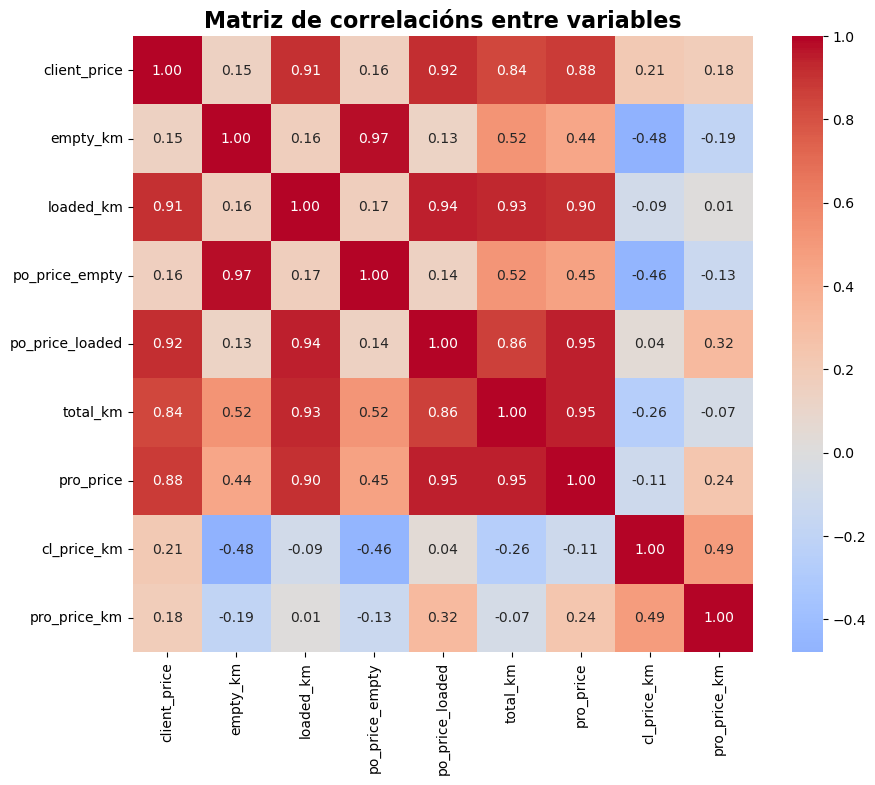

In [27]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)

plt.title("Matriz de correlacións entre variables", fontdict={'fontsize': 16, 'fontweight': 'bold'})
plt.show()


Vemos como, en efecto, moitas das nosas variables orixinais están altamente correlacionadas. Porén, as variables que construímos posteriormente como **cl_price_km** e **pro_price_km** teñen correlacións moito máis baixas, polo que ten sentido traballar con ditas variables.

## Cluster dos clientes

Exemplo de xoguete dendograma 

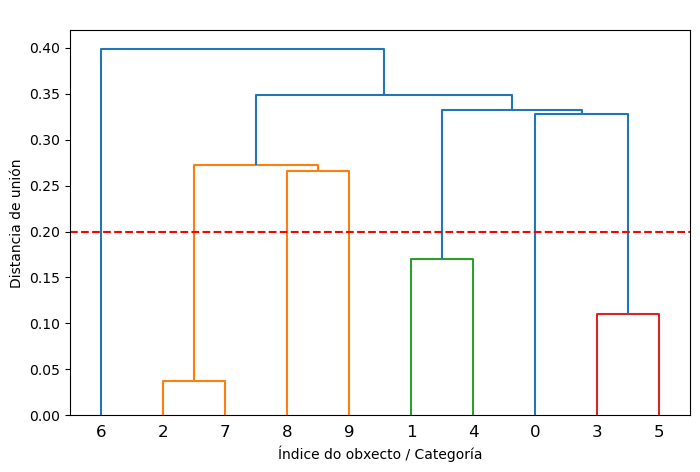

In [3]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
import numpy as np

# Creamos 10 puntos simulados en 2D (simulando coordenadas da CA)
np.random.seed(42)
X_sim = np.random.rand(10, 2)

# Aplicamos o mesmo método que no teu TFM (Mínimo/Single)
Z = linkage(X_sim, method='single')

plt.figure(figsize=(8, 5))
dendrogram(Z)
plt.axhline(y=0.2, color='r', linestyle='--') # Liña de corte teórica
plt.title(" ")
plt.xlabel("Índice do obxecto / Categoría")
plt.ylabel("Distancia de unión")
plt.show()

Como queremos predecir o volume de pedidos que teremos nun futuro para un cliente dado, vainos a facilitar a tarefa facer unha análise cluster dos clientes, posto que temos un número elevado de clientes. Así, unha vez feito o clustering, os nosos modelos predecirán o volume de pedidos para un tipo de cliente.

Comezamos lendo o csv onde temos a información sobre o sector de cada unha das rutas.

In [28]:
datos_cluster = pd.read_csv('TFM_cluster.csv', sep = ',', decimal='.')
del datos_cluster['comment']
datos_cluster.head(5)

,lane_zipcode,sector
0,NESTRADE: ES39 - GBDE,alimentacion
1,TAISA: DE80 - ES19,alimentacion
2,TARRADELLAS: ES08 - FR62,alimentacion
3,TARRADELLAS: ES08 - PL62,alimentacion
4,TARRADELLAS: FR62 - ES08,alimentacion


Agora debemos unir os dataframes para incluír a información do sector ao dataframe onde temos as nosas variables:

In [29]:
datos_com = datos.merge(datos_cluster, on='lane_zipcode', how='left')
datos_com['sector'] = datos_com['sector'].astype('category')
datos_com['sector'] = datos_com['sector'].cat.rename_categories({'fruta': 'froita'})
datos_com.head(5)

,id_trucksters,contract,lane_zipcode,client_name_complete,client_price,empty_km,loaded_km,po_price_empty,po_price_loaded,direction,...,route_start_date,total_km,pro_price,cl_price_km,pro_price_km,festivo,dia,semana,mes,sector
0,R20220202-CJH,fix,BSH: ES50 - NL40,BSH ELECTRODOMESTICOS ESPAÑA SA,1670.0,32,1552,30.40,1474.40,export,...,2022-01-31 12:00:00,1584,1504.8,1.054293,0.950000,0,2022-01-31,2022-01-31,2022-01-01,electrónica
1,R20220102-MDY,fix,BSH: ES50 - NL40,BSH ELECTRODOMESTICOS ESPAÑA SA,1670.0,0,1552,0.00,1474.40,export,...,2022-01-24 07:00:00,1552,1474.4,1.076031,0.950000,0,2022-01-24,2022-01-24,2022-01-01,electrónica
2,R20220106-QVB,fix,BSH: ES50 - NL40,BSH ELECTRODOMESTICOS ESPAÑA SA,1670.0,411,1553,390.45,1475.35,export,...,2022-01-10 07:00:00,1964,1865.8,0.850305,0.950000,0,2022-01-10,2022-01-10,2022-01-01,electrónica
3,R20220101-JTX,fix,BSH: ES50 - NL40,BSH ELECTRODOMESTICOS ESPAÑA SA,1670.0,428,1552,385.20,1552.00,export,...,2022-01-18 08:00:00,1980,1937.2,0.843434,0.978384,0,2022-01-18,2022-01-17,2022-01-01,electrónica
4,R20220101-QJU,fix,CROWDFARMING: ES46 - DE67,CROWDFARMING S.L.,2067.0,10,1587,8.00,1745.70,export,...,2022-01-11 08:00:00,1597,1753.7,1.294302,1.098121,0,2022-01-11,2022-01-10,2022-01-01,froita


In [30]:
datos_com['sector'].cat.categories

Index(['alimentacion', 'electrónica', 'froita', 'industria', 'paqueteria',
       'retail', 'transporte'],
      dtype='object')

Para facer a análise cluster, teremos en conta o sector ao que pertence o cliente, así como o tipo de contrato que se ten co mesmo. Vemos que, os clientes que temos na base de datos pertencen a 7 tipos de sectores distintos e ademáis existen dous tipos de contratos (fixo ou secundario). A idea é formar clusters (3/4) para despois facer a predición do volume de envíos para un cluster en particular. Isto é, dado un cliente, saber a que cluster correspondería e facer a predición correspondente.

In [31]:
tabla = pd.crosstab(datos_com['sector'], datos_com['contract'])
print(tabla)

contract       fix  spot
sector                  
alimentacion  1063   111
electrónica    781   490
froita         572     2
industria     1173   188
paqueteria    9535   211
retail        1878  1661
transporte    1233   971


Unha vez creada a táboa de continxencia coas frecuencias absolutas (temos a cantidade de envíos de cada sector e tipo de contrato), podemos facer un análise de correspondencias para ver a relación entre estas dúas variables categóricas. Así, unha vez feita a análise de correspondencias (CA), obtemos unhas coordenadas (a distancia interprétase en termos de proximidade-similitude entre os clientes) que podemos empregar para facer os clusters.

Para comezar, debemos facer un test de independenza. A CA baseáse en estudar a relación entre dúas variables categóricas, se non existe relación (independenza) non ten sentido facer dita análise. Empregamos o test ji-cadrado:

In [32]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(tabla)


print(f"Estadístico chi-cuadrado: {chi2:.3f}")
print(f"Grados de libertade: {dof}")
print(f"Valor p: {p:.5f}")


Estadístico chi-cuadrado: 5170.131
Grados de libertade: 6
Valor p: 0.00000


Claramente rexeitamos a independenza das variables. Co cal, ten sentido que nos plantexemos o CA.

Cómpre recordar que a análise de correspondencias consiste en aplicar unha análise de compoñentes principais (PCA) aos perfís de fila (ou columna) estandarizados, que se calculan a partires da tabla de continxencia. 

In [33]:
# Crear modelo de CA
ca = prince.CA(
    n_components=1,   # Número de dimensions factoriais a reter, o CA sempre obtén como
                      # máximo min(I-1,J-1) variables (neste caso será 1)     
    n_iter=10,   # nº de iteracións internas  
    copy=True, # fai unha copia do dataframe
    check_input=True, # comproba validez dos datos de entrada
    engine='sklearn', # librería interna que fai os cálculos
    random_state=2810 # semente por si é preciso
)

# Ajustar el modelo y transformar los datos
ca = ca.fit(tabla)
row_coords = ca.row_coordinates(tabla)
col_coords = ca.column_coordinates(tabla)

print("\nCoordenadas factoriales de las filas:")
print(row_coords)

print("\nCoordenadas factoriales de las columnas:")
print(col_coords)



Coordenadas factoriales de las filas:
                     0
sector                
alimentacion -0.228539
electrónica   0.524144
froita       -0.464101
industria    -0.115795
paqueteria   -0.417111
retail        0.740963
transporte    0.666519

Coordenadas factoriales de las columnas:
                 0
contract          
fix      -0.241340
spot      1.078193


Notemos que, na análise de correspondencias sempre imos perder unha dimensión (pola condición de que os perfís de fila suman 1 por columnas). Daquela, como temos 7 sectores e 2 tipos de contratos, quedaremos con 1 dimensión ao facer dita análise. Polo tanto, imos representar as categorías nunha recta. A partir destas posicións, poderiamos facer grupos (clusters) agrupando os clientes con comportamento similar.

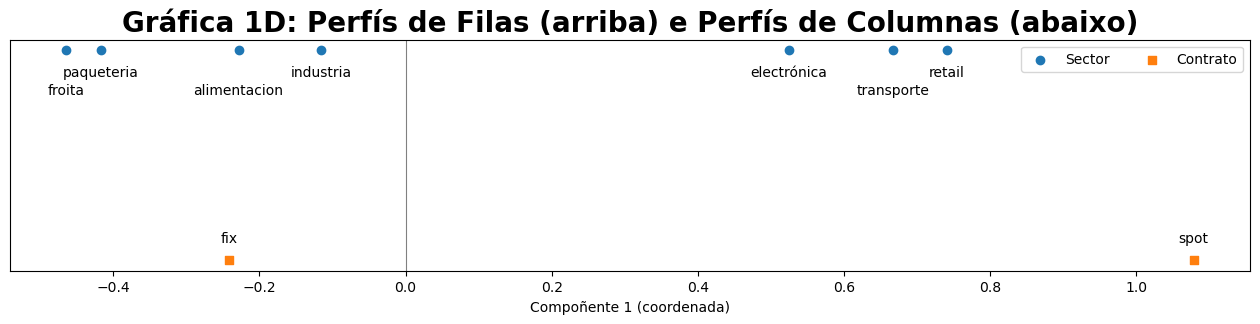

In [34]:
# Ejemplo: suponer row_coords y col_coords como DataFrames
x_rows = row_coords.iloc[:, 0]
x_cols = col_coords.iloc[:, 0]

plt.figure(figsize=(16,3))
y_rows = [1]* len(x_rows)   # separaciones verticales para evitar solapado con columnas
y_cols = [-0.15] * len(x_cols)

plt.scatter(x_rows, y_rows, marker='o', label='Sector', zorder=3)
plt.scatter(x_cols, y_cols, marker='s', label='Contrato', zorder=3)


vertical_offset_rows = 0.16 # Offset original para las filas
vertical_offset_cols = 0.16 # Offset original para las columnas

for i, txt in enumerate(row_coords.index):
    # Condición para mover etiquetas específicas hacia abajo
    y_adjust = y_rows[i] - vertical_offset_rows # Posición base
    
    if txt in ['froita', 'alimentacion', 'transporte']: # Etiquetas problemáticas que quiero mover más abajo
        y_adjust -= 0.1 # Mover estas 0.1 unidades más abajo
    
    plt.text(x_rows.iloc[i], y_adjust, txt, ha='center', va='bottom', fontsize=10)

for i, txt in enumerate(col_coords.index):
    # Aquí parece que no hay solapamiento, pero mantengo la estructura
    plt.text(x_cols.iloc[i], y_cols[i] + vertical_offset_cols, txt, ha='center', va='top', fontsize=10)


plt.axvline(0, color='grey', lw=0.8)
plt.yticks([])
plt.xlabel('Compoñente 1 (coordenada)')
plt.title('Gráfica 1D: Perfís de Filas (arriba) e Perfís de Columnas (abaixo)',
          fontdict={'fontsize': 20, 'fontweight': 'bold'})
plt.legend(ncol=2)
plt.show()


Unha vez feita a CA, podemos construír os clusters. Graficamente, tendo en conta as coordenadas obtidas mediante dita análise, pode ter sentido formar 3 clusters. Vexámolo:

In [ ]:
# Estandarizar coordenadas (opcional pero recomendable non creo que faga falta neste caso)
X = row_coords

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# clusters aglomerativos co método do mínimo
Z = linkage(X, method='single')

# Cortar o dendrograma para formar K clusters
K_opt = 3  
labels_h = fcluster(Z, K_opt, criterion='maxclust')
row_coords["Cluster"] = labels_h
print(row_coords)

                     0  Cluster
sector                         
alimentacion -0.228539        3
electrónica   0.524144        1
froita       -0.464101        2
industria    -0.115795        3
paqueteria   -0.417111        2
retail        0.740963        1
transporte    0.666519        1


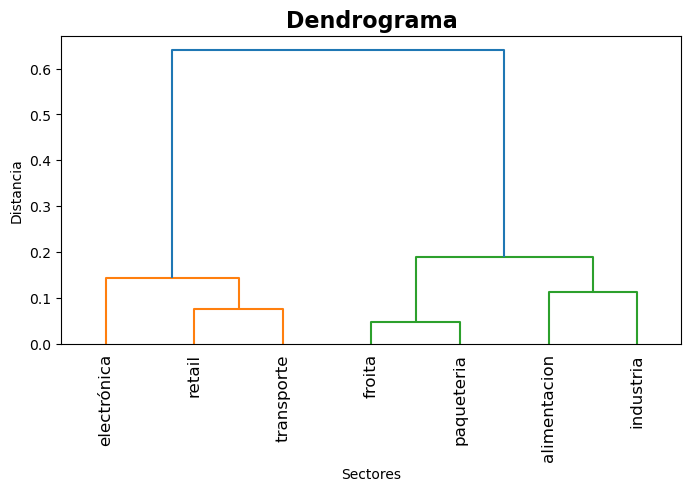

In [36]:
# Dendrograma
plt.figure(figsize=(8, 4))
dendrogram(Z, labels=row_coords.index, leaf_rotation=90)
plt.title('Dendrograma', fontdict={'fontsize': 16, 'fontweight': 'bold'})
plt.xlabel('Sectores')
plt.ylabel('Distancia')
plt.show()


Vemos entón que se poden formar 3 clusters: un formado polos clientes dos sectores retail, transporte e electrónica. O segundo formado polos clientes de paquetería e froita, e o último formado polos sectores de alimentación e industria.

Agora, podemos engadir esta información á nosa base de datos e continuar coa análise exploratoria en función do tipo de cliente.

In [37]:
row_coords = row_coords.reset_index()  
print(row_coords)

         sector         0  Cluster
0  alimentacion -0.228539        3
1   electrónica  0.524144        1
2        froita -0.464101        2
3     industria -0.115795        3
4    paqueteria -0.417111        2
5        retail  0.740963        1
6    transporte  0.666519        1


In [38]:
datos = datos_com.merge(
    row_coords[["sector", "Cluster"]],
    on="sector",
    how="left"   # mantiene todos los clientes, incluso si alguno no tiene cluster
)
datos.head(5)

,id_trucksters,contract,lane_zipcode,client_name_complete,client_price,empty_km,loaded_km,po_price_empty,po_price_loaded,direction,...,total_km,pro_price,cl_price_km,pro_price_km,festivo,dia,semana,mes,sector,Cluster
0,R20220202-CJH,fix,BSH: ES50 - NL40,BSH ELECTRODOMESTICOS ESPAÑA SA,1670.0,32,1552,30.40,1474.40,export,...,1584,1504.8,1.054293,0.950000,0,2022-01-31,2022-01-31,2022-01-01,electrónica,1
1,R20220102-MDY,fix,BSH: ES50 - NL40,BSH ELECTRODOMESTICOS ESPAÑA SA,1670.0,0,1552,0.00,1474.40,export,...,1552,1474.4,1.076031,0.950000,0,2022-01-24,2022-01-24,2022-01-01,electrónica,1
2,R20220106-QVB,fix,BSH: ES50 - NL40,BSH ELECTRODOMESTICOS ESPAÑA SA,1670.0,411,1553,390.45,1475.35,export,...,1964,1865.8,0.850305,0.950000,0,2022-01-10,2022-01-10,2022-01-01,electrónica,1
3,R20220101-JTX,fix,BSH: ES50 - NL40,BSH ELECTRODOMESTICOS ESPAÑA SA,1670.0,428,1552,385.20,1552.00,export,...,1980,1937.2,0.843434,0.978384,0,2022-01-18,2022-01-17,2022-01-01,electrónica,1
4,R20220101-QJU,fix,CROWDFARMING: ES46 - DE67,CROWDFARMING S.L.,2067.0,10,1587,8.00,1745.70,export,...,1597,1753.7,1.294302,1.098121,0,2022-01-11,2022-01-10,2022-01-01,froita,2


### Análise descritivo por cluster

Facemos o propio para cada cluster, co fin de obter máis información.

**Prezos por kilómetro**

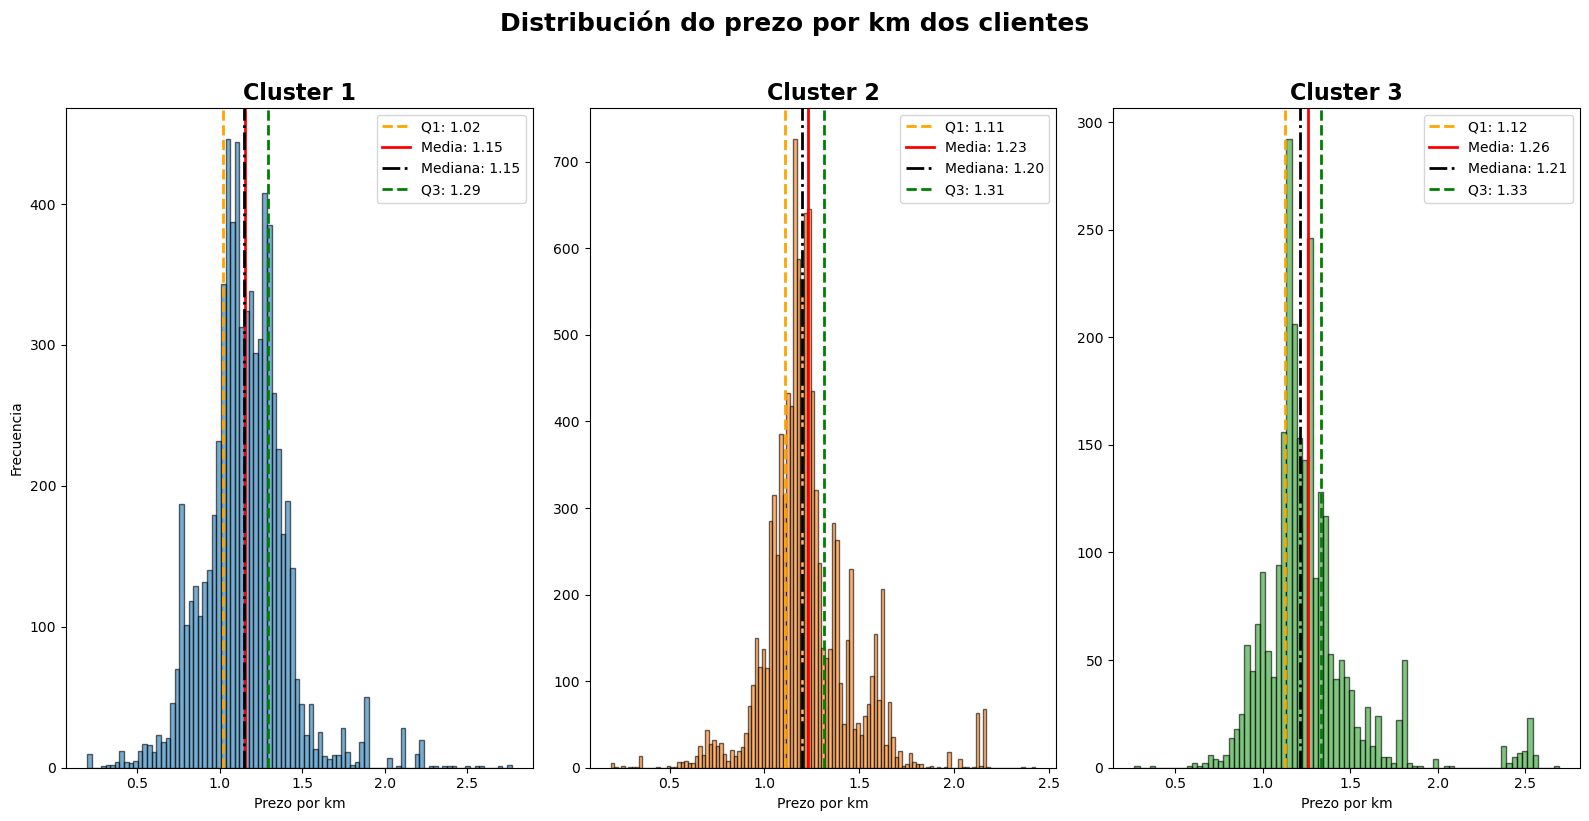

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Configuración de la figura: 1 fila, 3 columnas
# sharey=True hace que todos compartan la misma escala en el eje Y (útil para comparar alturas)
fig, axes = plt.subplots(1, 3, figsize=(16, 8), sharey=False)

# Definimos los colores para mantener la consistencia con tus gráficas anteriores
colors = ['tab:blue', 'tab:orange', 'tab:green']
clusters = sorted(datos['Cluster'].unique()) # Aseguramos el orden (0, 1, 2...)

# 2. Bucle para iterar sobre cada cluster y su eje correspondiente
for ax, cluster_id, color in zip(axes, clusters, colors):
    
    # A. Filtramos los datos solo para el cluster actual
    subset = datos[datos['Cluster'] == cluster_id]
    data_col = subset['cl_price_km']
    
    # B. Calcular estadísticas ESPECÍFICAS para este cluster
    q25 = np.quantile(data_col, 0.25)
    median = np.median(data_col)
    q75 = np.quantile(data_col, 0.75)
    mean = np.mean(data_col)
    
    # C. Regla de Freedman-Diaconis (calculada sobre el subset actual)
    # Si el rango intercuartílico es 0, usamos un valor por defecto para evitar errores
    iqr = q75 - q25
    if iqr > 0:
        h = 2 * iqr / (len(data_col) ** (1/3))
        bins = int(np.ceil((data_col.max() - data_col.min()) / h))
    else:
        bins = 20 # Valor por defecto si los datos son muy constantes
        
    # D. Crear el histograma en el eje actual (ax)
    ax.hist(data_col, bins=bins, color=color, edgecolor='black', alpha=0.6)
    
    # E. Añadir líneas verticales (usando las estadísticas locales)
    ax.axvline(q25, color='orange', linestyle='--', linewidth=2, label=f'Q1: {q25:.2f}')
    ax.axvline(mean, color='red', linestyle='-', linewidth=2, label=f'Media: {mean:.2f}')
    ax.axvline(median, color='black', linestyle='-.', linewidth=2, label=f'Mediana: {median:.2f}')
    ax.axvline(q75, color='green', linestyle='--', linewidth=2, label=f'Q3: {q75:.2f}')
    
    # F. Títulos y etiquetas para cada panel
    ax.set_title(f"Cluster {cluster_id}", fontsize=16, fontweight='bold')
    ax.set_xlabel("Prezo por km")
    if cluster_id == clusters[0]: # Solo poner etiqueta Y en el primer gráfico para limpieza
        ax.set_ylabel("Frecuencia")
    
    ax.legend()

# Título global
plt.suptitle("Distribución do prezo por km dos clientes", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

/var/folders/72/92sdss296tdg9zgnwr3xcg180000gn/T/ipykernel_7234/2833196794.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


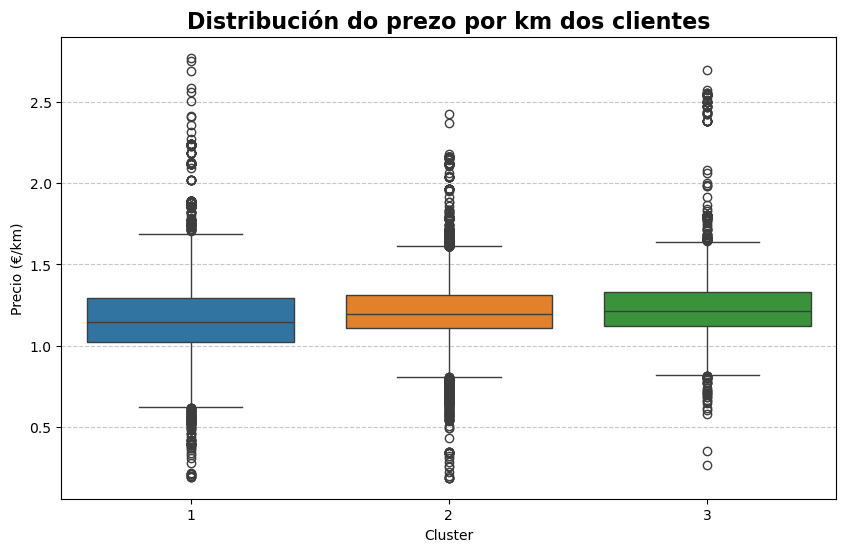

In [40]:
# 1. Configuración de la figura
plt.figure(figsize=(10, 6))

# 2. Definir tus colores (mismos que usaste en el gráfico Lowess)
colors = ['tab:blue', 'tab:orange', 'tab:green']

# 3. Crear el Boxplot
# x='Cluster': Pone los clusters en el eje horizontal (uno al lado del otro)
# y='cl_price_km': La variable que queremos medir (altura del boxplot)
sns.boxplot(
    x='Cluster', 
    y='cl_price_km', 
    data=datos, 
    palette=colors  # Asigna tus colores específicos
)

# 4. Títulos y Etiquetas
plt.title('Distribución do prezo por km dos clientes', fontdict={'fontsize': 16, 'fontweight': 'bold'})
plt.xlabel('Cluster')
plt.ylabel('Precio (€/km)')

# Opcional: Añadir grid en el eje Y para ver mejor los niveles de precio
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Para os proveedores:

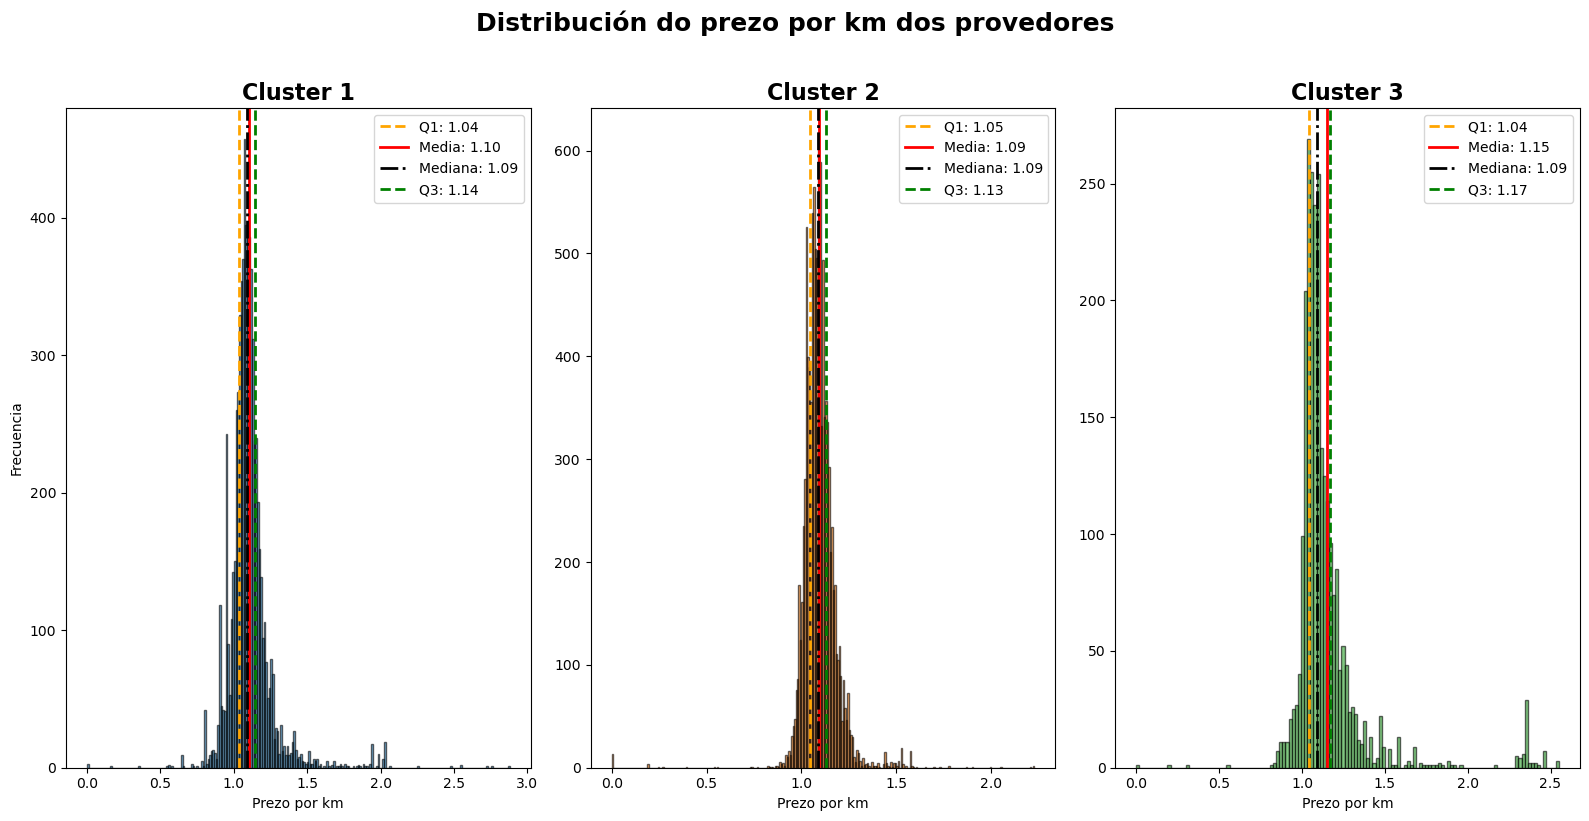

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Configuración de la figura: 1 fila, 3 columnas
# sharey=True hace que todos compartan la misma escala en el eje Y (útil para comparar alturas)
fig, axes = plt.subplots(1, 3, figsize=(16, 8), sharey=False)

# Definimos los colores para mantener la consistencia con tus gráficas anteriores
colors = ['tab:blue', 'tab:orange', 'tab:green']
clusters = sorted(datos['Cluster'].unique()) # Aseguramos el orden (0, 1, 2...)

# 2. Bucle para iterar sobre cada cluster y su eje correspondiente
for ax, cluster_id, color in zip(axes, clusters, colors):
    
    # A. Filtramos los datos solo para el cluster actual
    subset = datos[datos['Cluster'] == cluster_id]
    data_col = subset['pro_price_km']
    
    # B. Calcular estadísticas ESPECÍFICAS para este cluster
    q25 = np.quantile(data_col, 0.25)
    median = np.median(data_col)
    q75 = np.quantile(data_col, 0.75)
    mean = np.mean(data_col)
    
    # C. Regla de Freedman-Diaconis (calculada sobre el subset actual)
    # Si el rango intercuartílico es 0, usamos un valor por defecto para evitar errores
    iqr = q75 - q25
    if iqr > 0:
        h = 2 * iqr / (len(data_col) ** (1/3))
        bins = int(np.ceil((data_col.max() - data_col.min()) / h))
    else:
        bins = 20 # Valor por defecto si los datos son muy constantes
        
    # D. Crear el histograma en el eje actual (ax)
    ax.hist(data_col, bins=bins, color=color, edgecolor='black', alpha=0.6)
    
    # E. Añadir líneas verticales (usando las estadísticas locales)
    ax.axvline(q25, color='orange', linestyle='--', linewidth=2, label=f'Q1: {q25:.2f}')
    ax.axvline(mean, color='red', linestyle='-', linewidth=2, label=f'Media: {mean:.2f}')
    ax.axvline(median, color='black', linestyle='-.', linewidth=2, label=f'Mediana: {median:.2f}')
    ax.axvline(q75, color='green', linestyle='--', linewidth=2, label=f'Q3: {q75:.2f}')
    
    # F. Títulos y etiquetas para cada panel
    ax.set_title(f"Cluster {cluster_id}", fontsize=16, fontweight='bold')
    ax.set_xlabel("Prezo por km")
    if cluster_id == clusters[0]: # Solo poner etiqueta Y en el primer gráfico para limpieza
        ax.set_ylabel("Frecuencia")
    
    ax.legend()

# Título global
plt.suptitle("Distribución do prezo por km dos provedores", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

/var/folders/72/92sdss296tdg9zgnwr3xcg180000gn/T/ipykernel_7234/317604857.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


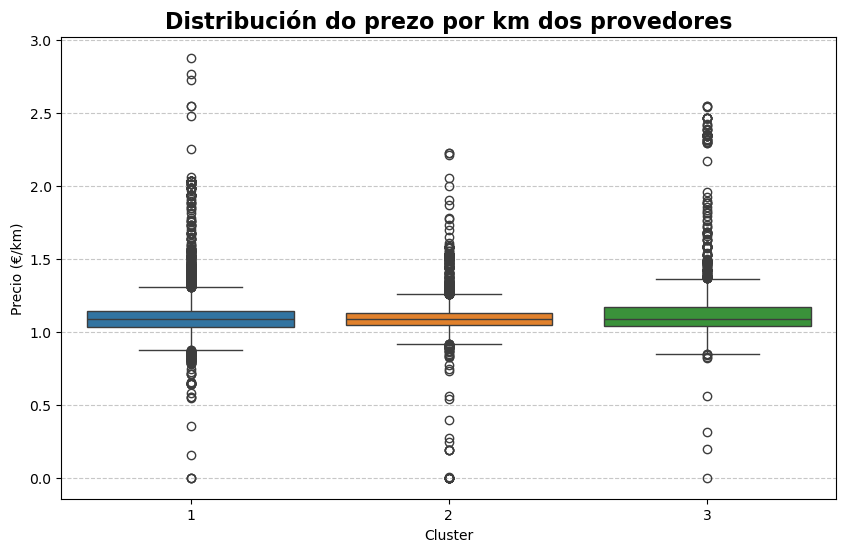

In [42]:
# 1. Configuración de la figura
plt.figure(figsize=(10, 6))

# 2. Definir tus colores (mismos que usaste en el gráfico Lowess)
colors = ['tab:blue', 'tab:orange', 'tab:green']

# 3. Crear el Boxplot
# x='Cluster': Pone los clusters en el eje horizontal (uno al lado del otro)
# y='cl_price_km': La variable que queremos medir (altura del boxplot)
sns.boxplot(
    x='Cluster', 
    y='pro_price_km', 
    data=datos, 
    palette=colors  # Asigna tus colores específicos
)

# 4. Títulos y Etiquetas
plt.title('Distribución do prezo por km dos provedores', fontdict={'fontsize': 16, 'fontweight': 'bold'})
plt.xlabel('Cluster')
plt.ylabel('Precio (€/km)')

# Opcional: Añadir grid en el eje Y para ver mejor los niveles de precio
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Evolución do prezo do km 

Comezamos estudando como é o comportamento do prezo do km tanto para os proveedores coma os clientes. Esta variable pode resultarnos de gran axuda posto que, ao aumentar a demanda, os proveedores aumentarán o prezo dos camións e, polo tanto, tamén vai aumentar o prezo dos clientes.

Comezaremos facendo un estudo mensual, para o cal consideraremos o prezo medio ao longo do mes. Posteriormente faremos o propio semanalmente.

Cómpre sinalar que estas variables permitirannos detectar outliers.

Comezamos estudando a evolución do prezo para os clientes:

In [43]:
prezo_por_mes = datos.groupby('mes')['cl_price_km'].mean().reset_index()

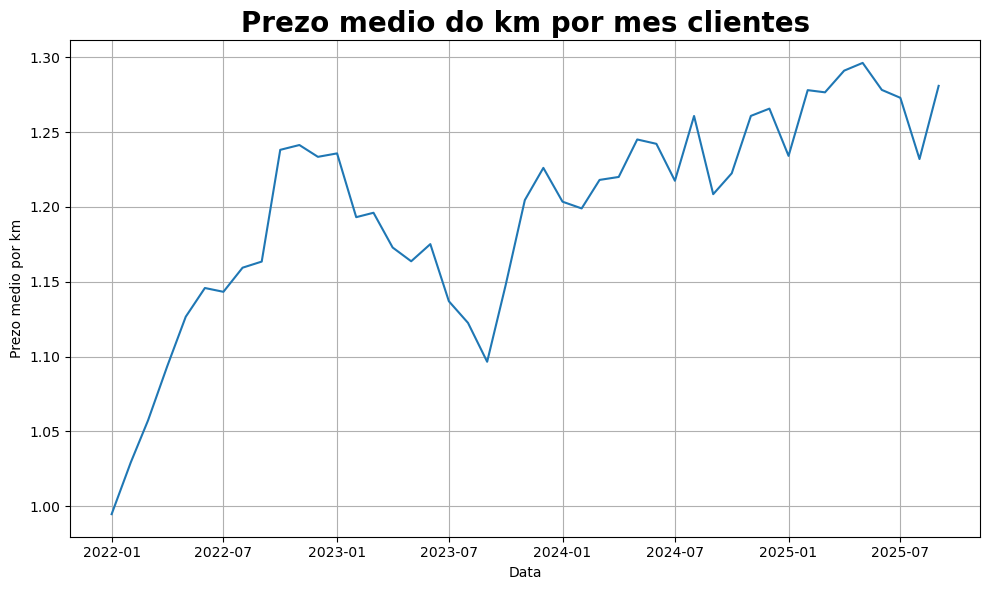

In [44]:
plt.figure(figsize=(10, 6))
plt.plot(prezo_por_mes['mes'], prezo_por_mes['cl_price_km'])
plt.title('Prezo medio do km por mes clientes', fontdict={'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Data')
plt.ylabel('Prezo medio por km')
plt.grid(True)
plt.xticks()
plt.tight_layout()
plt.show()

Facemos o propio semanalmente:

In [45]:
prezo_por_semana = datos.groupby('semana')['cl_price_km'].mean().reset_index()

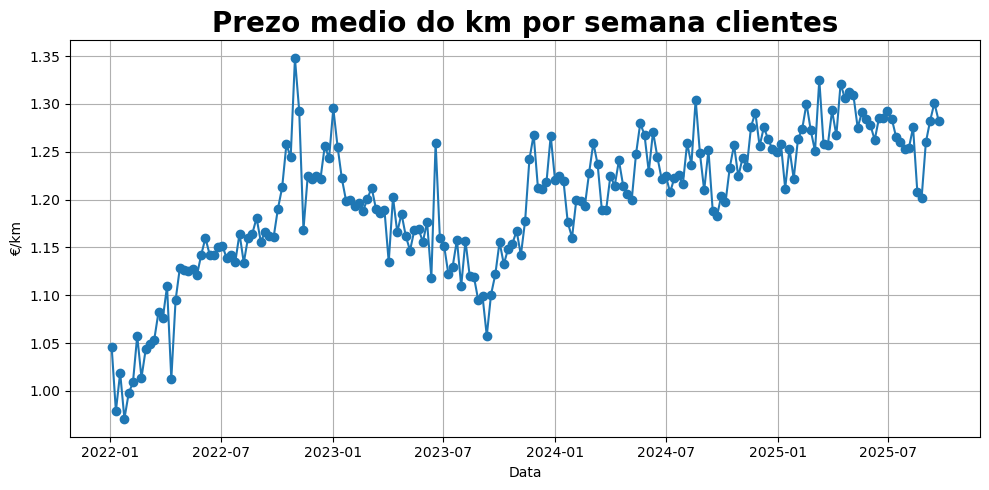

In [46]:
plt.figure(figsize=(10, 5))
plt.plot(prezo_por_semana['semana'], prezo_por_semana['cl_price_km'], marker='o')
plt.title('Prezo medio do km por semana clientes', fontdict={'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Data')
plt.ylabel('€/km')
plt.grid(True)
plt.xticks()
plt.tight_layout()
plt.show()

Observamos como durante o ano 2022, o prezo medio por semana foi aumentando chegando a valores próximos ao máximo histórico (1.35€/km) no último terzo do ano, producíndose posteriormente unha caída considerable dos prezos. Nos primeiros dous terzos do ano 2023 a tendencia do prezo é descendente chamando a atención o caso da última semana do mes de xuño, onde se produce unha subida dende 1.10€ a máis de 1.25€. A partir do mes de outubro aproximadamente os prezos volven a subir chegando a valores similares dos de finais do ano anterior. Nos anos 2024 e 2025 obsérvase unha lixeira tendencia crecente pero manténdose bastante máis constante (non volven a caer por debaixo dos 1.15€), sendo salientable o caso do último dato dispoñible (última semana do mes de septembro), onde se chegan a superar os 1.35€

In [47]:
datos[datos['cl_price_km'] >= 2.5].shape[0]

37

Podemos facer o propio distinguindo entre os tipos de clientes que temos, mediante os 3 clusters construídos no apartado anterior:

Mensualmente:

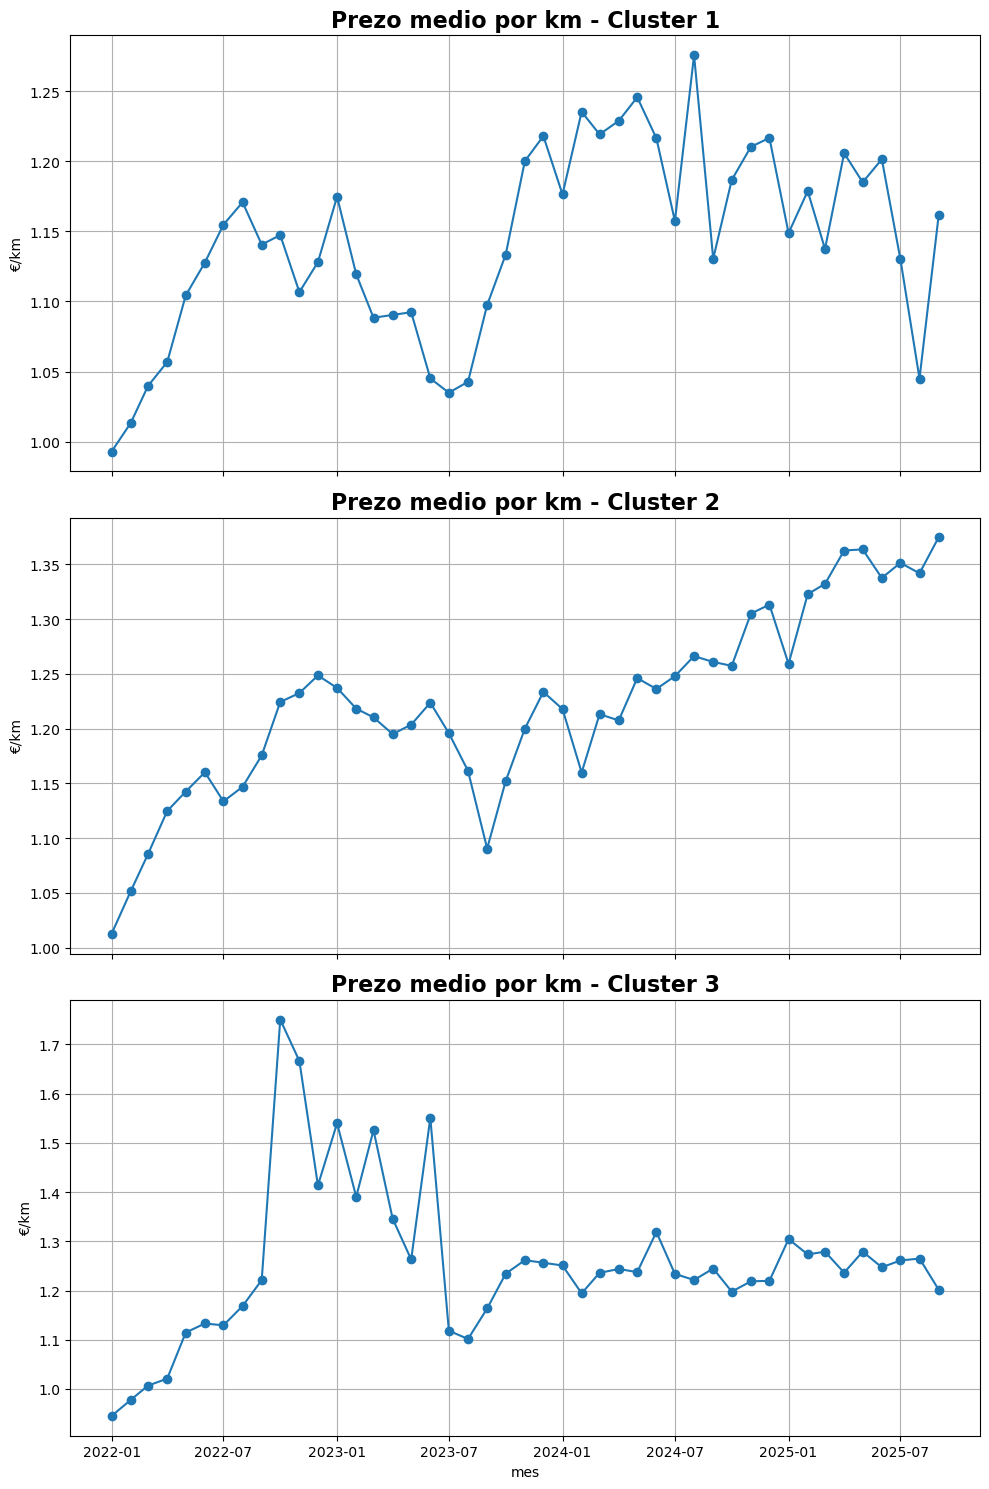

In [48]:
prezo_por_mes_cluster = (
    datos.groupby(['mes', 'Cluster'])['cl_price_km'].mean()
    .reset_index()
)

clusters = prezo_por_mes_cluster['Cluster'].unique()
fig, axes = plt.subplots(len(clusters), 1, figsize=(10, 5 * len(clusters)), sharex=True)

for i, cluster_id in enumerate(clusters):
    cluster_data = prezo_por_mes_cluster[prezo_por_mes_cluster['Cluster'] == cluster_id]
    axes[i].plot(cluster_data['mes'], cluster_data['cl_price_km'], marker='o')
    axes[i].set_title(f'Prezo medio por km - Cluster {cluster_id}', fontdict={'fontsize': 16, 'fontweight': 'bold'})
    axes[i].set_ylabel('€/km')
    axes[i].grid(True)

axes[-1].set_xlabel('mes')  # Solo la última figura tiene xlabel
plt.xticks()
plt.tight_layout()
plt.show()

Semanalmente:

In [49]:
prezo_por_semana_cluster = (
    datos.groupby(['semana', 'Cluster'])['cl_price_km'].mean()
    .reset_index()
)
prezo_por_semana_cluster.head(5)

,semana,Cluster,cl_price_km
0,2022-01-03,1,0.976276
1,2022-01-03,2,1.150811
2,2022-01-03,3,0.839107
3,2022-01-10,1,1.007252
4,2022-01-10,2,0.967090


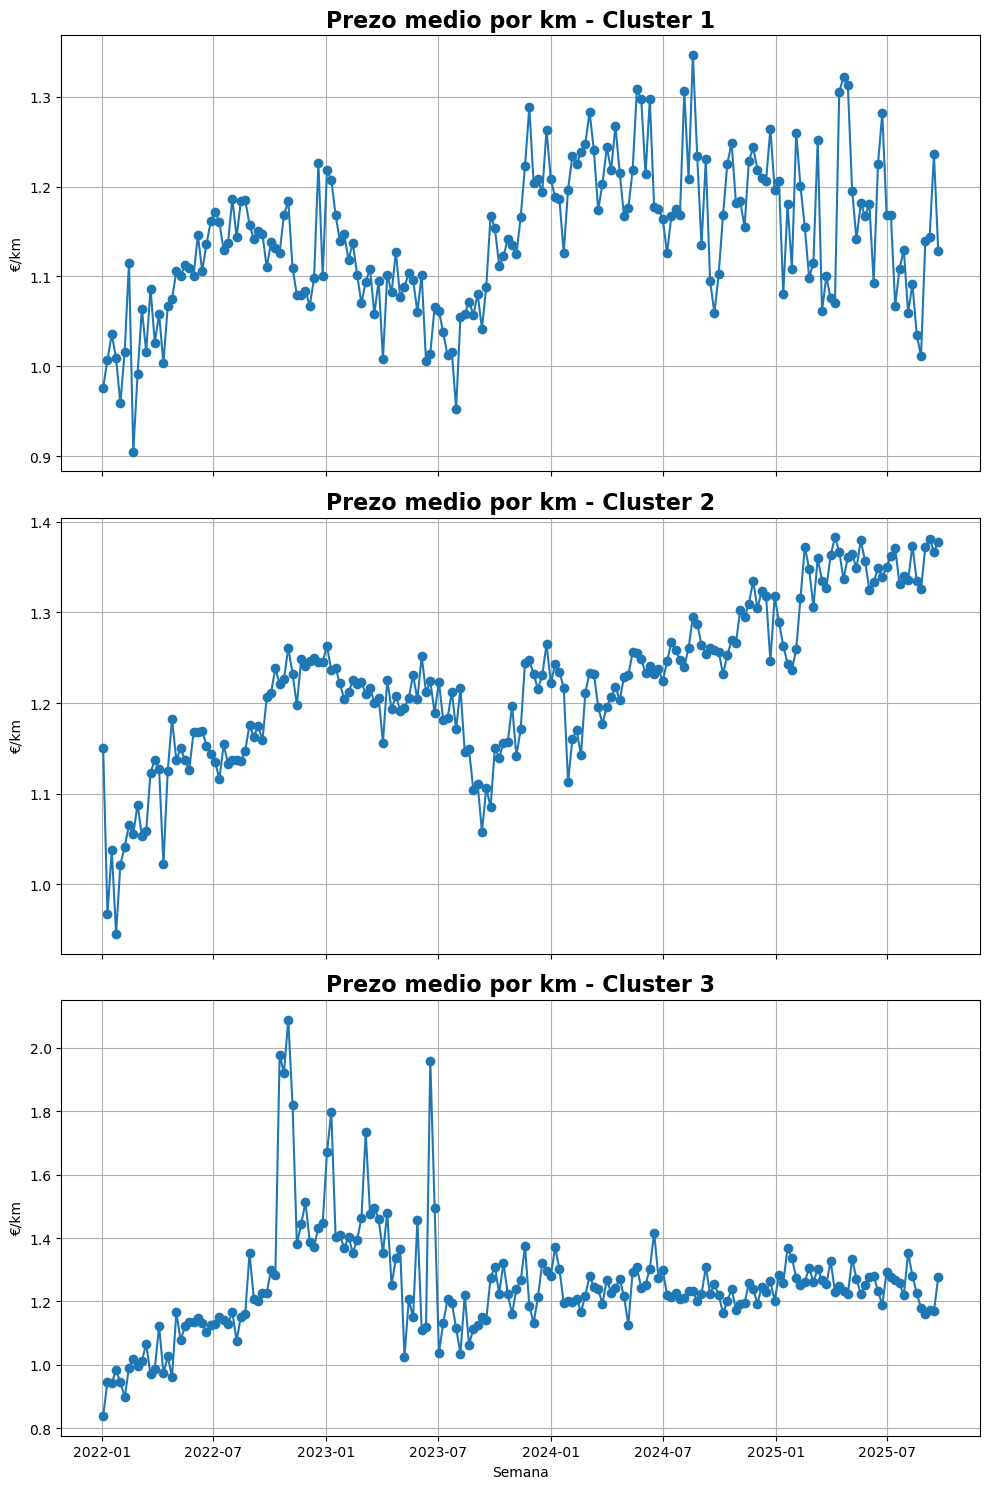

In [50]:
clusters = prezo_por_semana_cluster['Cluster'].unique()
fig, axes = plt.subplots(len(clusters), 1, figsize=(10, 5 * len(clusters)), sharex=True)

for i, cluster_id in enumerate(clusters):
    cluster_data = prezo_por_semana_cluster[prezo_por_semana_cluster['Cluster'] == cluster_id]
    axes[i].plot(cluster_data['semana'], cluster_data['cl_price_km'], marker='o')
    axes[i].set_title(f'Prezo medio por km - Cluster {cluster_id}', fontdict={'fontsize': 16, 'fontweight': 'bold'})
    axes[i].set_ylabel('€/km')
    axes[i].grid(True)

axes[-1].set_xlabel('Semana')  # Solo la última figura tiene xlabel
plt.xticks()
plt.tight_layout()
plt.show()


Repetimos o proceso cos proveedores.

In [51]:
pro_prezo_por_mes = datos.groupby('mes')['pro_price_km'].mean().reset_index()

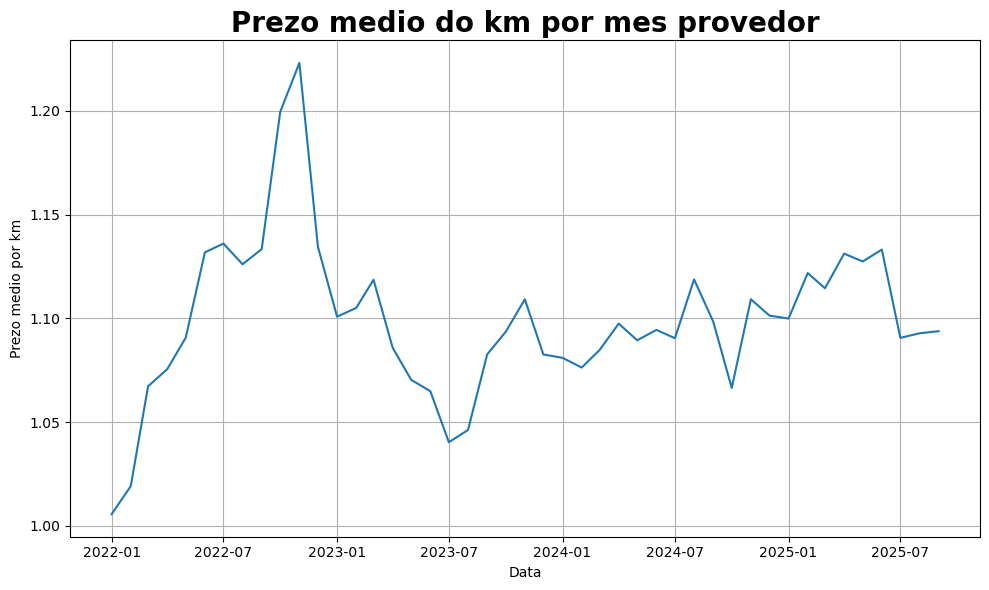

In [101]:
plt.figure(figsize=(10, 6))
plt.plot(pro_prezo_por_mes['mes'], pro_prezo_por_mes['pro_price_km'])
plt.title('Prezo medio do km por mes provedor', fontdict={'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Data')
plt.ylabel('Prezo medio por km')
plt.grid(True)
plt.xticks()
plt.tight_layout()
plt.show()

Aquí vemos mais claro coma nos meses de outubro e novembro de 2022 se alcanzaron prezos moi superiores ao resto dos observados, o cal nos fai pensar que os datos que vimos anteriormente son outliers.

Agora semanalmente verase todavía mellor:

In [53]:
pro_prezo_por_semana = datos.groupby('semana')['pro_price_km'].mean().reset_index()

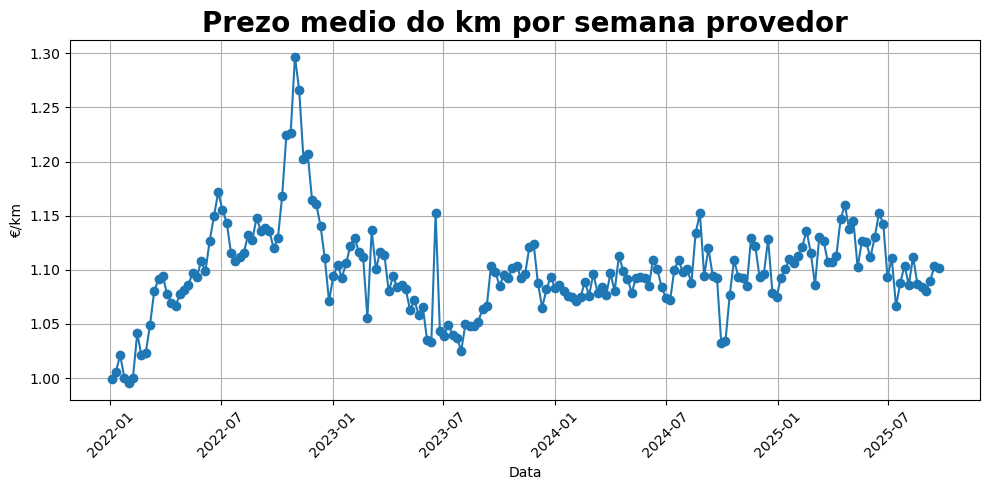

In [102]:
plt.figure(figsize=(10, 5))
plt.plot(pro_prezo_por_semana['semana'], pro_prezo_por_semana['pro_price_km'], marker='o')
plt.title('Prezo medio do km por semana provedor', fontdict={'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Data')
plt.ylabel('€/km')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Efectivamente, vemos como o prezo medio do km en varias semanas do último trimestre do 2022 é superior a 1.20€, valores que non se volveron a alcanzar nos tres anos seguintes. Outro valor que nos pode chamar a atención é o da penúltima semana de xuño do 2023, onde o prezo medio pasa de ser inferior a 1.05€ o km tanto na semana previa coma na posterior a superar os 1.15€, polo cal podemos pensar que ahí tamén temos algunha observación na cal nos debemos deter.

Podemos ver nun gráfico a información para clientes e proveedores para comparar os prezos ao longo do tempo.

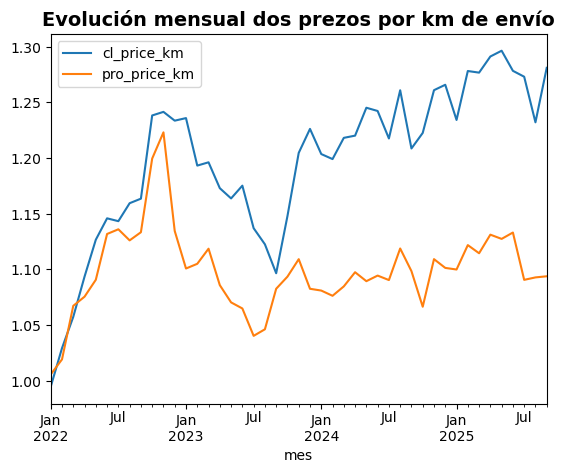

In [55]:
datos.groupby('mes')[['cl_price_km', 'pro_price_km']].mean().plot()
plt.title('Evolución mensual dos prezos por km de envío', fontdict={'fontsize': 14, 'fontweight': 'bold'})
plt.show()

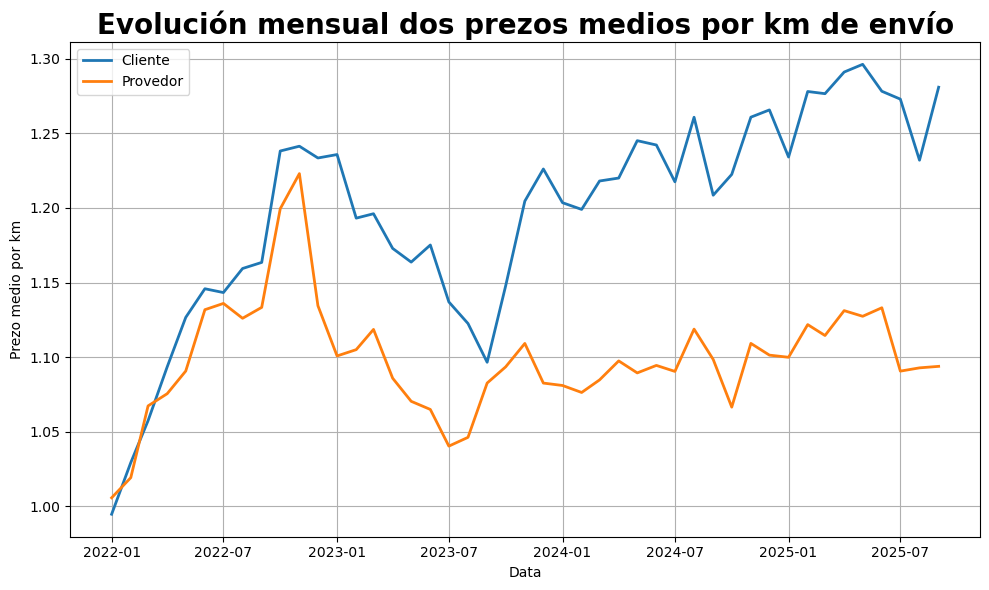

In [56]:
# 1. PREPARACIÓN DE DATOS
# Agrupamos por mes y calculamos la media.
# Es importante usar .reset_index() para poder usar la columna 'mes' en el eje X
datos_mensuales = datos.groupby('mes')[['cl_price_km', 'pro_price_km']].mean().reset_index()

# 2. CONFIGURACIÓN DE LA GRÁFICA
plt.figure(figsize=(10, 6))

# Definimos las variables a pintar, sus colores y sus etiquetas para la leyenda
variables_a_pintar = ['cl_price_km', 'pro_price_km']
labels = ['Cliente', 'Provedor']
colors = ['tab:blue', 'tab:orange']

# 3. BUCLE DE DIBUJO (Iteramos sobre las variables en lugar de clusters)
for i, var_name in enumerate(variables_a_pintar):
    
    # Pintamos directamente la columna del dataframe sin suavizar
    # Añadimos marker='o' para ver claramente el punto de cada mes
    plt.plot(datos_mensuales['mes'], datos_mensuales[var_name], 
             color=colors[i], 
             linewidth=2, 
             label=labels[i])

# 4. ESTÉTICA (Copiada de tu ejemplo original)
plt.title('Evolución mensual dos prezos medios por km de envío', fontdict={'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Data')
plt.ylabel('Prezo medio por km')
plt.grid(True)
plt.legend() # Muestra las etiquetas definidas arriba
plt.tight_layout()

plt.show()

Tamén podemos velo diariamente:

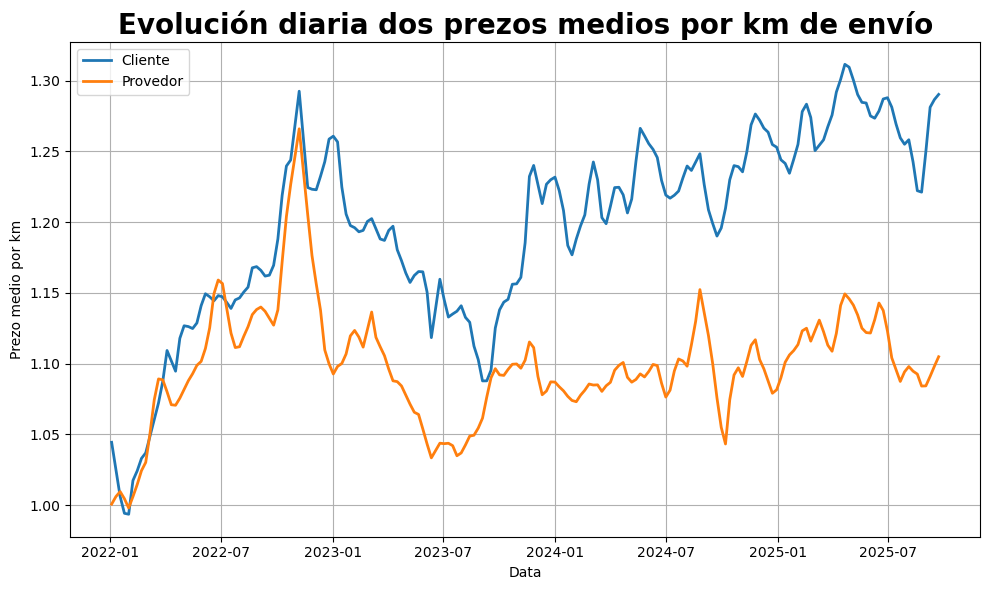

In [57]:
# 1. PREPARACIÓN DE DATOS
# Agrupamos por mes y calculamos la media.
# Es importante usar .reset_index() para poder usar la columna 'mes' en el eje X
datos_semanal = datos.groupby('semana')[['cl_price_km', 'pro_price_km']].mean().reset_index()

# 2. CONFIGURACIÓN DE LA GRÁFICA
plt.figure(figsize=(10, 6))

# Definimos las variables a pintar, sus colores y sus etiquetas para la leyenda
variables_a_pintar = ['cl_price_km', 'pro_price_km']
labels = ['Cliente', 'Provedor']
colors = ['tab:blue', 'tab:orange']

# 3. BUCLE DE DIBUJO (Iteramos sobre las variables en lugar de clusters)
for i, var_name in enumerate(variables_a_pintar):
    
    # Definimos X e Y
    # Asumimos que 'mes' es datetime. Lowess necesita números, convertimos a ordinal
    x_numeric = datos_semanal['semana'].map(pd.Timestamp.toordinal)
    y = datos_semanal[var_name]
    
    # Aplicamos LOWESS
    # NOTA: 'frac' controla el suavizado. 
    # 0.03 es bueno para muchos datos diarios. Para mensuales, quizás necesites 0.2 o 0.3
    smoothed = lowess(y, x_numeric, frac=0.03, return_sorted=False)
    
    # Pintamos la línea suavizada
    plt.plot(datos_semanal['semana'], smoothed, 
             color=colors[i], 
             linewidth=2, 
             label=labels[i])

# 4. ESTÉTICA (Copiada de tu ejemplo original)
plt.title('Evolución diaria dos prezos medios por km de envío', fontdict={'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Data')
plt.ylabel('Prezo medio por km')
plt.grid(True)
plt.legend() # Muestra las etiquetas definidas arriba
plt.tight_layout()

plt.show()

### Alternativa: prezos diarios suavizando

Podemos ver a evolución diaria dos prezos por kilómetro.

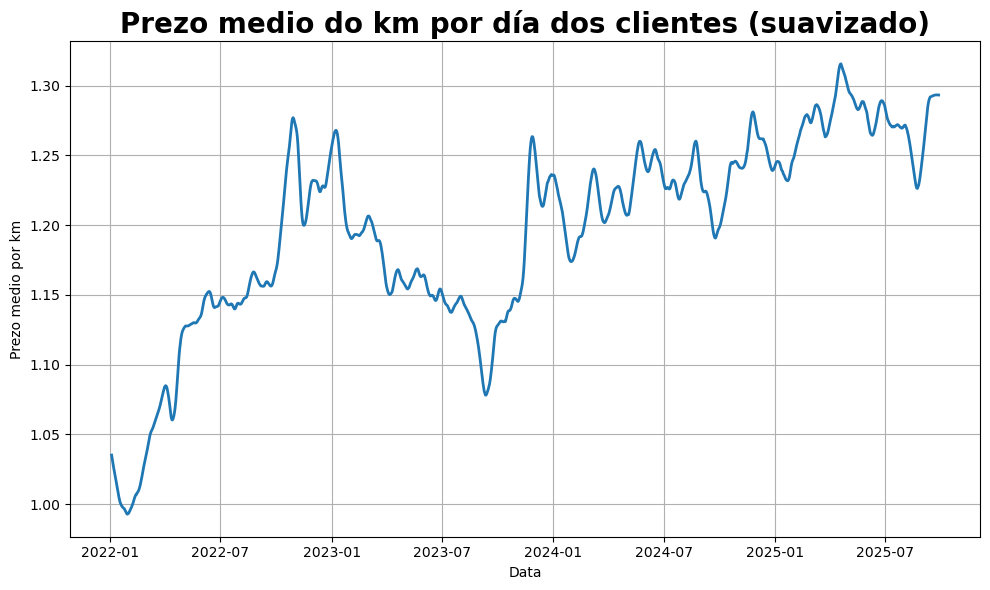

In [58]:
datos_por_dia = datos.groupby('dia')[['cl_price_km', 'pro_price_km']].mean().reset_index()

x = datos_por_dia['dia'].apply(lambda d: d.toordinal())
y = datos_por_dia['cl_price_km']

suavizado = lowess(y, x, frac=0.02)
# frac determina o porcentaxe de días próximos que entran no entorno de cada dato

suavizado_df = pd.DataFrame({
    'dia': [datetime.fromordinal(int(f)) for f in suavizado[:, 0]],
    'cl_price_km_suavizado': suavizado[:, 1]
})


plt.figure(figsize=(10, 6))

# Serie original
#plt.plot(datos_por_dia['dia'], datos_por_dia['cl_price_km'], label='Original', alpha=0.4)

# Serie suavizada
plt.plot(suavizado_df['dia'], suavizado_df['cl_price_km_suavizado'], label='LOWESS suavizado', linewidth=2)

plt.title('Prezo medio do km por día dos clientes (suavizado)',fontdict={'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Data')
plt.ylabel('Prezo medio por km')
#plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Facemos o propio para os provedores:

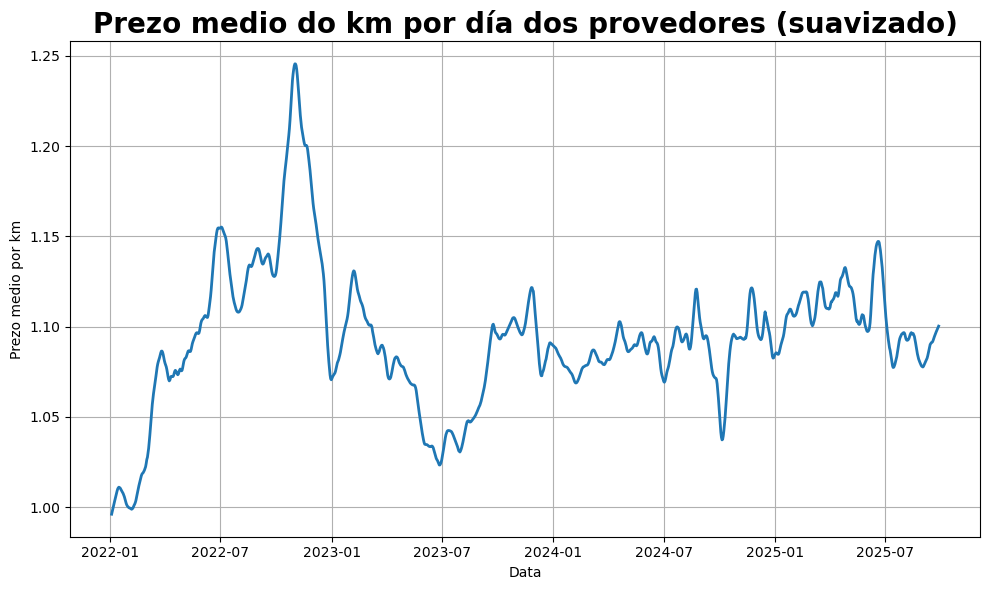

In [59]:
x = datos_por_dia['dia'].apply(lambda d: d.toordinal())
y = datos_por_dia['pro_price_km']

suavizado = lowess(y, x, frac=0.015)
# frac determina o porcentaxe de días próximos que entran no entorno de cada dato

suavizado_df = pd.DataFrame({
    'dia': [datetime.fromordinal(int(f)) for f in suavizado[:, 0]],
    'pro_price_km_suavizado': suavizado[:, 1]
})

plt.figure(figsize=(10, 6))

# Serie original
#plt.plot(datos_por_dia['dia'], datos_por_dia['pro_price_km'], label='Original', alpha=0.4)

# Serie suavizada
plt.plot(suavizado_df['dia'], suavizado_df['pro_price_km_suavizado'], label='LOWESS suavizado', linewidth=2)

plt.title('Prezo medio do km por día dos provedores (suavizado)', fontdict={'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Data')
plt.ylabel('Prezo medio por km')
#plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Podemos facer o propio distinguindo os 3 clusters nos que agrupamos aos clientes:

Comezamos polos prezos dos clientes:

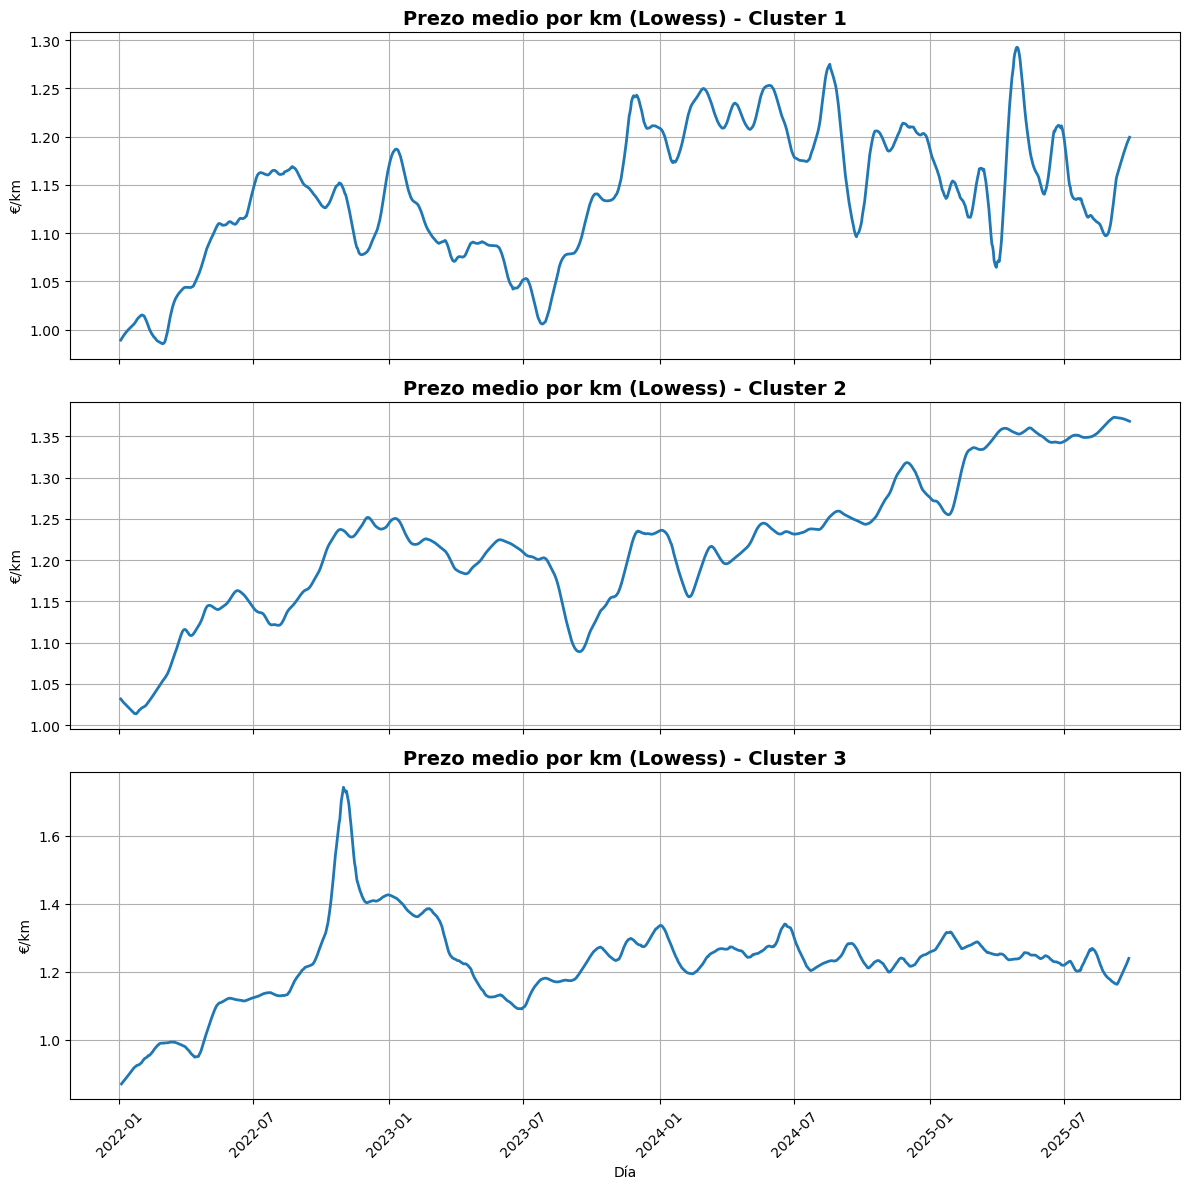

In [60]:
prezo_por_dia_cluster = (
    datos
    .groupby(['dia', 'Cluster'])['cl_price_km']
    .mean()
    .reset_index()
)

# Asegurarse de que 'dia' sea datetime
prezo_por_dia_cluster['dia'] = pd.to_datetime(prezo_por_dia_cluster['dia'])

prezo_por_dia_cluster['cl_price_km_lowess'] = np.nan

for cluster_id in prezo_por_dia_cluster['Cluster'].unique():
    cluster_data = prezo_por_dia_cluster[prezo_por_dia_cluster['Cluster'] == cluster_id]
    
    # Lowess requiere valores numéricos para el eje x, usamos ordinal de fechas
    x = cluster_data['dia'].map(pd.Timestamp.toordinal)
    y = cluster_data['cl_price_km']
    
    smoothed = lowess(y, x, frac=0.03, return_sorted=False)  # frac controla suavidad
    
    prezo_por_dia_cluster.loc[cluster_data.index, 'cl_price_km_lowess'] = smoothed


clusters = prezo_por_dia_cluster['Cluster'].unique()
fig, axes = plt.subplots(len(clusters), 1, figsize=(12, 4 * len(clusters)), sharex=True)

for i, cluster_id in enumerate(clusters):
    cluster_data = prezo_por_dia_cluster[prezo_por_dia_cluster['Cluster'] == cluster_id]
    axes[i].plot(cluster_data['dia'], cluster_data['cl_price_km_lowess'], linewidth=2)
    axes[i].set_title(f'Prezo medio por km (Lowess) - Cluster {cluster_id}', fontdict={'fontsize': 14, 'fontweight': 'bold'})
    axes[i].set_ylabel('€/km')
    axes[i].grid(True)

axes[-1].set_xlabel('Día')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Nun só gráfico:

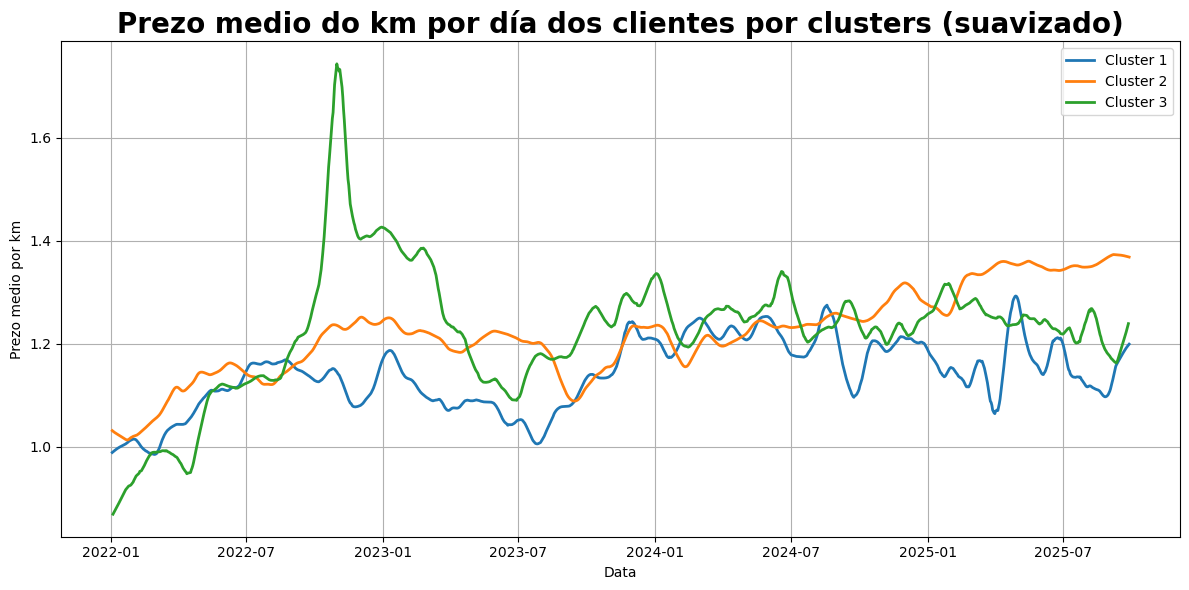

In [61]:
plt.figure(figsize=(12, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green']  # Colores distintos para cada cluster

for i, cluster_id in enumerate(prezo_por_dia_cluster['Cluster'].unique()):
    cluster_data = prezo_por_dia_cluster[prezo_por_dia_cluster['Cluster'] == cluster_id]
    
    # Eje x numérico para Lowess
    x = cluster_data['dia'].map(pd.Timestamp.toordinal)
    y = cluster_data['cl_price_km']
    
    smoothed = lowess(y, x, frac=0.03, return_sorted=False)
    
    plt.plot(cluster_data['dia'], smoothed, color=colors[i], linewidth=2, label=f'Cluster {cluster_id}')

plt.title('Prezo medio do km por día dos clientes por clusters (suavizado)', fontdict={'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Data')
plt.ylabel('Prezo medio por km')
plt.grid(True)
plt.xticks()
plt.legend()
plt.tight_layout()
plt.show()


Agora para os prezos dos proveedores (vemos se o prezo dos proveedores en función do tipo de cliente cambia ou non):

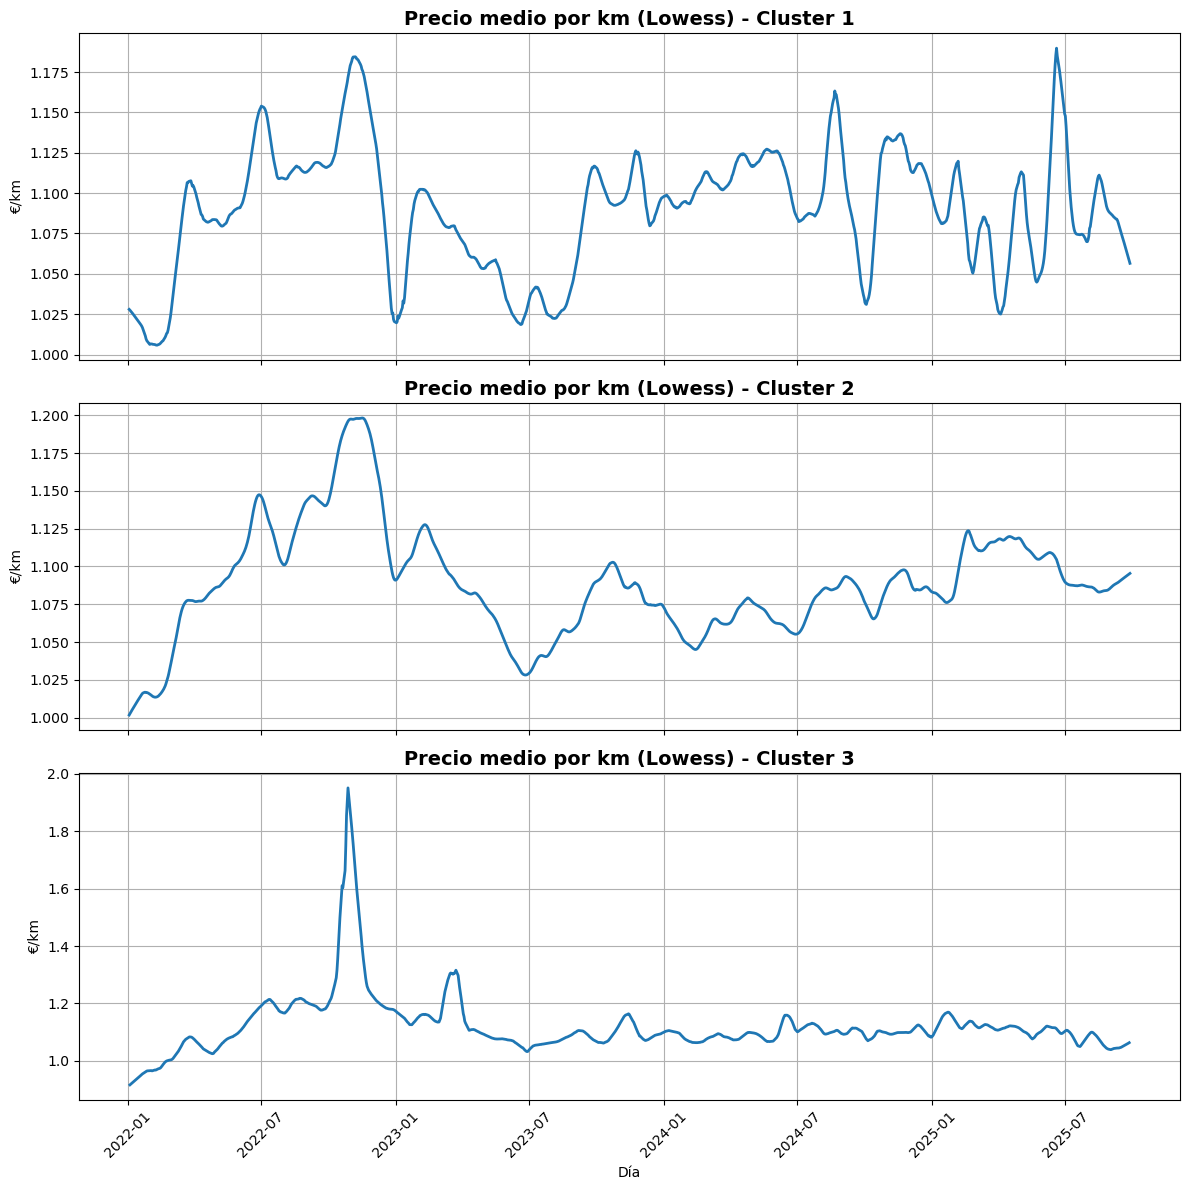

In [62]:
prezo_por_dia_cluster_pro = (
    datos
    .groupby(['dia', 'Cluster'])['pro_price_km']
    .mean()
    .reset_index()
)

# Asegurarse de que 'dia' sea datetime
prezo_por_dia_cluster_pro['dia'] = pd.to_datetime(prezo_por_dia_cluster_pro['dia'])

prezo_por_dia_cluster_pro['pro_price_km_lowess'] = np.nan

for cluster_id in prezo_por_dia_cluster_pro['Cluster'].unique():
    cluster_data = prezo_por_dia_cluster_pro[prezo_por_dia_cluster_pro['Cluster'] == cluster_id]
    
    # Lowess requiere valores numéricos para el eje x, usamos ordinal de fechas
    x = cluster_data['dia'].map(pd.Timestamp.toordinal)
    y = cluster_data['pro_price_km']
    
    smoothed = lowess(y, x, frac=0.025, return_sorted=False)  # frac controla suavidad
    
    prezo_por_dia_cluster_pro.loc[cluster_data.index, 'pro_price_km_lowess'] = smoothed


clusters = prezo_por_dia_cluster_pro['Cluster'].unique()
fig, axes = plt.subplots(len(clusters), 1, figsize=(12, 4 * len(clusters)), sharex=True)

for i, cluster_id in enumerate(clusters):
    cluster_data = prezo_por_dia_cluster_pro[prezo_por_dia_cluster_pro['Cluster'] == cluster_id]
    axes[i].plot(cluster_data['dia'], cluster_data['pro_price_km_lowess'], linewidth=2)
    axes[i].set_title(f'Precio medio por km (Lowess) - Cluster {cluster_id}', fontdict={'fontsize': 14, 'fontweight': 'bold'})
    axes[i].set_ylabel('€/km')
    axes[i].grid(True)

axes[-1].set_xlabel('Día')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



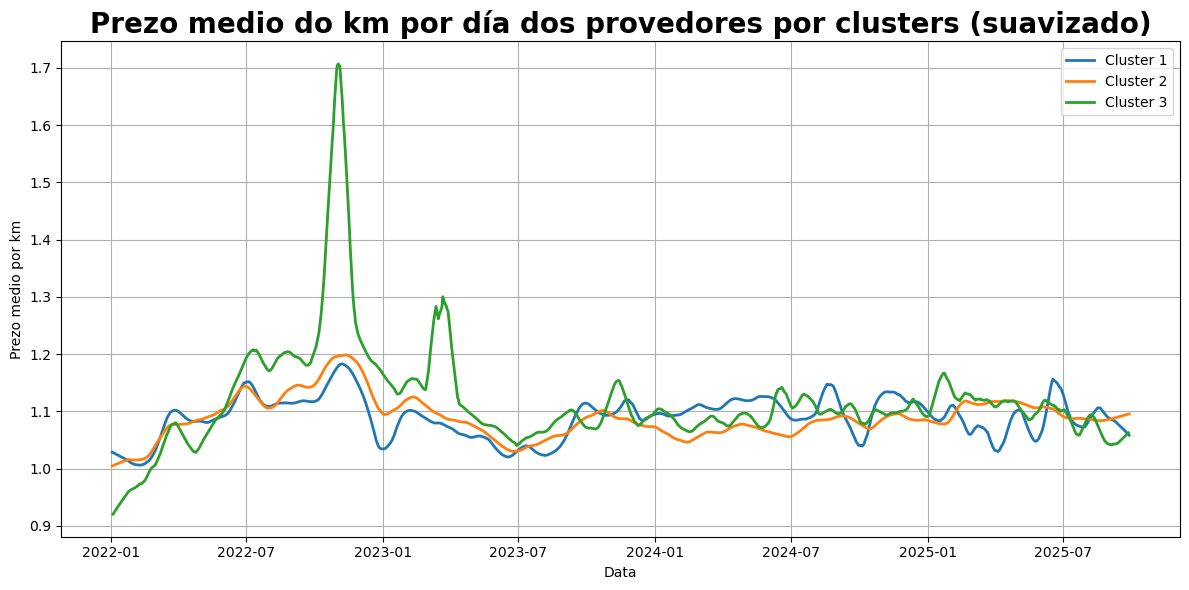

In [63]:
plt.figure(figsize=(12, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green']  # Colores distintos para cada cluster

for i, cluster_id in enumerate(prezo_por_dia_cluster_pro['Cluster'].unique()):
    cluster_data = prezo_por_dia_cluster_pro[prezo_por_dia_cluster_pro['Cluster'] == cluster_id]
    
    # Eje x numérico para Lowess
    x = cluster_data['dia'].map(pd.Timestamp.toordinal)
    y = cluster_data['pro_price_km']
    
    smoothed = lowess(y, x, frac=0.03, return_sorted=False)
    
    plt.plot(cluster_data['dia'], smoothed, color=colors[i], linewidth=2, label=f'Cluster {cluster_id}')

plt.title('Prezo medio do km por día dos provedores por clusters (suavizado)', fontdict={'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Data')
plt.ylabel('Prezo medio por km')
plt.grid(True)
plt.xticks()
plt.legend()
plt.tight_layout()
plt.show()


In [64]:
datos.head(5)

,id_trucksters,contract,lane_zipcode,client_name_complete,client_price,empty_km,loaded_km,po_price_empty,po_price_loaded,direction,...,total_km,pro_price,cl_price_km,pro_price_km,festivo,dia,semana,mes,sector,Cluster
0,R20220202-CJH,fix,BSH: ES50 - NL40,BSH ELECTRODOMESTICOS ESPAÑA SA,1670.0,32,1552,30.40,1474.40,export,...,1584,1504.8,1.054293,0.950000,0,2022-01-31,2022-01-31,2022-01-01,electrónica,1
1,R20220102-MDY,fix,BSH: ES50 - NL40,BSH ELECTRODOMESTICOS ESPAÑA SA,1670.0,0,1552,0.00,1474.40,export,...,1552,1474.4,1.076031,0.950000,0,2022-01-24,2022-01-24,2022-01-01,electrónica,1
2,R20220106-QVB,fix,BSH: ES50 - NL40,BSH ELECTRODOMESTICOS ESPAÑA SA,1670.0,411,1553,390.45,1475.35,export,...,1964,1865.8,0.850305,0.950000,0,2022-01-10,2022-01-10,2022-01-01,electrónica,1
3,R20220101-JTX,fix,BSH: ES50 - NL40,BSH ELECTRODOMESTICOS ESPAÑA SA,1670.0,428,1552,385.20,1552.00,export,...,1980,1937.2,0.843434,0.978384,0,2022-01-18,2022-01-17,2022-01-01,electrónica,1
4,R20220101-QJU,fix,CROWDFARMING: ES46 - DE67,CROWDFARMING S.L.,2067.0,10,1587,8.00,1745.70,export,...,1597,1753.7,1.294302,1.098121,0,2022-01-11,2022-01-10,2022-01-01,froita,2


Podemos incluso comparar os prezos de cliente e proveedor por cluster:

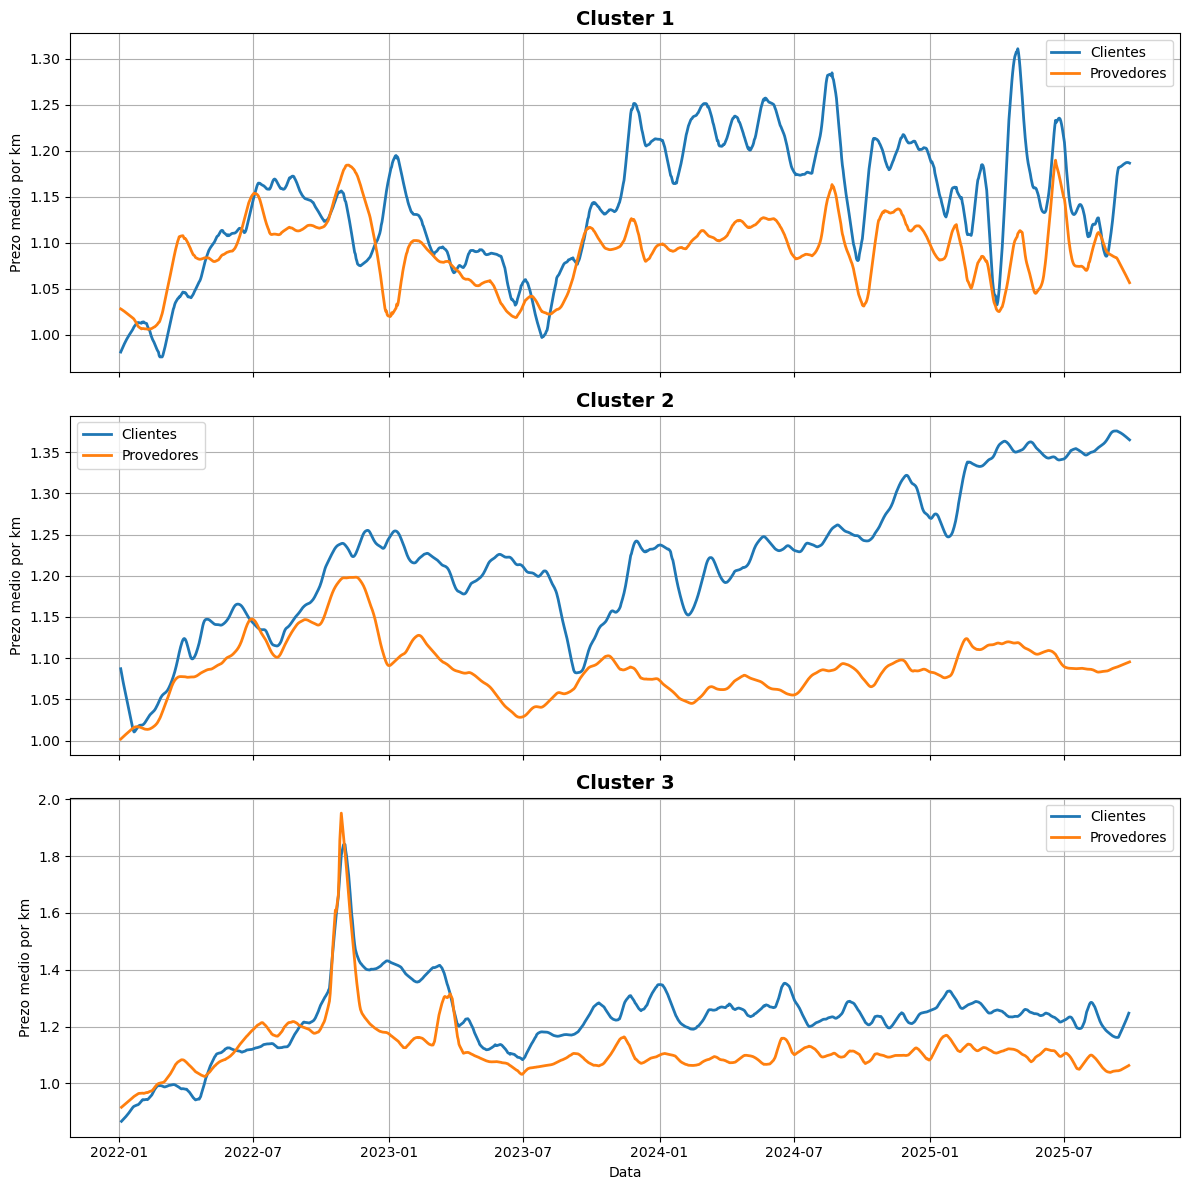

In [65]:
# Creamos un DataFrame combinando ambos precios y aplicando Lowess a cada uno por cluster
prezo_por_dia_cluster_comb = prezo_por_dia_cluster[['dia', 'Cluster', 'cl_price_km']].copy()
prezo_por_dia_cluster_comb['cl_price_km_lowess'] = np.nan
prezo_por_dia_cluster_comb['pro_price_km_lowess'] = np.nan

for cluster_id in prezo_por_dia_cluster_comb['Cluster'].unique():
    # Datos CL
    cluster_data_cl = prezo_por_dia_cluster[prezo_por_dia_cluster['Cluster'] == cluster_id]
    x = cluster_data_cl['dia'].map(pd.Timestamp.toordinal)
    y = cluster_data_cl['cl_price_km']
    prezo_por_dia_cluster_comb.loc[cluster_data_cl.index, 'cl_price_km_lowess'] = lowess(y, x, frac=0.025, return_sorted=False)
    
    # Datos PRO
    cluster_data_pro = prezo_por_dia_cluster_pro[prezo_por_dia_cluster_pro['Cluster'] == cluster_id]
    x_pro = cluster_data_pro['dia'].map(pd.Timestamp.toordinal)
    y_pro = cluster_data_pro['pro_price_km']
    prezo_por_dia_cluster_comb.loc[cluster_data_pro.index, 'pro_price_km_lowess'] = lowess(y_pro, x_pro, frac=0.025, return_sorted=False)

# Lista de clusters
clusters = prezo_por_dia_cluster_comb['Cluster'].unique()

# Figura con 3 subplots (uno por cluster)
fig, axes = plt.subplots(len(clusters), 1, figsize=(12, 4 * len(clusters)), sharex=True)

for i, cluster_id in enumerate(clusters):
    cluster_data = prezo_por_dia_cluster_comb[prezo_por_dia_cluster_comb['Cluster'] == cluster_id]
    
    axes[i].plot(cluster_data['dia'], cluster_data['cl_price_km_lowess'], label='Clientes', color='tab:blue', linewidth=2)
    axes[i].plot(cluster_data['dia'], cluster_data['pro_price_km_lowess'], label='Provedores', color='tab:orange', linewidth=2)
    
    axes[i].set_title(f'Cluster {cluster_id}', fontdict={'fontsize': 14, 'fontweight': 'bold'})
    axes[i].set_ylabel('Prezo medio por km')
    axes[i].grid(True)
    axes[i].legend()

axes[-1].set_xlabel('Data')
plt.xticks()
plt.tight_layout()
plt.show()


## Relación €/km con loaded km

Outro aspecto que nos pode resultar de interese para o noso estudo é a relación entre os prezos do cliente e proveedor por km coa distancia que percorre o camión cargado.

Comezamos vendo a relación entre estas variables para os proveedores:

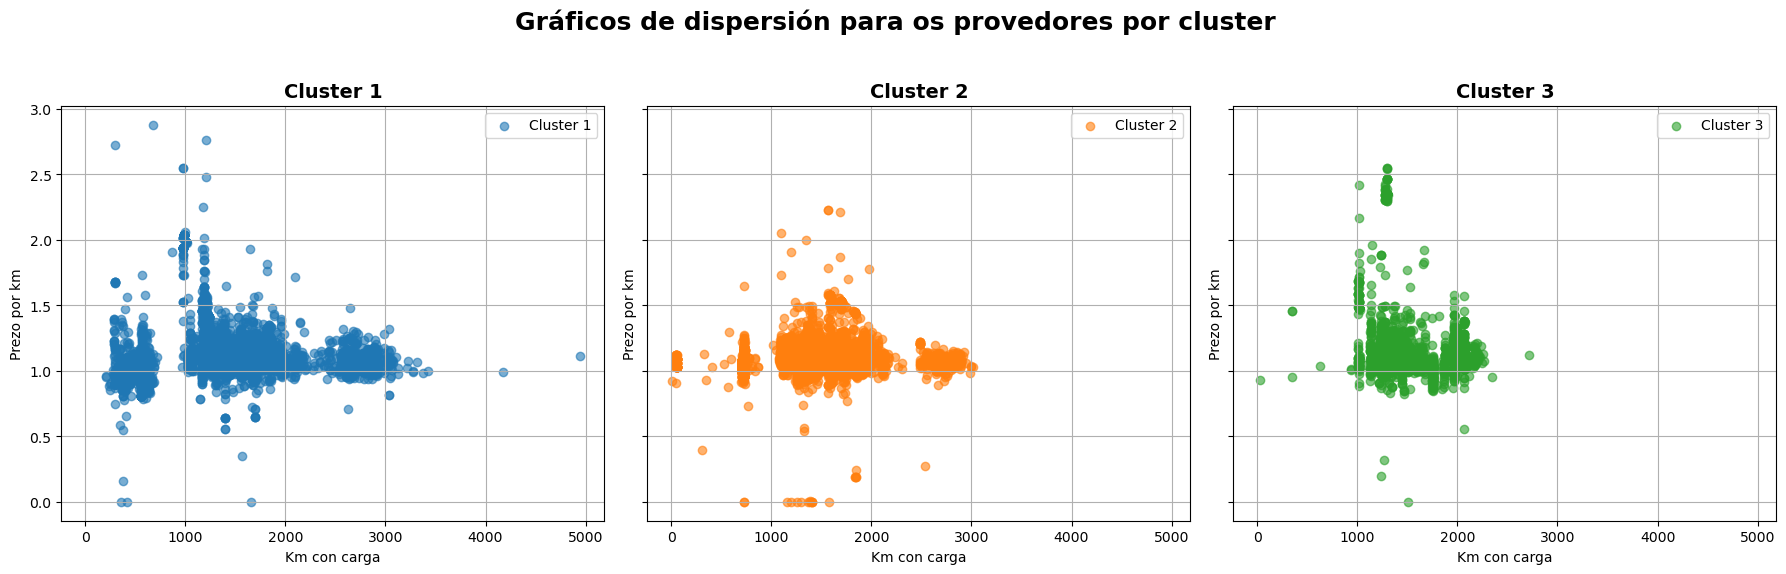

In [66]:
import matplotlib.pyplot as plt
import pandas as pd # Asegúrate de que tienes pandas para manejar 'datos'

# Suponiendo que 'datos' es tu DataFrame y ya tiene la columna 'Cluster'
# Ejemplo de DataFrame (para que el código sea ejecutable)
# datos = pd.DataFrame({
#     'loaded_km': np.random.rand(300) * 1000,
#     'pro_price_km': np.random.rand(300) * 2 + 0.5,
#     'Cluster': np.random.randint(1, 4, 300) # Clusters 1, 2, 3
# })
# print(datos['Cluster'].unique()) # Verificar IDs de clusters

# 1. Preparar las variables para la iteración
clusters = sorted(datos['Cluster'].unique()) # Asegura un orden consistente

# Definir los colores para cada cluster para que sean consistentes
colors = {
    clusters[0]: 'tab:blue',
    clusters[1]: 'tab:orange',
    clusters[2]: 'tab:green'
    # Ajusta los colores o añade más si tienes más clusters
}

# 2. CREAR LA FIGURA Y LOS EJES (3 subplots en una fila)
# nrows=1, ncols=3. Esto crea una figura con 3 subplots alineados horizontalmente.
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 6), # Ajusta el tamaño total para que quepan
    sharex=True,     # Opcional: Compartir el mismo eje X entre todos los subplots
    sharey=True      # Opcional: Compartir el mismo eje Y entre todos los subplots
)

# 3. Iterar sobre cada cluster y el eje correspondiente
for i, cluster_id in enumerate(clusters):
    # a. Seleccionar el eje actual
    ax = axes[i]

    # b. FILTRADO DE DATOS: Obtener solo los datos del cluster actual
    cluster_data = datos[datos['Cluster'] == cluster_id]

    # c. GRAFICAR: Dibujar el scatter plot SÓLO para el cluster actual en el eje 'ax'
    ax.scatter(
        cluster_data['loaded_km'],
        cluster_data['pro_price_km'],
        alpha=0.6,
        color=colors.get(cluster_id, 'black'), # Obtener color por ID de cluster
        label=f'Cluster {cluster_id}'
    )

    # d. PERSONALIZAR: Etiquetas y Título específicos para el gráfico actual
    ax.set_title(f'Cluster {cluster_id}',
                 fontdict={'fontsize': 14, 'fontweight': 'bold'})
    ax.set_xlabel('Km con carga')
    ax.set_ylabel('Prezo por km') # Cada subplot tendrá su etiqueta Y
    ax.grid(True)
    ax.legend(loc='upper right')

# 4. TÍTULO GENERAL DE LA FIGURA
fig.suptitle('Gráficos de dispersión para os provedores por cluster',
            fontsize=18, fontweight='bold')

# 5. Ajustar el espaciado entre subplots
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta el espacio para evitar superposiciones

# 6. Mostrar la figura final
plt.show()
# Opcional: plt.savefig('dispersion_clusters_subplots.png')

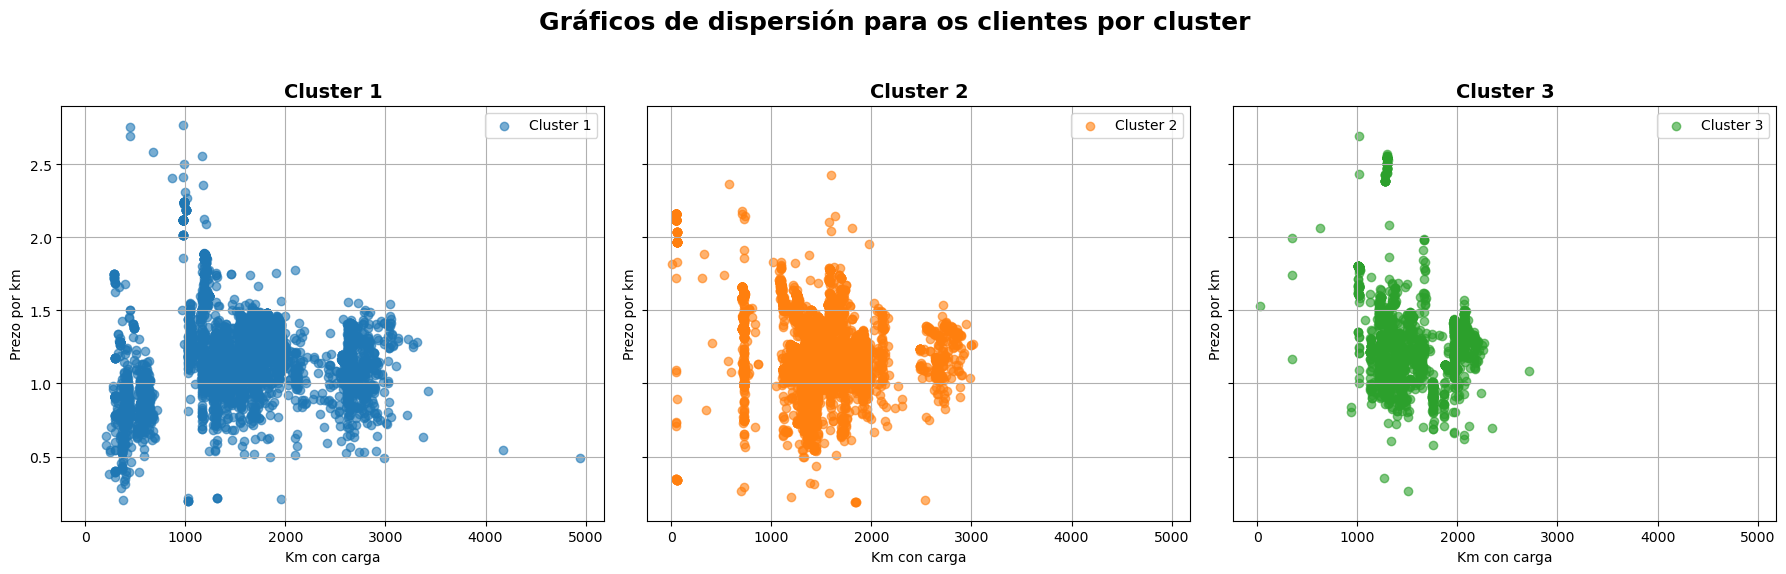

In [67]:
import matplotlib.pyplot as plt
import pandas as pd # Asegúrate de que tienes pandas para manejar 'datos'

# Suponiendo que 'datos' es tu DataFrame y ya tiene la columna 'Cluster'
# Ejemplo de DataFrame (para que el código sea ejecutable)
# datos = pd.DataFrame({
#     'loaded_km': np.random.rand(300) * 1000,
#     'pro_price_km': np.random.rand(300) * 2 + 0.5,
#     'Cluster': np.random.randint(1, 4, 300) # Clusters 1, 2, 3
# })
# print(datos['Cluster'].unique()) # Verificar IDs de clusters

# 1. Preparar las variables para la iteración
clusters = sorted(datos['Cluster'].unique()) # Asegura un orden consistente

# Definir los colores para cada cluster para que sean consistentes
colors = {
    clusters[0]: 'tab:blue',
    clusters[1]: 'tab:orange',
    clusters[2]: 'tab:green'
    # Ajusta los colores o añade más si tienes más clusters
}

# 2. CREAR LA FIGURA Y LOS EJES (3 subplots en una fila)
# nrows=1, ncols=3. Esto crea una figura con 3 subplots alineados horizontalmente.
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 6), # Ajusta el tamaño total para que quepan
    sharex=True,     # Opcional: Compartir el mismo eje X entre todos los subplots
    sharey=True      # Opcional: Compartir el mismo eje Y entre todos los subplots
)

# 3. Iterar sobre cada cluster y el eje correspondiente
for i, cluster_id in enumerate(clusters):
    # a. Seleccionar el eje actual
    ax = axes[i]

    # b. FILTRADO DE DATOS: Obtener solo los datos del cluster actual
    cluster_data = datos[datos['Cluster'] == cluster_id]

    # c. GRAFICAR: Dibujar el scatter plot SÓLO para el cluster actual en el eje 'ax'
    ax.scatter(
        cluster_data['loaded_km'],
        cluster_data['cl_price_km'],
        alpha=0.6,
        color=colors.get(cluster_id, 'black'), # Obtener color por ID de cluster
        label=f'Cluster {cluster_id}'
    )

    # d. PERSONALIZAR: Etiquetas y Título específicos para el gráfico actual
    ax.set_title(f'Cluster {cluster_id}',
                 fontdict={'fontsize': 14, 'fontweight': 'bold'})
    ax.set_xlabel('Km con carga')
    ax.set_ylabel('Prezo por km') # Cada subplot tendrá su etiqueta Y
    ax.grid(True)
    ax.legend(loc='upper right')

# 4. TÍTULO GENERAL DE LA FIGURA
fig.suptitle('Gráficos de dispersión para os clientes por cluster',
            fontsize=18, fontweight='bold')

# 5. Ajustar el espaciado entre subplots
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta el espacio para evitar superposiciones

# 6. Mostrar la figura final
plt.show()
# Opcional: plt.savefig('dispersion_clusters_subplots.png')

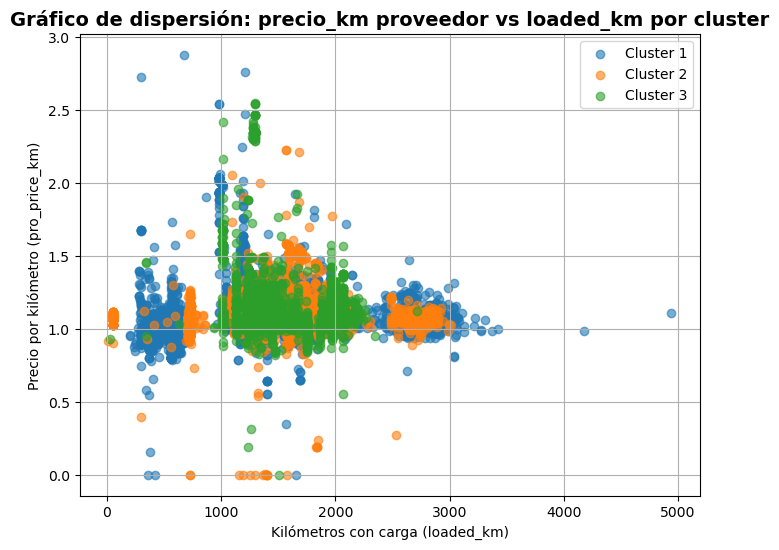

In [68]:
plt.figure(figsize=(8, 6))

clusters = datos['Cluster'].unique()
colors = ['tab:blue', 'tab:orange', 'tab:green']  # Ajusta la lista si hay más clusters

for i, cluster_id in enumerate(clusters):
    cluster_data = datos[datos['Cluster'] == cluster_id]
    plt.scatter(
        cluster_data['loaded_km'],
        cluster_data['pro_price_km'],
        alpha=0.6,
        color=colors[i],
        label=f'Cluster {cluster_id}'
    )

plt.xlabel('Kilómetros con carga (loaded_km)')
plt.ylabel('Precio por kilómetro (pro_price_km)')
plt.title('Gráfico de dispersión: precio_km proveedor vs loaded_km por cluster', 
          fontdict={'fontsize': 14, 'fontweight': 'bold'})
plt.grid(True)
plt.legend()  # Muestra la leyenda con los clusters
plt.show()


Repetimos o proceso cos clientes:

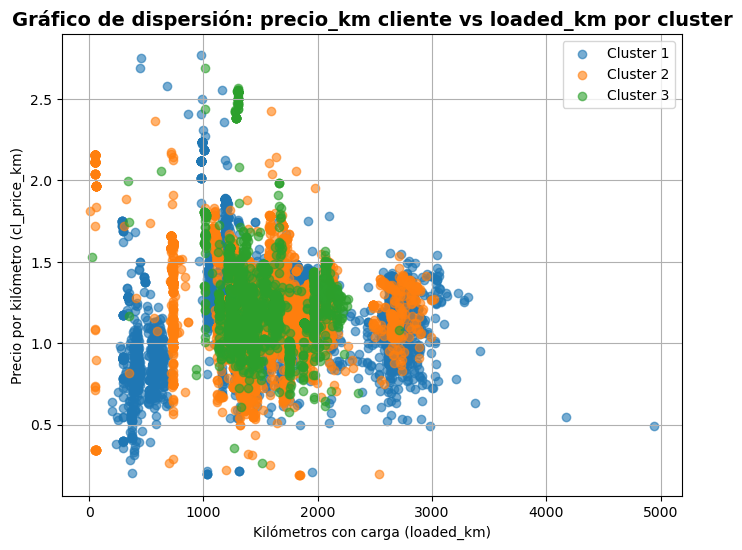

In [69]:
plt.figure(figsize=(8, 6))

clusters = datos['Cluster'].unique()
colors = ['tab:blue', 'tab:orange', 'tab:green']  # Ajusta la lista si hay más clusters

for i, cluster_id in enumerate(clusters):
    cluster_data = datos[datos['Cluster'] == cluster_id]
    plt.scatter(
        cluster_data['loaded_km'],
        cluster_data['cl_price_km'],
        alpha=0.6,
        color=colors[i],
        label=f'Cluster {cluster_id}'
    )

plt.xlabel('Kilómetros con carga (loaded_km)')
plt.ylabel('Precio por kilómetro (cl_price_km)')
plt.title('Gráfico de dispersión: precio_km cliente vs loaded_km por cluster', 
          fontdict={'fontsize': 14, 'fontweight': 'bold'})
plt.grid(True)
plt.legend()  # Muestra la leyenda con los clusters
plt.show()


Chama a atención como, en xeral, os prezos son superiores, en especial para distancias superiores a 1000 km onde temos moitas observacións superiores a 1.5€, así como para os envíos máis longos (superiores a 2000 km) onde a maioría dos prezos se sitúan entre 1€ e 1.5€, apenas superando os 1.25€ para os proveedores. Porén, é salientable ver que para envíos de pouca distancia se teñen prezos inferiores aos dos proveedores, tendo datos por baixo dos 0.5€.

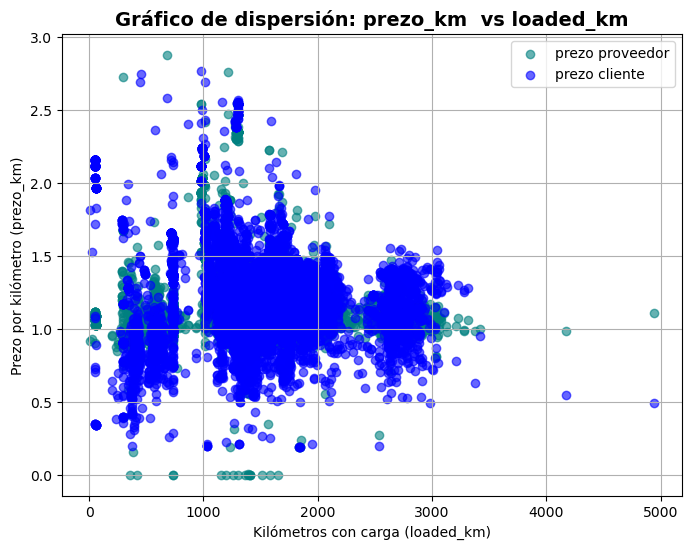

In [70]:
plt.figure(figsize=(8, 6))

plt.scatter(datos['loaded_km'], datos['pro_price_km'], alpha=0.6, color='teal', label = 'prezo proveedor')
plt.scatter(datos['loaded_km'], datos['cl_price_km'], alpha=0.6, color ='blue', label = 'prezo cliente')

plt.xlabel('Kilómetros con carga (loaded_km)')
plt.ylabel('Prezo por kilómetro (prezo_km)')
plt.title('Gráfico de dispersión: prezo_km  vs loaded_km', fontdict={'fontsize': 14, 'fontweight': 'bold'})
plt.grid(True)
plt.legend()

plt.show()

## Evolución temporal do volume de pedidos

Comezamos estudando a evolución do volume de pedidos mensualmente.
Consideramos os datos filtrados previamente (datos2) sen aqueles envíos considerados como moi caros (superiores a 2.5€) e moi baratos (inferiores a 0.75€).

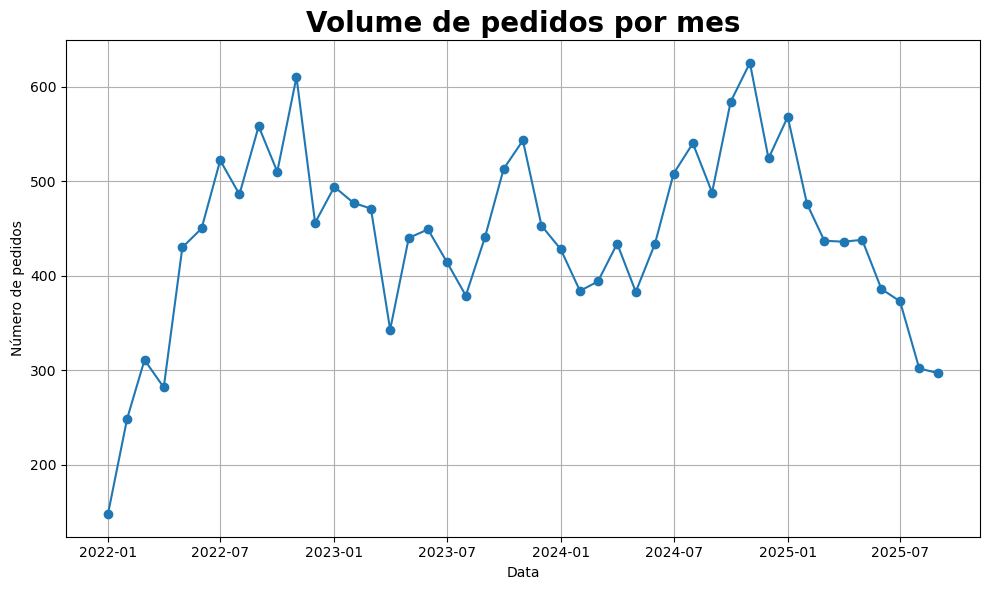

In [71]:
pedidos_por_mes = datos.groupby('mes').size().reset_index(name='n_pedidos')

plt.figure(figsize=(10, 6))
plt.plot(pedidos_por_mes['mes'], pedidos_por_mes['n_pedidos'], marker='o')
plt.title('Volume de pedidos por mes', fontdict={'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Data')
plt.ylabel('Número de pedidos')
plt.grid(True)
plt.xticks()
plt.tight_layout()
plt.show()

Podemos observar unha certa estacionalidade. En xeral, tras os meses de verán prodúcese un aumento do volume de envíos, que chega ao seu máximo no mes de novembro. Vemos neste gráfico o impacto que ten o black friday.

Podemos repetir o gráfico semanalmente, onde se apreciarán mellor as características da nosa serie de tempo.

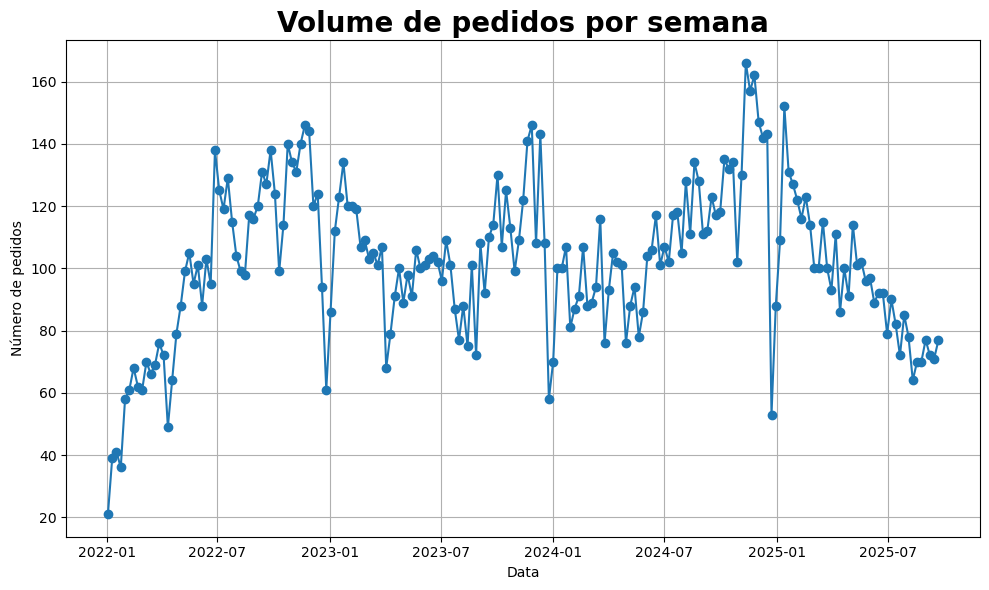

In [72]:
pedidos_por_semana = datos.groupby('semana').size().reset_index(name='n_pedidos')

plt.figure(figsize=(10, 6))
plt.plot(pedidos_por_semana['semana'], pedidos_por_semana['n_pedidos'], marker='o')
plt.title('Volume de pedidos por semana', fontdict={'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Data')
plt.ylabel('Número de pedidos')
plt.grid(True)
plt.xticks()
plt.tight_layout()
plt.show()

Aquí obsérvase todavía mellor o aumento no volume de pedidos nas últimas semanas do mes de novembro e chama a atención a gran caída que se produce no mes de decembro, chegando a mínimos anuais nos anos 2023 e 2024. Outro aspecto a sinalar é a tendencia que se ve no ano 2022 onde a comezos de ano o volume é especialmente baixo e crece salientablemenete nos primeiros meses do ano, manténdose a partir de entón un comportamento máis estacional nos anos vindeiros.

/var/folders/72/92sdss296tdg9zgnwr3xcg180000gn/T/ipykernel_7234/3091675743.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([nombres_meses[int(x.month)-1] for x in mdates.num2date(plt.gca().get_xticks())])


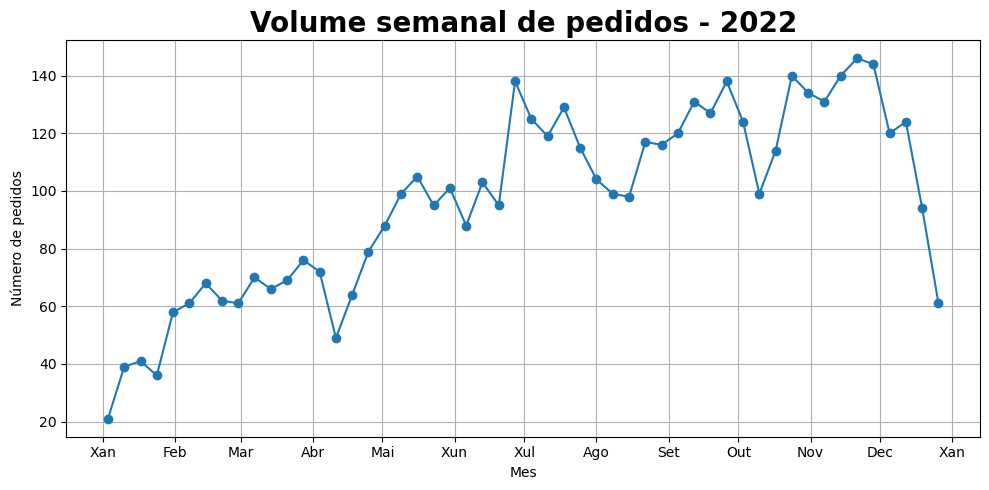

/var/folders/72/92sdss296tdg9zgnwr3xcg180000gn/T/ipykernel_7234/3091675743.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([nombres_meses[int(x.month)-1] for x in mdates.num2date(plt.gca().get_xticks())])


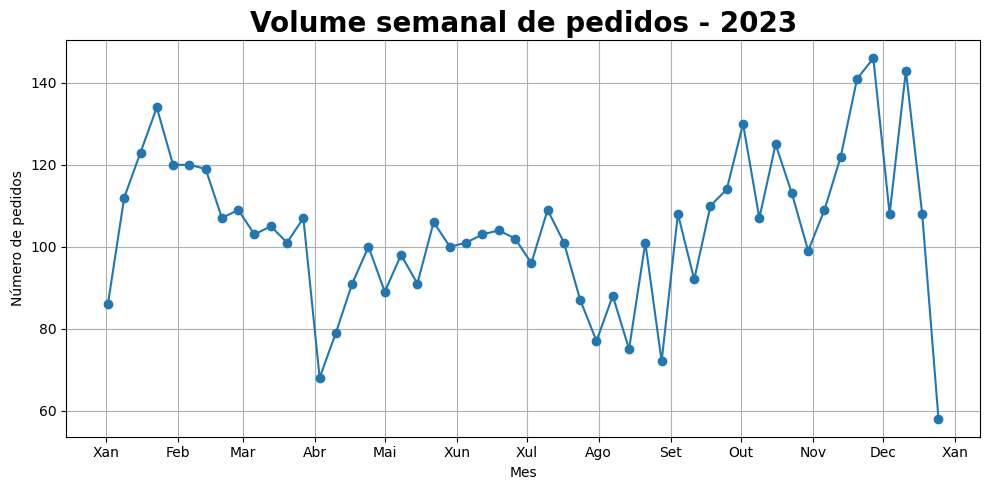

/var/folders/72/92sdss296tdg9zgnwr3xcg180000gn/T/ipykernel_7234/3091675743.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([nombres_meses[int(x.month)-1] for x in mdates.num2date(plt.gca().get_xticks())])


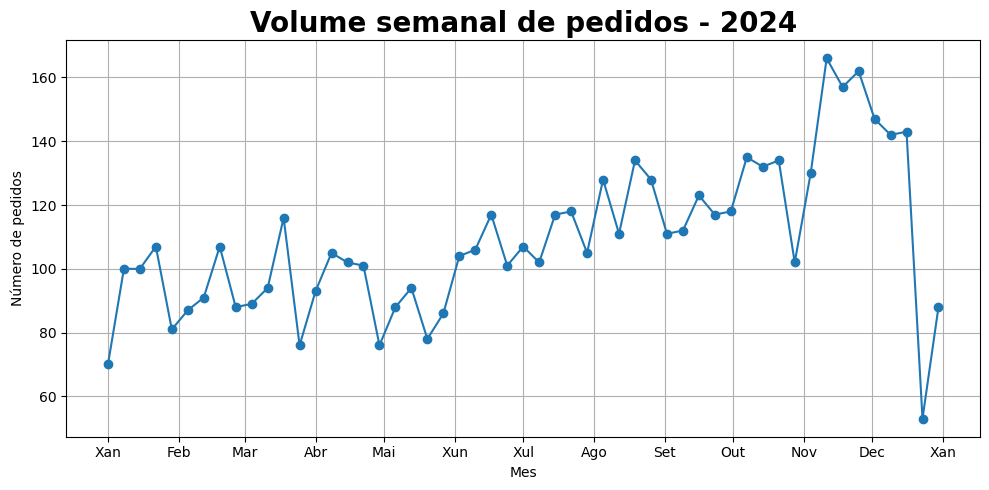

/var/folders/72/92sdss296tdg9zgnwr3xcg180000gn/T/ipykernel_7234/3091675743.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([nombres_meses[int(x.month)-1] for x in mdates.num2date(plt.gca().get_xticks())])


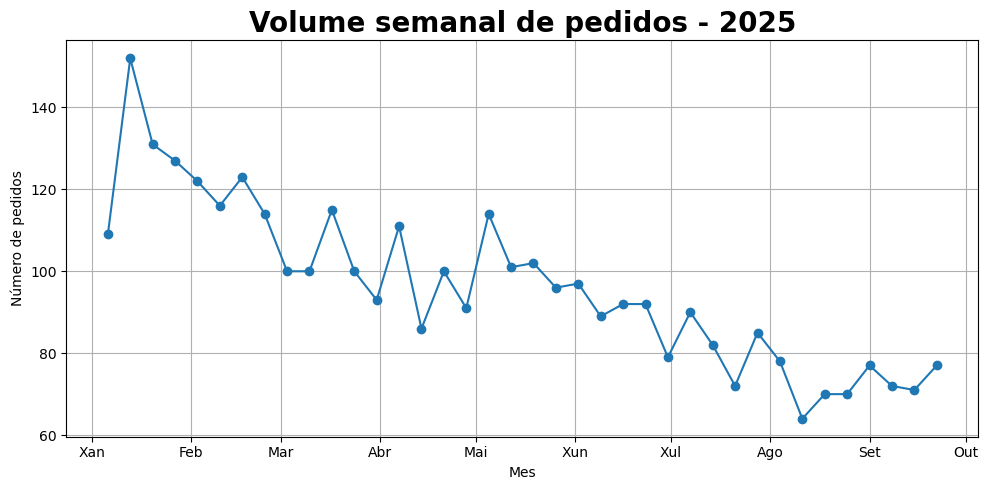

In [73]:
import matplotlib.dates as mdates

# Asegúrate de que 'semana' sea datetime
pedidos_por_semana['semana'] = pd.to_datetime(pedidos_por_semana['semana'])
pedidos_por_semana['ano'] = pedidos_por_semana['semana'].dt.year

# Crear un gráfico por año
for ano, grupo in pedidos_por_semana.groupby('ano'):
    plt.figure(figsize=(10,5))
    plt.plot(grupo['semana'], grupo['n_pedidos'], marker='o')
    
    plt.title(f'Volume semanal de pedidos - {ano}', fontdict={'fontsize': 20, 'fontweight': 'bold'})
    plt.xlabel('Mes')
    plt.ylabel('Número de pedidos')
    
    # Eje X con meses
    # Define tus nombres a mano (en el idioma que quieras)
    nombres_meses = ['Xan', 'Feb', 'Mar', 'Abr', 'Mai', 'Xun', 
                     'Xul', 'Ago', 'Set', 'Out', 'Nov', 'Dec']

    # Configura el localizador para que ponga un tick en cada mes
    locator = mdates.MonthLocator()
    plt.gca().xaxis.set_major_locator(locator)
    
    # IMPORTANTE: Esto sustituye al DateFormatter('%b')
    # Le decimos que use nuestra lista manual
    # Nota: indexamos locator.tick_values para alinear con los meses correctos
    plt.gca().set_xticklabels([nombres_meses[int(x.month)-1] for x in mdates.num2date(plt.gca().get_xticks())])
    #plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### Volume semanal por cluster

Repetimos o estudo do volume de pedidos para cada tipo de cliente por separado:

Comezamos polo estudo mensual.

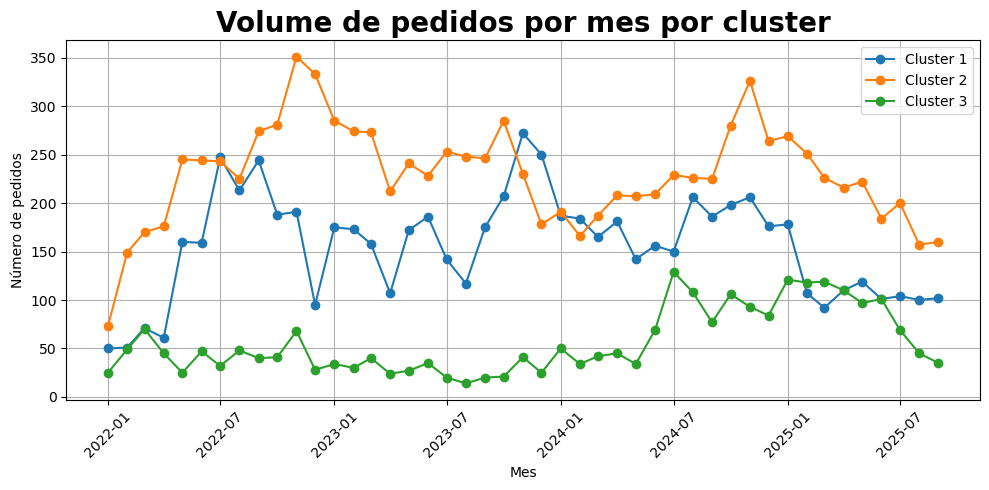

In [99]:
# Agrupamos por mes y cluster, contando número de pedidos
pedidos_por_mes_cluster = (
    datos
    .groupby(['mes', 'Cluster'])
    .size()
    .reset_index(name='n_pedidos')
)

plt.figure(figsize=(10, 5))
colors = ['tab:blue', 'tab:orange', 'tab:green']  # Uno por cluster

for i, cluster_id in enumerate(pedidos_por_mes_cluster['Cluster'].unique()):
    cluster_data = pedidos_por_mes_cluster[pedidos_por_mes_cluster['Cluster'] == cluster_id]
    plt.plot(
        cluster_data['mes'],
        cluster_data['n_pedidos'],
        marker='o',
        linestyle='-',
        color=colors[i],
        label=f'Cluster {cluster_id}'
    )

plt.title('Volume de pedidos por mes por cluster', fontdict={'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Mes')
plt.ylabel('Número de pedidos')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


Agora por semana:

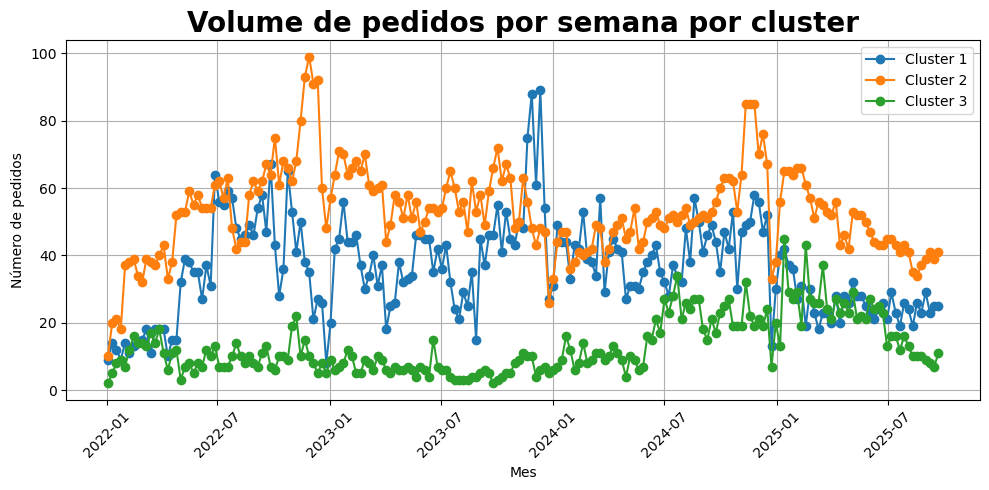

In [98]:
# Agrupamos por semana y cluster, contando número de pedidos
pedidos_por_semana_cluster = (
    datos
    .groupby(['semana', 'Cluster'])
    .size()
    .reset_index(name='n_pedidos')
)

plt.figure(figsize=(10, 5))
colors = ['tab:blue', 'tab:orange', 'tab:green']  # Uno por cluster

for i, cluster_id in enumerate(pedidos_por_semana_cluster['Cluster'].unique()):
    cluster_data = pedidos_por_semana_cluster[pedidos_por_semana_cluster['Cluster'] == cluster_id]
    plt.plot(
        cluster_data['semana'],
        cluster_data['n_pedidos'],
        marker='o',
        linestyle='-',
        color=colors[i],
        label=f'Cluster {cluster_id}'
    )

plt.title('Volume de pedidos por semana por cluster', fontdict={'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Mes')
plt.ylabel('Número de pedidos')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


Por ano e cluster:

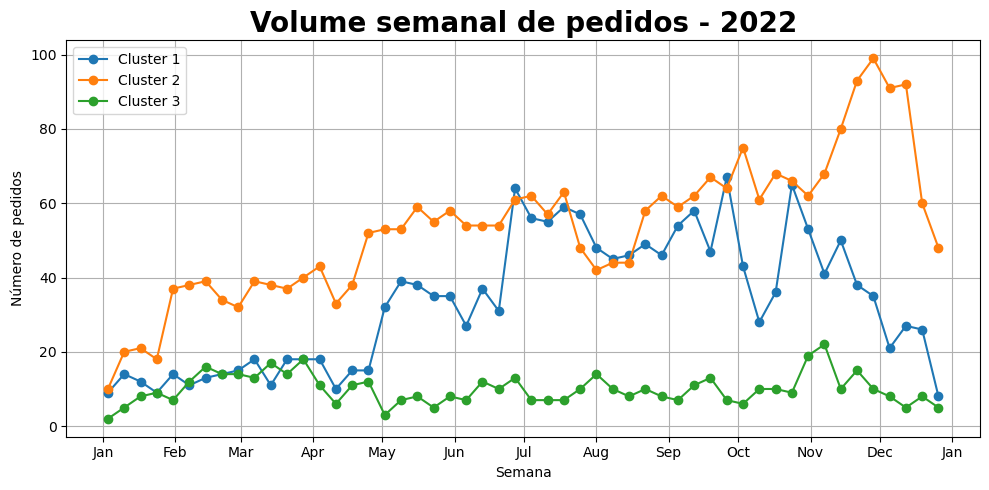

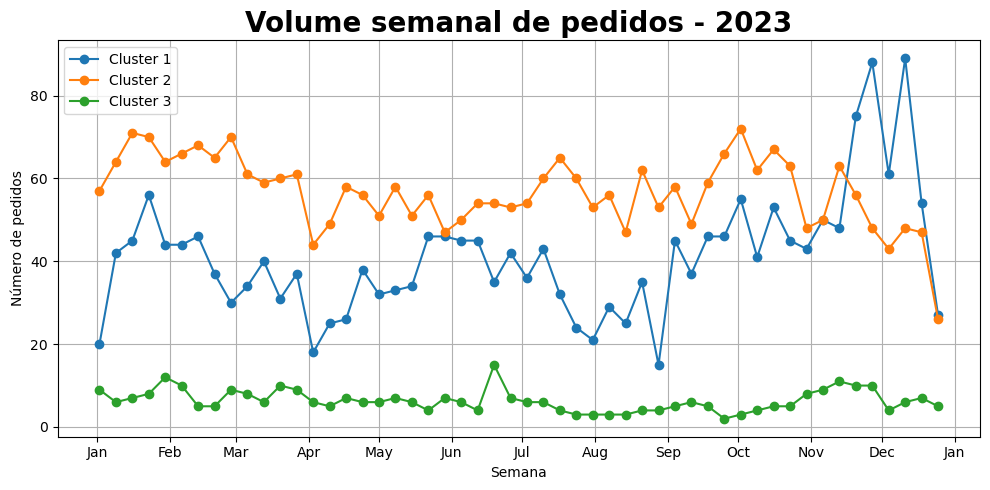

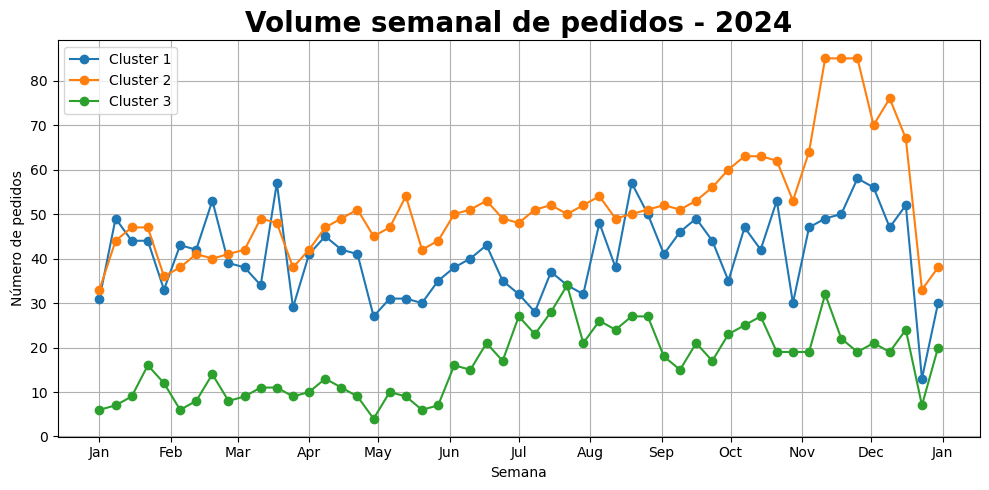

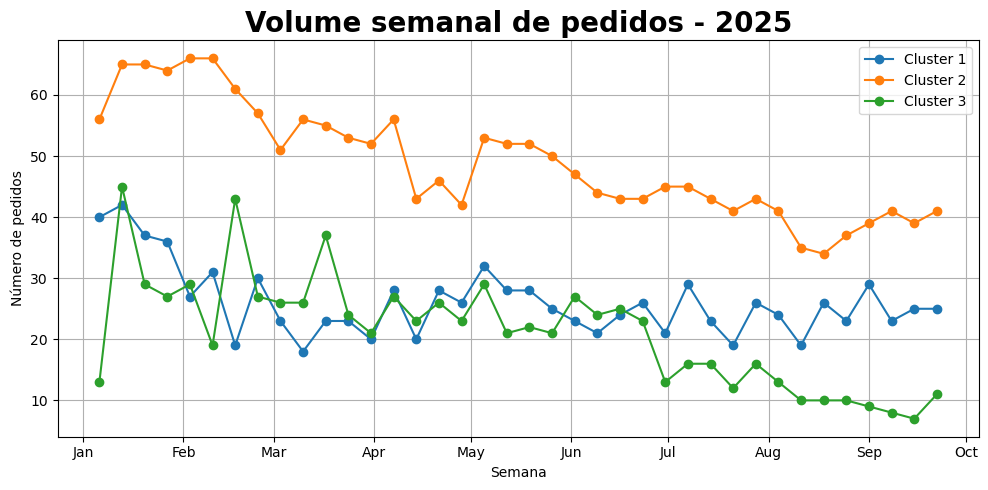

In [100]:
# Asegúrate de que 'semana' sea datetime
pedidos_por_semana_cluster['semana'] = pd.to_datetime(pedidos_por_semana_cluster['semana'])
pedidos_por_semana_cluster['ano'] = pedidos_por_semana_cluster['semana'].dt.year

colors = ['tab:blue', 'tab:orange', 'tab:green']  # Para los 3 clusters

# Crear un gráfico por año
for ano, grupo_ano in pedidos_por_semana_cluster.groupby('ano'):
    plt.figure(figsize=(10,5))
    
    for i, cluster_id in enumerate(grupo_ano['Cluster'].unique()):
        cluster_data = grupo_ano[grupo_ano['Cluster'] == cluster_id]
        plt.plot(
            cluster_data['semana'],
            cluster_data['n_pedidos'],
            marker='o',
            linestyle='-',
            color=colors[i],
            label=f'Cluster {cluster_id}'
        )
    
    plt.title(f'Volume semanal de pedidos - {ano}', fontdict={'fontsize': 20, 'fontweight': 'bold'})
    plt.xlabel('Semana')
    plt.ylabel('Número de pedidos')
    
    # Eje X con meses
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


## Efecto dos atípicos **REVISAR**

Como acabamos de ver nos apartados anteriores (gráficas do pre), temos unha gran cantidade de outliers. Podemos seguir o criterio do rango intercuartílico (graficamente os que caen fóra dos "bigotes" no boxplot) e como variable para este criterio imos empregar **pro_price_km** (parecía o boxplot con peor comportamento).

In [76]:
# Calculamos o z-score modificado (empregado para distribucións asimétricas)
"""
Q2 = np.median(datos['pro_price_km'])
MAD = np.median(np.abs(datos['pro_price_km'] - Q2))
datos['z_score_mod'] = 0.6745*(datos['pro_price_km'] - Q2)/MAD

#Q1 = datos['pro_price_km'].quantile(0.25)
#Q3 = datos['pro_price_km'].quantile(0.75)
#IQR = Q3 - Q1

#print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")

#lower_bound = Q1 - 1.5 * IQR
#upper_bound = Q3 + 1.5 * IQR

#print(f"Límite inferior: {lower_bound}, Límite superior: {upper_bound}")

umb = 4.5 # modificar valor en función de si estamos a quitar moitos puntos por ter colas moi pesadas

datos["outlier_precio_km"] = np.abs(datos['z_score_mod']) > umb
#(datos['pro_price_km'] < lower_bound) | (datos['pro_price_km'] > upper_bound)

datos_sin_out = datos[datos["outlier_precio_km"] == False].copy()

datos_sin_out.shape
"""


'\nQ2 = np.median(datos[\'pro_price_km\'])\nMAD = np.median(np.abs(datos[\'pro_price_km\'] - Q2))\ndatos[\'z_score_mod\'] = 0.6745*(datos[\'pro_price_km\'] - Q2)/MAD\n\n#Q1 = datos[\'pro_price_km\'].quantile(0.25)\n#Q3 = datos[\'pro_price_km\'].quantile(0.75)\n#IQR = Q3 - Q1\n\n#print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")\n\n#lower_bound = Q1 - 1.5 * IQR\n#upper_bound = Q3 + 1.5 * IQR\n\n#print(f"Límite inferior: {lower_bound}, Límite superior: {upper_bound}")\n\numb = 4.5 # modificar valor en función de si estamos a quitar moitos puntos por ter colas moi pesadas\n\ndatos["outlier_precio_km"] = np.abs(datos[\'z_score_mod\']) > umb\n#(datos[\'pro_price_km\'] < lower_bound) | (datos[\'pro_price_km\'] > upper_bound)\n\ndatos_sin_out = datos[datos["outlier_precio_km"] == False].copy()\n\ndatos_sin_out.shape\n'

Estamos eliminando case un 3% das nosas observacións (demasiadas?).

Podemos ver graficamente o histograma do estatístico z_score (en teoría si vemos unha cola longa pero continua non serían atípicos en sí)

O que podemos facer (de análise multivariante) é calcular a distancia de Mahalanobis (versión robusta) dos datos bivariantes e ver aqueles que exceden certo cuantil da distribución teórica que segue o estatístico (unha chi-2 neste caso).

In [83]:
"""
from sklearn.covariance import MinCovDet
from scipy.stats import chi2

X = datos[['pro_price_km', 'cl_price_km']].values
mcd = MinCovDet().fit(X)
D2 = mcd.mahalanobis(X)
threshold = chi2.ppf(0.975, df=2)
outliers = D2 > threshold


# Supongamos que tienes un DataFrame con tus dos variables originales:
# df = pd.read_csv("tus_datos.csv")
# Seleccionamos las columnas de interés:
X = datos[['cl_price_km', 'pro_price_km']].to_numpy()

# Ajustar el modelo MCD robusto
mcd = MinCovDet().fit(X)

# Extraer estimaciones robustas
mu_robust = mcd.location_
cov_robust = mcd.covariance_

# Calcular las distancias de Mahalanobis robustas
def mahalanobis_squared(X, mean, cov):
    diff = X - mean
    cov_inv = np.linalg.inv(cov)
    return np.sum(diff @ cov_inv * diff, axis=1)

D2_robust = mahalanobis_squared(X, mu_robust, cov_robust)

# Umbral chi-cuadrado al 97.5% para p = número de variables
p = X.shape[1]
alpha = 0.995
threshold = chi2.ppf(alpha, df=p)

# Identificar outliers
outliers = D2_robust > threshold
datos['Mahalanobis_robusta'] = D2_robust
datos['es_outlier'] = outliers

# Resultados
print(f"Número de outliers detectados: {outliers.sum()} ({100*outliers.mean():.2f}%)")
print(f"Umbral Chi2({p}) a {alpha*100:.1f}%: {threshold:.3f}")
"""

'\nfrom sklearn.covariance import MinCovDet\nfrom scipy.stats import chi2\n\nX = datos[[\'pro_price_km\', \'cl_price_km\']].values\nmcd = MinCovDet().fit(X)\nD2 = mcd.mahalanobis(X)\nthreshold = chi2.ppf(0.975, df=2)\noutliers = D2 > threshold\n\n\n# Supongamos que tienes un DataFrame con tus dos variables originales:\n# df = pd.read_csv("tus_datos.csv")\n# Seleccionamos las columnas de interés:\nX = datos[[\'cl_price_km\', \'pro_price_km\']].to_numpy()\n\n# Ajustar el modelo MCD robusto\nmcd = MinCovDet().fit(X)\n\n# Extraer estimaciones robustas\nmu_robust = mcd.location_\ncov_robust = mcd.covariance_\n\n# Calcular las distancias de Mahalanobis robustas\ndef mahalanobis_squared(X, mean, cov):\n    diff = X - mean\n    cov_inv = np.linalg.inv(cov)\n    return np.sum(diff @ cov_inv * diff, axis=1)\n\nD2_robust = mahalanobis_squared(X, mu_robust, cov_robust)\n\n# Umbral chi-cuadrado al 97.5% para p = número de variables\np = X.shape[1]\nalpha = 0.995\nthreshold = chi2.ppf(alpha, df=p)\n

In [84]:
#np.sum(outliers)/datos.shape[0]*100

Como criterios de detección de outliers, nunha primeira instancia poderiamos pensar en empregar o criterio baseado no rango intercuartílico, pero ao non ter normalidade nos nosos datos este método non é adecuado. Para ter en conta a asimetría presente nos datos así como as colas pesadas, poderiamos aplicar o criterio do z-score modificado. Porén, con esta metodoloxía teriamos que detectar outliers por separado para cada variable, o cal provoca que marquemos como atípicos demasiados datos (3% por variable). Tras isto, poderiamos pensar en aplicar criterios de detección de outliers multivariantes, aplicando criterios baseados en medidas de dispersión como a distancia de Mahalanobis, mais este criterio volve a detectar demasiados atípicos (16%). Daquela, a seguinte metodoloxía a aplicar serían criterios non paramétricos. Un destes criterios sería o Isolation Forest, unha metodoloxía similar ás árbores de decisión que detecta outliers dividindo os datos en nodos segundo certos criterios. 

In [77]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.0235, random_state=42)
outliers = iso.fit_predict(datos[['pro_price_km', 'cl_price_km']].values) == -1

In [78]:
np.sum(outliers)/datos.shape[0]*100

np.float64(2.3302632241179726)

Detectamos daquela un 2.33% de atípicos, que non son demasiados. 

In [79]:
datos['is_outlier'] = outliers
datos_sin_out = datos[datos["is_outlier"] == False].copy()
datos_sin_out.shape


(19406, 26)

Quedamos daquela con 19406 observacións. Fagamos de novo unha análise descritiva das variables como fixemos anteriormente.

In [80]:
datos_sin_out.describe()

,client_price,empty_km,loaded_km,po_price_empty,po_price_loaded,route_start_date,total_km,pro_price,cl_price_km,pro_price_km,festivo,semana,mes,Cluster
count,19406.000000,19406.000000,19406.000000,19406.000000,19406.000000,19406,19406.000000,19406.000000,19406.000000,19406.000000,19406.000000,19406,19406,19406.000000
mean,1937.091174,149.501597,1498.916778,139.517376,1662.298544,2023-11-24 05:03:35.977171968,1648.418376,1801.815920,1.194708,1.093231,0.037875,2023-11-21 12:55:52.530145536,2023-11-08 20:23:41.745851904,1.773524
min,110.000000,0.000000,9.000000,0.000000,0.010000,2022-01-03 06:00:00,51.000000,0.010000,0.491187,0.000009,0.000000,2022-01-03 00:00:00,2022-01-01 00:00:00,1.000000
25%,1600.000000,0.000000,1299.000000,0.000000,1441.680000,2022-12-21 08:52:30,1391.000000,1522.210000,1.076061,1.041542,0.000000,2022-12-19 00:00:00,2022-12-01 00:00:00,1.000000
50%,1940.000000,79.000000,1468.000000,69.000000,1665.860000,2023-11-22 16:30:00,1617.000000,1791.280000,1.185345,1.086352,0.000000,2023-11-20 00:00:00,2023-11-01 00:00:00,2.000000
75%,2240.000000,210.000000,1731.000000,202.267500,1915.500000,2024-10-21 07:48:45,1926.000000,2089.082500,1.296413,1.134309,0.000000,2024-10-21 00:00:00,2024-10-01 00:00:00,2.000000
max,4693.000000,2784.000000,4941.000000,2526.280000,5517.850000,2025-09-27 11:00:00,5428.000000,5785.500000,2.156863,1.577608,1.000000,2025-09-22 00:00:00,2025-09-01 00:00:00,3.000000
std,632.477484,214.762701,480.840605,200.545025,539.024943,NaN,558.445375,604.832562,0.212439,0.088105,0.190899,NaN,NaN,0.649565


### Prezo do km

Para os clientes:

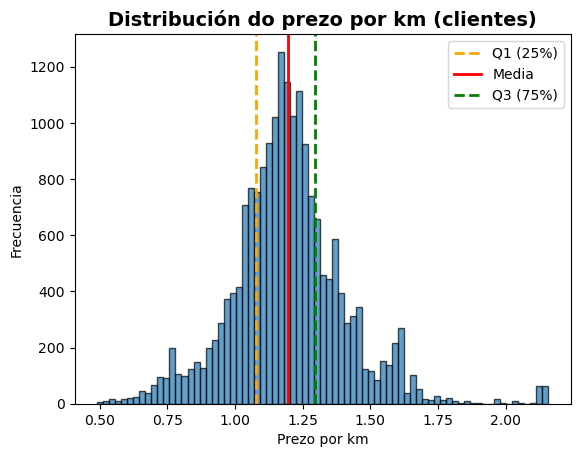

In [81]:
# Calcular los valores de referencia
q25 = np.quantile(datos_sin_out['cl_price_km'], 0.25)
q75 = np.quantile(datos_sin_out['cl_price_km'], 0.75)
mean = np.mean(datos_sin_out['cl_price_km'])

# Crear el histograma
plt.hist(datos_sin_out['cl_price_km'], bins=75, edgecolor='black', alpha=0.7)
plt.title("Distribución do prezo por km (clientes)", fontdict={'fontsize': 14, 'fontweight': 'bold'})
plt.xlabel("Prezo por km")
plt.ylabel("Frecuencia")

# Añadir líneas verticales
plt.axvline(q25, color='orange', linestyle='--', linewidth=2, label='Q1 (25%)')
plt.axvline(mean, color='red', linestyle='-', linewidth=2, label='Media')
plt.axvline(q75, color='green', linestyle='--', linewidth=2, label='Q3 (75%)')

# Añadir leyenda
plt.legend()
plt.show()


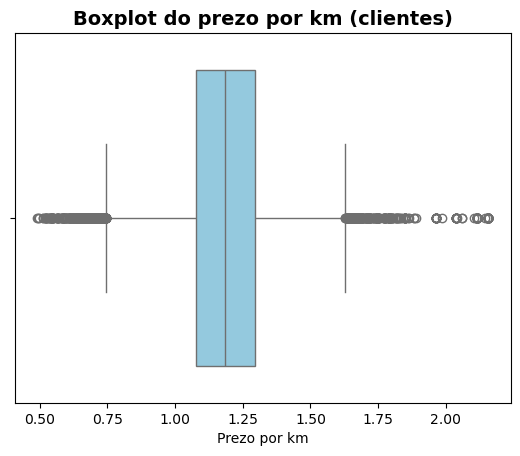

In [82]:
sns.boxplot(x=datos_sin_out['cl_price_km'], color="skyblue")

plt.title("Boxplot do prezo por km (clientes)", fontdict={'fontsize': 14, 'fontweight': 'bold'})
plt.xlabel("Prezo por km")
plt.show()


Para os proveedores

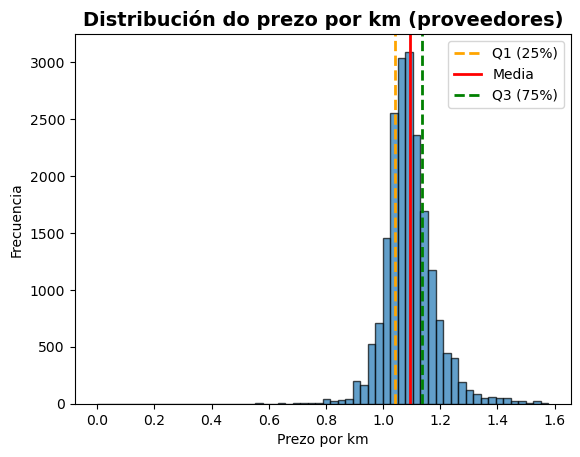

In [83]:
# Calcular los valores de referencia
q25 = np.quantile(datos_sin_out['pro_price_km'], 0.25)
q75 = np.quantile(datos_sin_out['pro_price_km'], 0.75)
mean = np.mean(datos_sin_out['pro_price_km'])

# Crear el histograma
plt.hist(datos_sin_out['pro_price_km'], bins=60, edgecolor='black', alpha=0.7)
plt.title("Distribución do prezo por km (proveedores)", fontdict={'fontsize': 14, 'fontweight': 'bold'})
plt.xlabel("Prezo por km")
plt.ylabel("Frecuencia")

# Añadir líneas verticales
plt.axvline(q25, color='orange', linestyle='--', linewidth=2, label='Q1 (25%)')
plt.axvline(mean, color='red', linestyle='-', linewidth=2, label='Media')
plt.axvline(q75, color='green', linestyle='--', linewidth=2, label='Q3 (75%)')

# Añadir leyenda
plt.legend()
plt.show()


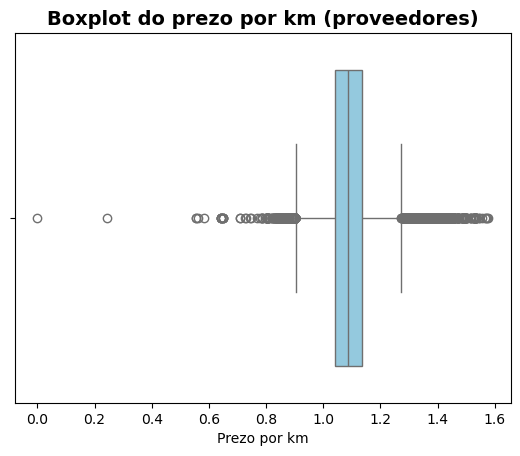

In [84]:
sns.boxplot(x=datos_sin_out['pro_price_km'], color="skyblue")

plt.title("Boxplot do prezo por km (proveedores)", fontdict={'fontsize': 14, 'fontweight': 'bold'})
plt.xlabel("Prezo por km")
plt.show()


### Volume de envíos

Podemos ver así como é o volume dos pedidos tras desfacernos das observacións atípicas da variable **pro_price_km**:

In [85]:
pedidos_por_semana2 = datos_sin_out.groupby('semana').size().reset_index(name='n_pedidos')

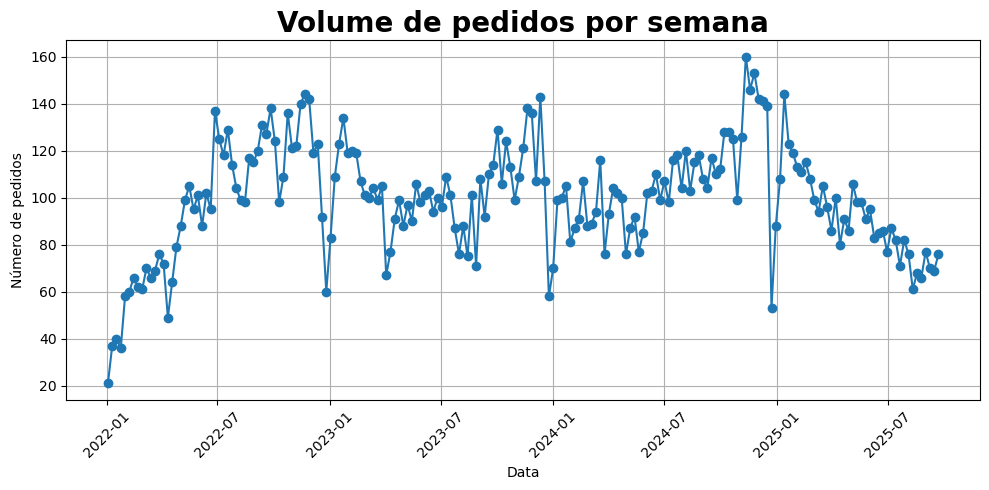

In [86]:
plt.figure(figsize=(10, 5))
plt.plot(pedidos_por_semana2['semana'], pedidos_por_semana2['n_pedidos'], marker='o')
plt.title('Volume de pedidos por semana', fontdict={'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Data')
plt.ylabel('Número de pedidos')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

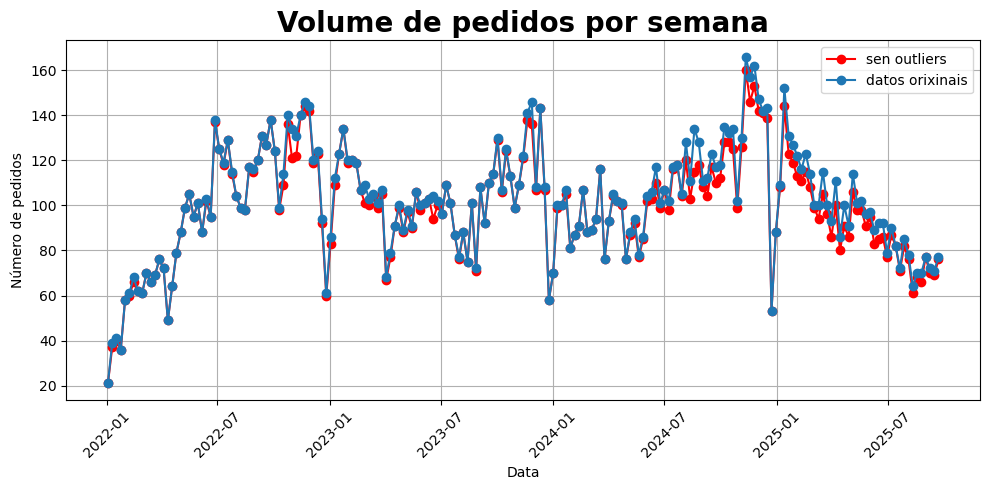

In [87]:
plt.figure(figsize=(10, 5))
plt.plot(pedidos_por_semana2['semana'], pedidos_por_semana2['n_pedidos'], marker='o', label = 'sen outliers',color='red')
plt.plot(pedidos_por_semana['semana'], pedidos_por_semana['n_pedidos'], marker='o', label = 'datos orixinais')
plt.title('Volume de pedidos por semana', fontdict={'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Data')
plt.ylabel('Número de pedidos')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

Representamos a evolución temporal (suavizada) dos prezos por km de clientes e provedores para cada cluster. Seguramente nestas gráfucas será onde se vexan os maiores cambios ao eliminar os outliers apoiándonos en ditas variables.

In [88]:
prezo_por_dia_cluster2 = (
    datos_sin_out
    .groupby(['dia', 'Cluster'])['cl_price_km']
    .mean()
    .reset_index()
)

# Asegurarse de que 'dia' sea datetime
prezo_por_dia_cluster2['dia'] = pd.to_datetime(prezo_por_dia_cluster2['dia'])

prezo_por_dia_cluster2['cl_price_km_lowess'] = np.nan


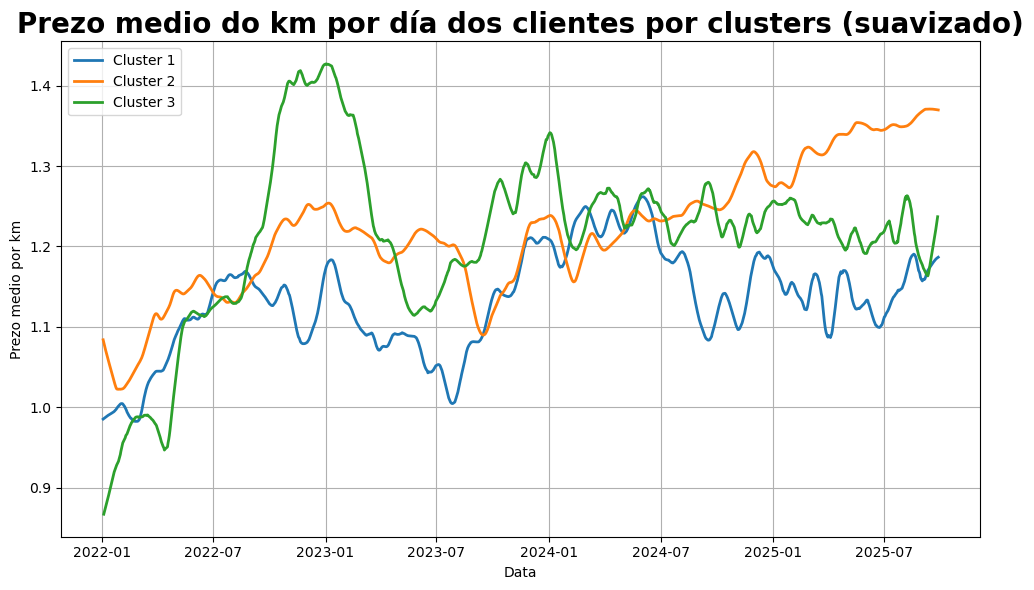

In [89]:
plt.figure(figsize=(10, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green']  # Colores distintos para cada cluster

for i, cluster_id in enumerate(prezo_por_dia_cluster2['Cluster'].unique()):
    cluster_data = prezo_por_dia_cluster2[prezo_por_dia_cluster2['Cluster'] == cluster_id]
    
    # Eje x numérico para Lowess
    x = cluster_data['dia'].map(pd.Timestamp.toordinal)
    y = cluster_data['cl_price_km']
    
    smoothed = lowess(y, x, frac=0.03, return_sorted=False)
    
    plt.plot(cluster_data['dia'], smoothed, color=colors[i], linewidth=2, label=f'Cluster {cluster_id}')

plt.title('Prezo medio do km por día dos clientes por clusters (suavizado)', fontdict={'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Data')
plt.ylabel('Prezo medio por km')
plt.grid(True)
plt.xticks()
plt.legend()
plt.tight_layout()
plt.show()


Análogamente para os provedores:

In [90]:
prezo_por_dia_cluster3 = (
    datos_sin_out
    .groupby(['dia', 'Cluster'])['pro_price_km']
    .mean()
    .reset_index()
)

# Asegurarse de que 'dia' sea datetime
prezo_por_dia_cluster3['dia'] = pd.to_datetime(prezo_por_dia_cluster3['dia'])

prezo_por_dia_cluster3['pro_price_km_lowess'] = np.nan


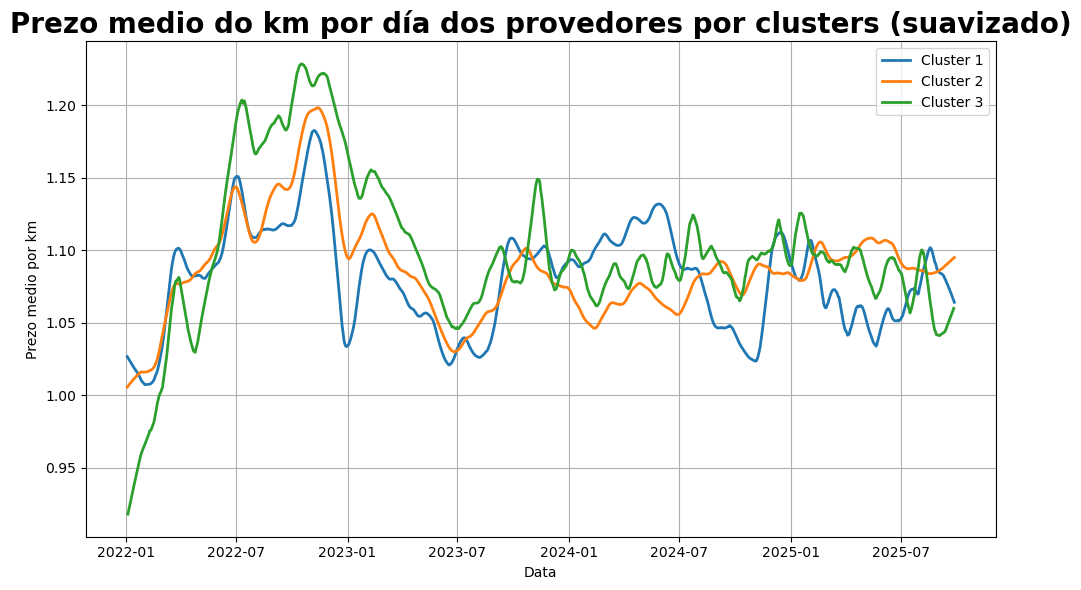

In [97]:
plt.figure(figsize=(10, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green']  # Colores distintos para cada cluster

for i, cluster_id in enumerate(prezo_por_dia_cluster3['Cluster'].unique()):
    cluster_data = prezo_por_dia_cluster3[prezo_por_dia_cluster3['Cluster'] == cluster_id]
    
    # Eje x numérico para Lowess
    x = cluster_data['dia'].map(pd.Timestamp.toordinal)
    y = cluster_data['pro_price_km']
    
    smoothed = lowess(y, x, frac=0.03, return_sorted=False)
    
    plt.plot(cluster_data['dia'], smoothed, color=colors[i], linewidth=2, label=f'Cluster {cluster_id}')

plt.title('Prezo medio do km por día dos provedores por clusters (suavizado)', fontdict={'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Data')
plt.ylabel('Prezo medio por km')
plt.grid(True)
plt.xticks()
plt.legend()
plt.tight_layout()
plt.show()


Outra gráfica comparativa de interese sería ver como diminúe o volume de envíos mensual por cluster (ver si, en efecto, estamos quitando moitos pedidos da $\textit{peak season}$:

In [92]:
# Agrupamos por semana y cluster, contando número de pedidos
pedidos_por_semana_cluster2 = (
    datos_sin_out
    .groupby(['semana', 'Cluster'])
    .size()
    .reset_index(name='n_pedidos')
)

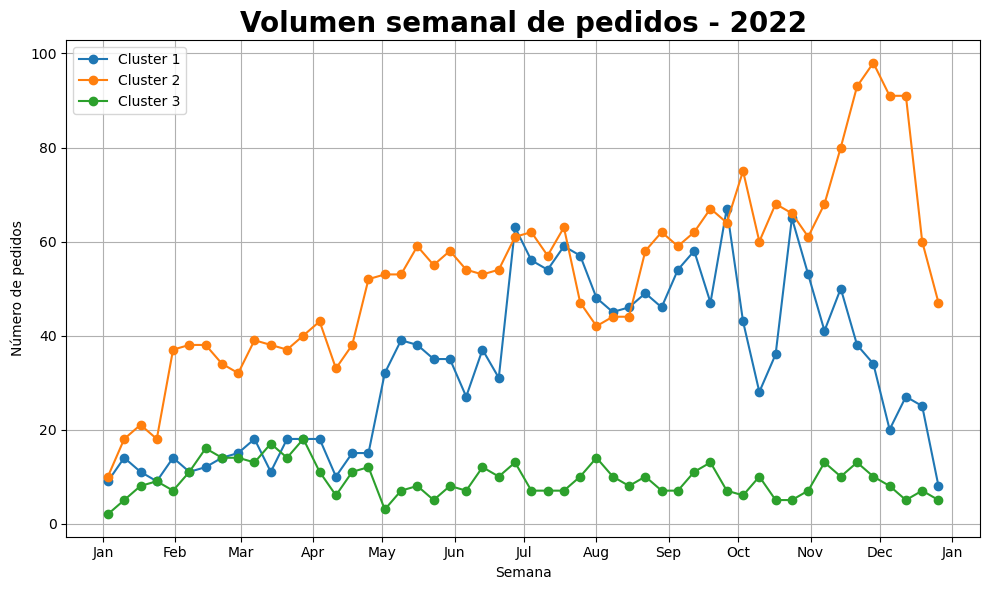

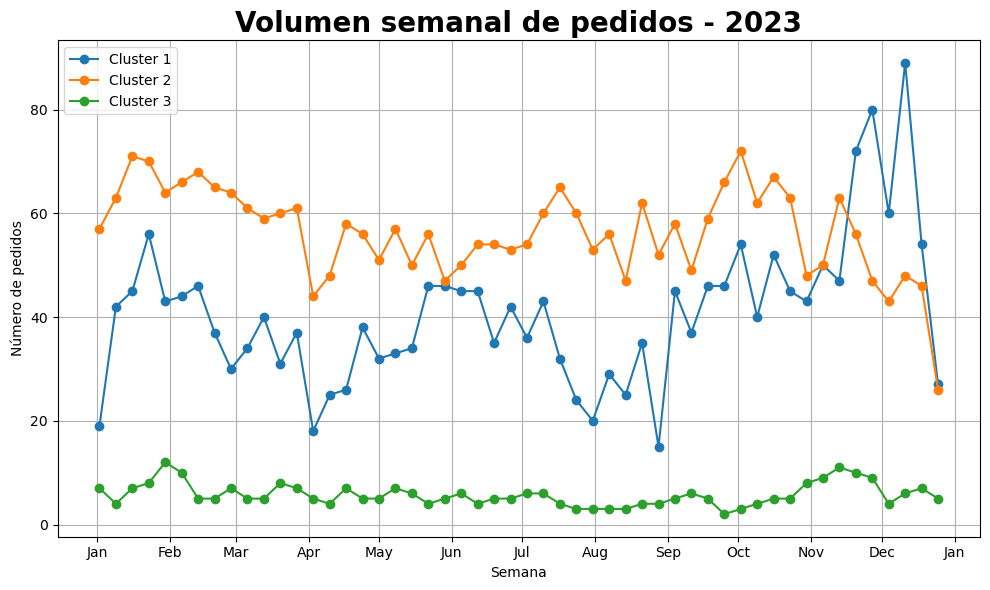

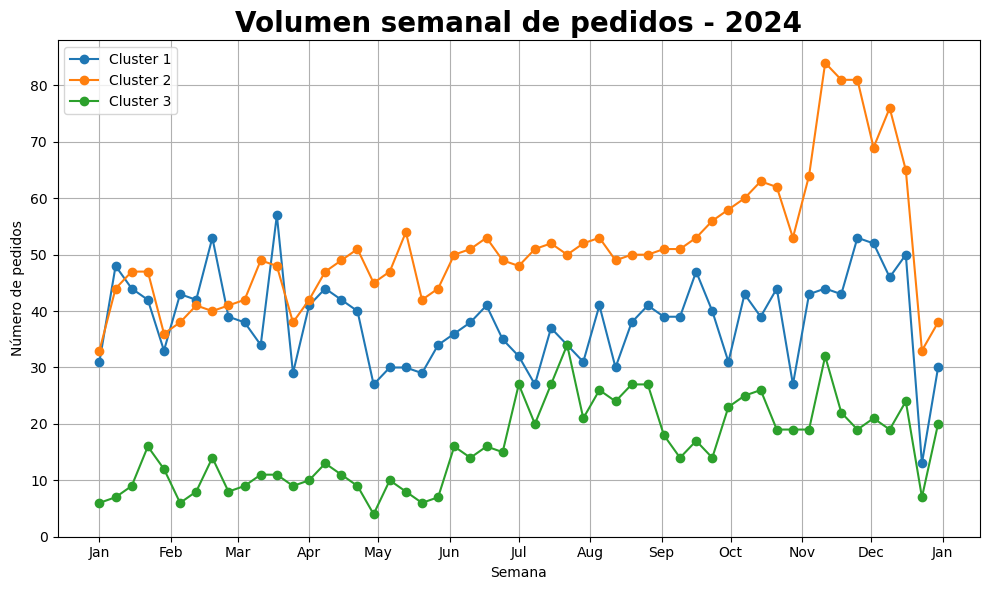

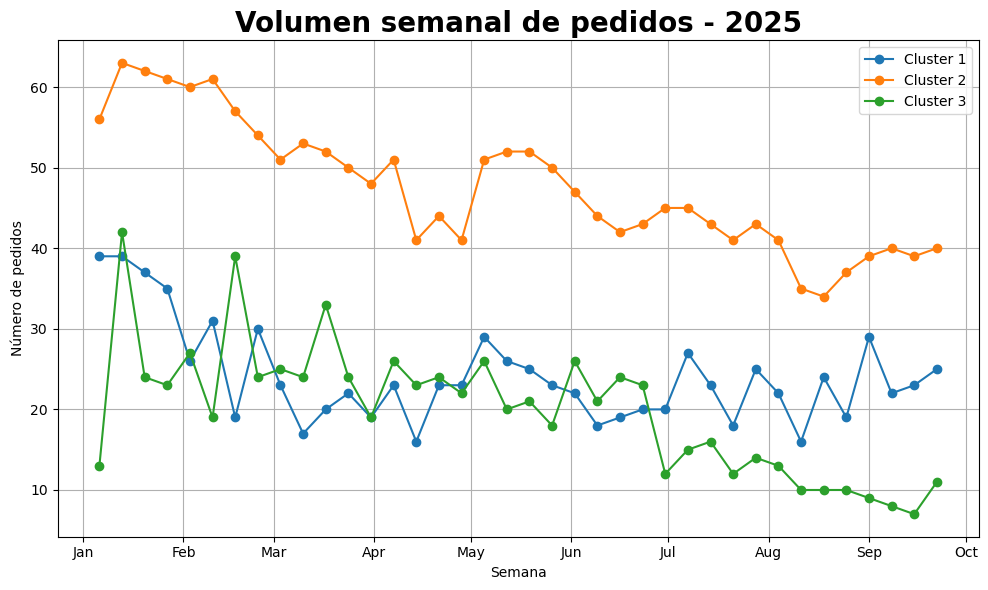

In [93]:
# Asegúrate de que 'semana' sea datetime
pedidos_por_semana_cluster2['semana'] = pd.to_datetime(pedidos_por_semana_cluster2['semana'])
pedidos_por_semana_cluster2['ano'] = pedidos_por_semana_cluster2['semana'].dt.year

colors = ['tab:blue', 'tab:orange', 'tab:green']  # Para los 3 clusters

# Crear un gráfico por año
for ano, grupo_ano in pedidos_por_semana_cluster2.groupby('ano'):
    plt.figure(figsize=(10,6))
    
    for i, cluster_id in enumerate(grupo_ano['Cluster'].unique()):
        cluster_data = grupo_ano[grupo_ano['Cluster'] == cluster_id]
        plt.plot(
            cluster_data['semana'],
            cluster_data['n_pedidos'],
            marker='o',
            linestyle='-',
            color=colors[i],
            label=f'Cluster {cluster_id}'
        )
    
    plt.title(f'Volumen semanal de pedidos - {ano}', fontdict={'fontsize': 20, 'fontweight': 'bold'})
    plt.xlabel('Semana')
    plt.ylabel('Número de pedidos')
    
    # Eje X con meses
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


Ou mensualmente e comparando cos datos orixinais:

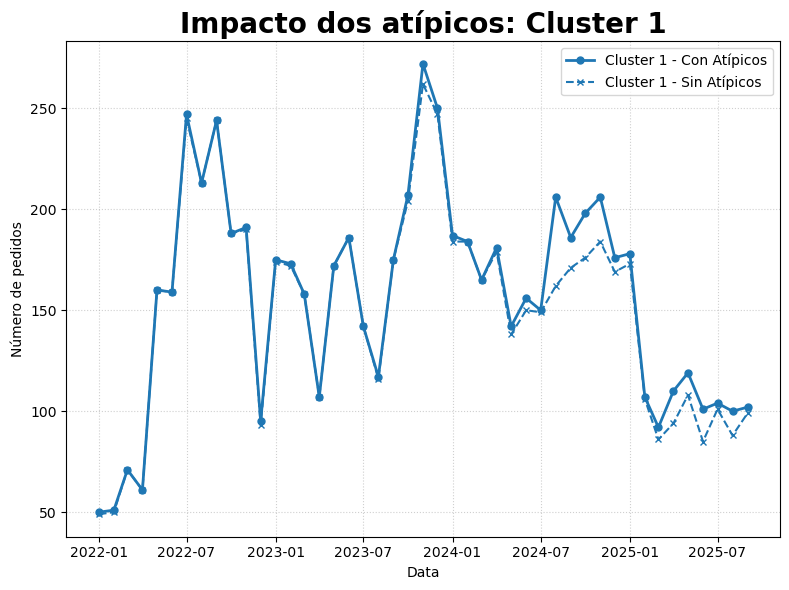

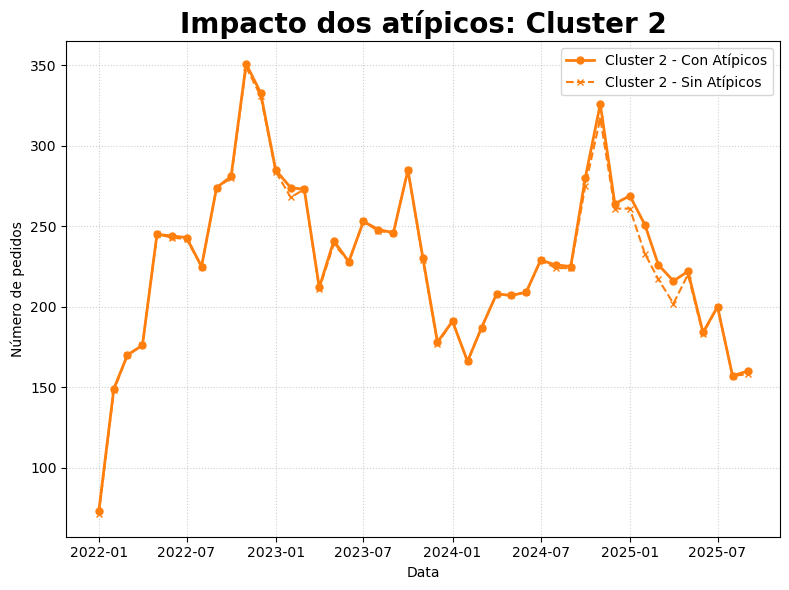

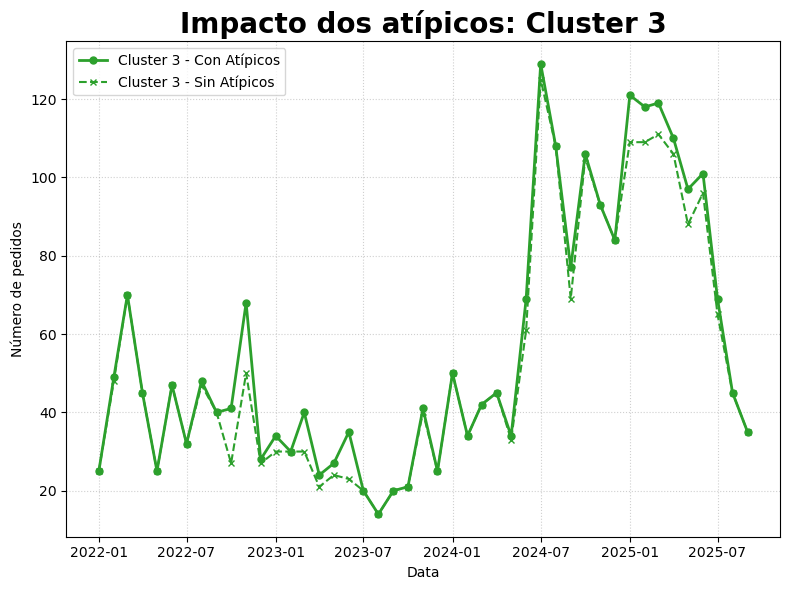

In [94]:
# 1. PREPARACIÓN DE DATOS (CON ATÍPICOS)
pedidos_por_mes_cluster_original = (
    datos
    .groupby(['mes', 'Cluster'])
    .size()
    .reset_index(name='n_pedidos_original')
)
pedidos_por_mes_cluster_original['mes'] = pd.to_datetime(pedidos_por_mes_cluster_original['mes'])


# 2. PREPARACIÓN DE DATOS (SIN ATÍPICOS)
# Usamos el DataFrame sin atípicos (datos_sin_out)
pedidos_por_mes_cluster_sin_out = (
    datos_sin_out
    .groupby(['mes', 'Cluster'])
    .size()
    .reset_index(name='n_pedidos_sin_out')
)
pedidos_por_mes_cluster_sin_out['mes'] = pd.to_datetime(pedidos_por_mes_cluster_sin_out['mes'])


# 3. DEFINICIÓN DE PARÁMETROS DE PLOTEO Y BUCLE
unique_clusters = pedidos_por_mes_cluster_original['Cluster'].unique()
colors = {
    unique_clusters[0]: 'tab:blue',
    unique_clusters[1]: 'tab:orange',
    unique_clusters[2]: 'tab:green'
}

# Iterar sobre cada cluster
for cluster_id in unique_clusters:
    
    # 3.1. Crear una NUEVA figura para cada cluster
    plt.figure(figsize=(8, 6))
    current_color = colors.get(cluster_id, 'black')
    
    # --- FILTRADO Y ORDENACIÓN ---
    # Es crucial ordenar por mes antes de graficar la serie temporal
    original_data = pedidos_por_mes_cluster_original[pedidos_por_mes_cluster_original['Cluster'] == cluster_id].sort_values('mes')
    sin_out_data = pedidos_por_mes_cluster_sin_out[pedidos_por_mes_cluster_sin_out['Cluster'] == cluster_id].sort_values('mes')
    
    
    # --- GRAFICAR SERIE ORIGINAL (CON ATÍPICOS) ---
    plt.plot(
        original_data['mes'],
        original_data['n_pedidos_original'], # Usamos el valor del conteo directo
        marker='o',
        markersize=5,
        linewidth=2,
        linestyle='-',
        color=current_color,
        label=f'Cluster {cluster_id} - Con Atípicos'
    )

    # --- GRAFICAR SERIE SIN ATÍPICOS ---
    plt.plot(
        sin_out_data['mes'],
        sin_out_data['n_pedidos_sin_out'], # Usamos el valor del conteo directo
        marker='x', # Cambiamos el marcador para diferenciar
        markersize=5,
        linewidth=1.5,
        linestyle='--', # Línea discontinua para el impacto
        color=current_color,
        label=f'Cluster {cluster_id} - Sin Atípicos'
    )
    
    # 4. CONFIGURACIÓN DEL PLOT
    plt.title(
        f'Impacto dos atípicos: Cluster {cluster_id}',
        fontdict={'fontsize': 20, 'fontweight': 'bold'}
    )
    plt.xlabel('Data')
    plt.ylabel('Número de pedidos')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Formatear el eje X para fechas y rotar las etiquetas
   # plt.gcf().autofmt_xdate()
    
    plt.legend()
    plt.tight_layout()
    plt.show()

Para rematar, exportamos os datos modificados neste script para continuar co traballo e evitar ter que cargar todo o anterior constantemente.

In [95]:
datos.to_csv("TFM_datos_EDA.csv", index = False)
datos_sin_out.to_csv("TFM_datos_EDA_outliers.csv", index = False)